<a href="https://colab.research.google.com/github/angarikadas26-lgtm/burnout-prediction-project/blob/V2-draft/Han_IS6611_(Part_1%2C2%2C3_and_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Angarika

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
os.makedirs('/content/drive/MyDrive/Artefact V2', exist_ok=True)

In [10]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

# IS6611 Applied Research in Business Analytics
# Employee Burnout Prediction
# Group 6


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re



In [12]:
df = pd.read_csv('/content/2024_Eurofound_working_conditions.csv')

/tmp/ipykernel_923/3995954437.py:1: DtypeWarning: Columns (9,16,43,44,46,48,52,54,55,62,101,102,110,111,127,133,208,212,217,232,243,245,256,258,259,260,288,324,325,334,366,378) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/2024_Eurofound_working_conditions.csv')


In [13]:
#data description
df.head()
df.shape

(36644, 386)

In [14]:
#Step 1-understand (analyze) & clean data
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36644 entries, 0 to 36643
Columns: 386 entries, uniquerespid to calweight
dtypes: float64(7), int64(34), object(345)
memory usage: 107.9+ MB


,0
uniquerespid,0
country_code,0
country,0
language,0
samplingpointid,0
...,...
sector,0
region,0
design_weight,0
gweight,0


In [15]:
#check missing values
missing_values = df.isnull().sum()

missing_values.sort_values(ascending=False)

,0
calweight,0
uniquerespid,0
boss_conf,0
boss_cooperation,0
boss_respect,0
...,...
stratumid,0
householdnumber,0
samplingpointid,0
language,0


In [16]:
#Missing Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

,0
calweight,0.0
uniquerespid,0.0
boss_conf,0.0
boss_cooperation,0.0
boss_respect,0.0
...,...
stratumid,0.0
householdnumber,0.0
samplingpointid,0.0
language,0.0


In [17]:
#identify data types
df.dtypes.value_counts()

,count
object,345
int64,34
float64,7


In [18]:
#Separate Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

In [19]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,country,language,householdnumber,degurba,ISCO_2,ISCO_1,NACE_2,improve_pay_benefits,improve_prospects,improve_workhours,...,time_household,filters_EU27,monthly_income_eur_imp,monthly_income_eur_imp_ppp,hourly_income_eur_imp,income_quintile_country_weighted,occupation,design_weight,gweight,calweight
count,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,...,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000,36644.000000
mean,17.602309,909.060474,35.186470,1.892779,48.177273,4.563175,581.231334,0.695394,0.264927,0.317842,...,21.036851,0.781056,1823.800829,1963.451699,13.335501,2.903559,15.889013,6045.647118,1.024904,6044.133647
std,10.292970,7649.626488,60.632689,0.830368,24.443581,2.461575,275.497634,0.460247,0.441301,0.465644,...,26.263987,0.413537,1630.787559,1458.498924,24.559638,1.432992,21.921203,10820.448219,0.633671,12872.995011
min,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,-881.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,8.852571,19.607843,0.070058,1.000000,1.000000,52.521327,0.030000,3.311127
25%,9.000000,10.000000,11.000000,1.000000,25.000000,2.000000,450.000000,0.000000,0.000000,0.000000,...,3.500000,1.000000,788.514769,1052.631579,4.788462,2.000000,2.000000,990.382343,0.582947,773.085404
50%,17.000000,20.000000,21.000000,2.000000,51.000000,5.000000,560.000000,1.000000,0.000000,0.000000,...,14.000000,1.000000,1388.824591,1621.621622,8.695585,3.000000,5.000000,2567.552622,0.948704,2173.920361
75%,26.000000,29.000000,34.000000,3.000000,71.000000,7.000000,850.000000,1.000000,1.000000,1.000000,...,28.000000,1.000000,2440.065341,2500.000000,15.865385,4.000000,30.000000,5137.744517,1.369339,5173.767254
max,35.000000,69657.000000,607.000000,3.000000,96.000000,9.000000,990.000000,1.000000,1.000000,1.000000,...,168.000000,1.000000,68785.252440,59813.262990,1677.621436,5.000000,67.000000,225935.768900,6.612654,392423.299100


In [21]:
#check missing value

missing_table = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': missing_percent
})

missing_table.sort_values(
    by='Missing_Percent',
    ascending=False
).head(20)

,Missing_Count,Missing_Percent
calweight,0,0.0
uniquerespid,0,0.0
boss_conf,0,0.0
boss_cooperation,0,0.0
boss_respect,0,0.0
wellbeing,0,0.0
time_household,0,0.0
time_housework,0,0.0
time_elders,0,0.0
time_children,0,0.0


In [22]:
#find suspicious values

for col in df.columns:

    if (df[col].dtype == 'int64') or (df[col].dtype == 'float64'):

        print(col)
        print(df[col].nunique())
        print(df[col].sort_values().unique()[:10])
        print("----------------")

country
35
[ 1  2  3  4  5  6  7  8  9 10]
----------------
language
31
[ 2  3  5  6  7  8  9 10 11 12]
----------------
householdnumber
510
[ 1  2  3  4  5  6  7  8  9 10]
----------------
degurba
3
[1 2 3]
----------------
ISCO_2
43
[ 1  2  3 11 12 13 14 21 22 23]
----------------
ISCO_1
10
[0 1 2 3 4 5 6 7 8 9]
----------------
NACE_2
89
[-881    1    2    3    5    6    7    8    9  100]
----------------
improve_pay_benefits
2
[0 1]
----------------
improve_prospects
2
[0 1]
----------------
improve_workhours
2
[0 1]
----------------
improve_health_safety
2
[0 1]
----------------
improve_social
2
[0 1]
----------------
improve_opportunities
2
[0 1]
----------------
improve_workload
2
[0 1]
----------------
improve_voice
2
[0 1]
----------------
improve_DK
2
[0 1]
----------------
improve_Refused
2
[0 1]
----------------
isced
11
[-999 -998    0    1    2    3    4    5    6    7]
----------------
workstatus
11
[-999 -998    1    2    3    4    5    6    7    8]
----------------
age

In [23]:
# Coercing only numeric columns in object type to numeric
before_numeric = df.select_dtypes(include=[np.number]).shape[1]

def tidy_text(col):
    """Normalise text BEFORE numeric conversion so genuine numbers are not lost to
    formatting noise: trim spaces, fix decimal commas, and turn blank / text-missing
    tokens into NaN."""
    s = col.astype(str).str.strip()                 # 'val ' -> 'val'
    s = s.str.replace(',', '.', regex=False)        # decimal comma -> point ('1,5' -> '1.5')
    s = s.replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan, 'NA': np.nan,
                   'N/A': np.nan, 'n/a': np.nan, '.': np.nan, '#': np.nan,
                   'None': np.nan, '-': np.nan}, regex=False)
    return s

# A column is numeric if, after tidying, EVERY non-empty value parses as a number.
# Tidying first lets us use a strict 100% rule with no loss of real values.
for c in df.columns:
    s = tidy_text(df[c])
    coerced = pd.to_numeric(s, errors='coerce')
    non_empty = s.notna().sum()
    if non_empty > 0 and coerced.notna().sum() == non_empty:
        df[c] = coerced

after_numeric = df.select_dtypes(include=[np.number]).shape[1]
print(f"Numeric columns before: {before_numeric}, after tidy + strict conversion: {after_numeric}")


Numeric columns before: 41, after tidy + strict conversion: 369


In [24]:
# Find non negative values and group them
discovery = []
for c in df.columns:
    if df[c].dtype.kind in 'if':            # integer or float columns only
        neg_values = df[c][df[c] < 0]
        for code in neg_values.unique():
            discovery.append({
                'code': int(code),
                'column': c,
                'count': int((df[c] == code).sum())
            })

discovery = pd.DataFrame(discovery)

# Summary: for each code, how many cells and how many columns it appears in.
code_summary = (discovery
                .groupby('code')
                .agg(total_cells=('count', 'sum'),
                     n_columns=('column', 'nunique'))
                .sort_values('total_cells', ascending=False))

print("Special negative codes found IN THE DATA:")
print(code_summary)


Special negative codes found IN THE DATA:
      total_cells  n_columns
code                        
-889        71314          3
-999        35738         17
-996        30159          1
-991        29517         21
-990        20829          3
-666         7665          2
-444         4323          1
-555         4117          1
-445         1945          1
-994         1096          3
-998          458          9
-777          313          1
-881          160          1
-993           62          2
-992           45          1


In [25]:
# See exactly which columns each code appears in (evidence for our treatment decisions).
for code in code_summary.index:
    cols = discovery.loc[discovery['code'] == code, 'column'].tolist()
    preview = ', '.join(cols[:10]) + (' ...' if len(cols) > 10 else '')
    print(f"\ncode {code}  ({code_summary.loc[code, 'total_cells']} cells in {len(cols)} cols):")
    print(f"   {preview}")


code -889  (71314 cells in 3 cols):
   night, weekend, longday

code -999  (35738 cells in 17 cols):
   tech_it_support, trade_union, osh_delegate, work_accom_periods, work_accomodations_menopause, age_want, age_work, age_able, isced, workstatus ...

code -996  (30159 cells in 1 cols):
   num_supervising

code -991  (29517 cells in 21 cols):
   wlb_worry, wlb_tired, wlb_timefamily, wlb_concentrate, pace_colleagues, pace_cust, pace_targets, pace_machine, pace_boss, support_colleagues ...

code -990  (20829 cells in 3 cols):
   commute_time_minutes, absent_days, presenteeism

code -666  (7665 cells in 2 cols):
   pref_hours, pref_month

code -444  (4323 cells in 1 cols):
   age_want

code -555  (4117 cells in 1 cols):
   seniority

code -445  (1945 cells in 1 cols):
   age_want

code -994  (1096 cells in 3 cols):
   expected_hours_week, usual_hours_week, pref_hours

code -998  (458 cells in 9 cols):
   isced, workstatus, days_commuted, boss_respect, boss_cooperation, boss_conf, boss_fee

In [26]:
# Looking up the 2024 data dictionary file for translation of what these codes mean

DICT_RTF = '/content/drive/MyDrive/Artefact V2/ewcs24_dataset_ukds_ukda_data_dictionary.rtf'

def parse_rtf_value_labels(path):
    """Parse a UKDS .rtf data dictionary into a tidy table of (variable, code, label)."""
    with open(path, 'r', errors='ignore') as f:
        raw = f.read()

    # Strip RTF formatting down to plain text.
    txt = re.sub(r'\\par[d]?', '\n', raw)         # paragraphs -> newlines
    txt = re.sub(r'\\tab', '\t', txt)             # tabs
    txt = re.sub(r"\\'[0-9a-fA-F]{2}", ' ', txt)   # hex escapes
    txt = re.sub(r'\\[a-zA-Z]+-?\d* ?', '', txt)  # other control words
    txt = txt.replace('{', '').replace('}', '')

    rows, current_var = [], None
    for line in txt.splitlines():
        mvar = re.search(r'Variable = (\S+)', line)
        if mvar:
            current_var = mvar.group(1)
        mval = re.search(r'Value = (-?[\d.]+)\s*Label = (.+)', line)
        if mval:
            rows.append({'variable': current_var,
                         'code': float(mval.group(1)),
                         'label': mval.group(2).strip()})
    return pd.DataFrame(rows)


try:
    labels = parse_rtf_value_labels(DICT_RTF)
    print(f"Parsed {len(labels)} value-label pairs from the data dictionary.")
    have_dict = True
except FileNotFoundError:
    print("Data dictionary .rtf not found — falling back to a documented lookup (Section 3b).")
    labels = pd.DataFrame(columns=['variable', 'code', 'label'])
    have_dict = False


Data dictionary .rtf not found — falling back to a documented lookup (Section 3b).


In [27]:
# List the distinct labels the dictionary and understand what each negative code means
if have_dict:
    neg_labels = (labels[labels['code'] < 0]
                  .groupby('code')['label']
                  .apply(lambda s: sorted(set(s)))
                  .to_dict())
    print("Meaning of each negative code, per the official dictionary:\n")
    for code in sorted(neg_labels):
        print(f"  {int(code):5d}: {neg_labels[code]}")


Documented meaning + treatment decision table

Combining the discovery with the dictionary meanings , every special code
falls into one of three treatment types. The table below is the decision record for the cleaning;


| Code | Dictionary meaning | Type | Treatment & reason |
|------|--------------------|-------|--------------------|
| -999 | Don't know |  Missing | `NaN` — respondent could not answer |
| -998 | Refused (or 'Never' on 3 team_aut_* vars) | Missing or Real Zero | `NaN` (Refused); `0` on the team vars where it means 'Never' |
| -888,-887,-883,-882 | Verbatim incomplete / not coded | Missing | `NaN` |
| -777 | No exact duration (spontaneous) | Missing | `NaN` |
| -881 | (uncoded industry) | Missing | `NaN` |
| -996 | None | Real zero | `0` — e.g. supervises nobody |
| -889 | Never | Real zero | `0` — e.g. never works nights |
| -990 | Not sick / not relevant | Real zero | `0` on health-day counts; `NaN` on commute |
| -555 | Less than 1 year | Real value | `0.5` years seniority |
| -991 | Does not apply | special | work-life items: no conflict -> best end of scale; elsewhere `NaN` |
| -994,-993,-992 | Prefer to answer in another unit | Format | `NaN` |
| -666 | Same number of hours as currently | Format | `NaN` |
| -445,-444 | Want to stop ASAP / work as long as possible | Format | `NaN` |



In [28]:
# Handling Type "Missing" under class A
CLASS_A = [-999, -998, -888, -887, -883, -882, -881, -777]
team_never = ['team_aut_task', 'team_aut_head', 'team_aut_time']  # here -998 means 'Never'

cells_to_nan = 0
for c in df.columns:
    if df[c].dtype.kind in 'if':
        codes = [s for s in CLASS_A if not (s == -998 and c in team_never)]
        mask = df[c].isin(codes)
        cells_to_nan += int(mask.sum())
        df[c] = df[c].mask(mask)

print(f"Class A: {cells_to_nan} genuine-non-response cells set to NaN.")


Class A: 36669 genuine-non-response cells set to NaN.


In [29]:
# Handling Real zeros as "class B"

# -998 'Never' on the team-autonomy items -> 0 (team never decides this)
for c in team_never:
    if c in df.columns:
        df[c] = df[c].replace(-998, 0)

# -996 'None' : supervises nobody -> 0
if 'num_supervising' in df.columns:
    df['num_supervising'] = df['num_supervising'].replace(-996, 0)

# -889 'Never' : never works nights / weekends / long days -> 0 times per month
for c in ['night', 'weekend', 'longday']:
    if c in df.columns:
        df[c] = df[c].replace(-889, 0)

# -990 : 'not sick' on health-burden day counts -> 0 ; 'not relevant' on commute -> NaN
for c in ['presenteeism', 'absent_days']:
    if c in df.columns:
        df[c] = df[c].replace(-990, 0)
if 'commute_time_minutes' in df.columns:
    df['commute_time_minutes'] = df['commute_time_minutes'].replace(-990, np.nan)

# -555 'Less than 1 year' seniority -> 0.5 years
if 'seniority' in df.columns:
    df['seniority'] = df['seniority'].replace(-555, 0.5)

print("Class B substantive zeros / values recoded.")


Class B substantive zeros / values recoded.


In [30]:
# For the special "Do not apply" category

WLB_FREQ = ['wlb_worry', 'wlb_tired', 'wlb_timefamily', 'wlb_concentrate']
for c in WLB_FREQ:
    if c in df.columns:
        df[c] = df[c].replace(-991, 5)      # does not apply -> never experiences this conflict

if 'work_life_balance' in df.columns:
    df['work_life_balance'] = df['work_life_balance'].replace(-991, 1)  # no family -> fits very well

if 'stress' in df.columns:
    df['stress'] = df['stress'].replace(-991, 5)   # does not apply -> never stressed

# Any remaining -991 elsewhere -> NaN
remaining = 0
for c in df.columns:
    if df[c].dtype.kind in 'if':
        m = (df[c] == -991)
        remaining += int(m.sum())
        df[c] = df[c].mask(m)
print(f"Work-life 'does not apply' recoded; {remaining} other -991 cells set to NaN.")


Work-life 'does not apply' recoded; 27460 other -991 cells set to NaN.


In [31]:
# On the variable's main scale (e.g. "prefer to answer in hours per month" on a per-week question), so they are treated as missing and naming them as class C

CLASS_C = [-994, -993, -992, -666, -445, -444]
cells_c = 0
for c in df.columns:
    if df[c].dtype.kind in 'if':
        m = df[c].isin(CLASS_C)
        cells_c += int(m.sum())
        df[c] = df[c].mask(m)
print(f"Class C: {cells_c} format/spontaneous cells set to NaN.")


Class C: 15136 format/spontaneous cells set to NaN.


In [32]:
# Changing all other negatives if any to NaN

remaining_before = sum(int((df[c] < 0).sum()) for c in df.columns if df[c].dtype.kind in 'if')

# Belt-and-braces: also coerce any column that still holds numeric-looking sentinels as text,
# so nothing can slip through just because of a lingering object dtype.
for c in df.columns:
    coerced = pd.to_numeric(df[c], errors='coerce')
    if (coerced < 0).any():
        df[c] = coerced.mask(coerced < 0)
    elif df[c].dtype.kind in 'if':
        df[c] = df[c].mask(df[c] < 0)

remaining_after = sum(int((pd.to_numeric(df[c], errors='coerce') < 0).sum()) for c in df.columns)
print(f"Catch-all: {remaining_before} remaining negative cells set to NaN. Negatives left anywhere: {remaining_after}")


Catch-all: 0 remaining negative cells set to NaN. Negatives left anywhere: 0


In [33]:
# Crosscheck for any other leftovers

leftover = []
for c in df.columns:
    n = int((pd.to_numeric(df[c], errors='coerce') < 0).sum())
    if n:
        leftover.append((c, n))

print("Columns still containing negative codes:", leftover if leftover else "NONE")

# Spot-check the burnout-relevant items are now on their proper scales.
print("\nKey items after cleaning (should be 1-5, or 1-4 for work_life_balance):")
for v in ['exhaust_emot','exhaust_phys','stress','eng_energy','eng_enthusiastic','eng_timeflies',
          'work_life_balance','wlb_worry','wlb_tired','wlb_timefamily','wlb_concentrate']:
    if v in df.columns:
        col = pd.to_numeric(df[v], errors='coerce')
        print(f"  {v:20s} min={col.min():>4} max={col.max():>4} NaN={col.isna().sum():>5}")


Columns still containing negative codes: NONE

Key items after cleaning (should be 1-5, or 1-4 for work_life_balance):
  exhaust_emot         min= 1.0 max= 5.0 NaN=  129
  exhaust_phys         min= 1.0 max= 5.0 NaN=   51
  stress               min= 1.0 max= 5.0 NaN=  190
  eng_energy           min= 1.0 max= 5.0 NaN=  103
  eng_enthusiastic     min= 1.0 max= 5.0 NaN=  203
  eng_timeflies        min= 1.0 max= 5.0 NaN=   75
  work_life_balance    min= 1.0 max= 4.0 NaN=  108
  wlb_worry            min= 1.0 max= 5.0 NaN=   60
  wlb_tired            min= 1.0 max= 5.0 NaN=   63
  wlb_timefamily       min= 1.0 max= 5.0 NaN=   72
  wlb_concentrate      min= 1.0 max= 5.0 NaN= 1042


In [34]:
# Recheck duplicates
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Single-value (constant) columns add no information
single_value_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Single-value columns:", single_value_cols)

# Missing-value overview (top 20 by percent)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nTop 20 columns by missing %:")
print(missing_pct.head(20).round(2))


Duplicate rows: 0
Single-value columns: ['language_interview']

Top 20 columns by missing %:
hours_other_job_month            99.93
contract_duration_days           99.91
contract_duration_weeks          99.89
time_care_relatives_day_mins     99.81
boss_cooperation_neutral         99.80
boss_conf_neutral                99.80
boss_explains__neutral           99.79
boss_feedback_neutral            99.79
boss_development_neutral         99.79
boss_respect_neutral             99.79
time_care_children_week_mins     99.72
time_care_relatives_week_mins    99.61
age_bands                        99.61
pref_month                       99.55
time_care_children_day_mins      99.45
commute_time_hours               99.44
paid_salary                      99.34
time_care_housework_week_mins    99.32
expected_hours_month             99.19
usual_hours_month                98.73
dtype: float64


In [35]:
#checking for extreme outliers

df.describe().T

,count,mean,std,min,25%,50%,75%,max
country,36644.0,17.602309,10.292970,1.000000,9.000000,17.000000,26.000000,35.000000
language,36644.0,909.060474,7649.626488,2.000000,10.000000,20.000000,29.000000,69657.000000
householdnumber,36644.0,35.186470,60.632689,1.000000,11.000000,21.000000,34.000000,607.000000
degurba,36644.0,1.892779,0.830368,1.000000,1.000000,2.000000,3.000000,3.000000
number_jobs,36562.0,1.057327,0.232470,1.000000,1.000000,1.000000,1.000000,2.000000
...,...,...,...,...,...,...,...,...
income_quintile_eu27_weighted,28621.0,2.932322,1.460090,1.000000,2.000000,3.000000,4.000000,5.000000
occupation,36644.0,15.889013,21.921203,1.000000,2.000000,5.000000,30.000000,67.000000
design_weight,36644.0,6045.647118,10820.448219,52.521327,990.382343,2567.552622,5137.744517,225935.768900
gweight,36644.0,1.024904,0.633671,0.030000,0.582947,0.948704,1.369339,6.612654


In [36]:
#Identify Binary vs Categorical vs Continuous Variables

binary_cols = []
continuous_cols = []
categorical_encoded_cols = []

In [37]:
#Class Balance of Important Variables

df['improve_workload'].value_counts()

,count
improve_workload,
0,27644
1,9000


In [38]:
#SAVE CLEANED VERSION

df.to_csv(
    '/content/drive/MyDrive/Artefact V2/EWCS2024_Cleaned.csv',
    index=False
)


#Tanya


### Burnout-related variables identified (from the brief)
The brief names four burnout-related concepts. Each maps onto EWCS 2024 items as follows:

| Brief concept | EWCS 2024 item(s) | Where it goes |
|---|---|---|
| Exhaustion | `exhaust_emot` (emotionally drained) | Exhaustion component |
| Fatigue | `exhaust_phys` (physically exhausted), `wlb_tired` (too tired for home tasks) | Exhaustion component / work-life component |
| Stress | `stress` (experiences stress at work) | Exhaustion component |
| Work-life conflict | `work_life_balance`, `wlb_worry`, `wlb_tired`, `wlb_timefamily`, `wlb_concentrate` | Work-life conflict component |

### Definition of burnout used here
We follow the two-component Job Demands-Resources (JD-R) model of burnout (Demerouti et al., 2001; Bakker & Demerouti, 2007), in which burnout is the combination of **exhaustion** and **disengagement (reduced vigour / cynicism)**. We add a **work-life conflict** component, which the burnout literature consistently identifies as a key antecedent and correlate of exhaustion (Maslach & Leiter, 2016). Stress and fatigue from the brief are absorbed into the exhaustion component, consistent with Maslach & Leiter's treatment of chronic work stress as part of the exhaustion dimension. This gives the project-specified weighting:

> **BurnoutScore = 0.4 x Exhaustion + 0.3 x Disengagement + 0.3 x WorkLifeConflict**

### Important methodological note on scale direction
In EWCS 2024 the frequency items are coded **1 = Always ... 5 = Never**. This means a *low* number indicates a *high* frequency. Because the raw items point in different directions (for exhaustion a low number is bad; for engagement a low number is good), every item is first **rescaled to a common 0-to-1 direction where 1 always means "more burnout"** before any averaging. This is the single most important step; skipping it would make the score meaningless.


In [39]:
# Load the cleaned dataset produced by Angarika.

df = pd.read_csv('/content/drive/MyDrive/Artefact V2/EWCS2024_Cleaned.csv')

print("Shape:", df.shape)
df.head()


Shape: (36644, 386)


,uniquerespid,country_code,country,language,samplingpointid,householdnumber,stratumid,nuts1,degurba,number_jobs,...,hourly_income_eur_imp,income_quintile_country_weighted,income_quintile_eu27_weighted,agesex,occupation,sector,region,design_weight,gweight,calweight
0,AL001-002-Z1,AL,30,28,AL001,2,AL011,AL0,2,1.0,...,2.101043,3,NaN,F_1529,5,RU,AL01B_East,1797.761418,1.425554,2562.806757
1,AL001-004-Z1,AL,30,28,AL001,4,AL011,AL0,2,1.0,...,9.272293,5,NaN,M_1529,2,Q,AL01B_East,1348.321063,0.916459,1235.681362
2,AL001-007-Z1,AL,30,28,AL001,7,AL011,AL0,2,1.0,...,1.596016,2,NaN,F_3039,5,G,AL01B_East,1797.761418,0.874673,1572.454205
3,AL001-010-Z1,AL,30,28,AL001,10,AL011,AL0,2,1.0,...,2.854022,3,NaN,M_4049,8,H,AL01B_East,1797.761418,1.484785,2669.288496
4,AL001-011-Z1,AL,30,28,AL001,11,AL011,AL0,2,1.0,...,1.824019,1,NaN,M_6074,9,A,AL01B_East,898.880709,1.233736,1108.981533


In [40]:
# Diagnose: Check which negative codes remain, and in which columns?
neg_report = {}
for c in df.columns:
    col = pd.to_numeric(df[c], errors='coerce')
    for code in col[col < 0].unique():
        neg_report.setdefault(int(code), []).append(c)

for code in sorted(neg_report):
    cols = neg_report[code]
    print(f"{code}: {sum(int((pd.to_numeric(df[x],errors='coerce')==code).sum()) for x in cols)} cells "
          f"in {len(cols)} cols -> {cols[:8]}")

In [41]:
# Crosscheck if the cleaned file was loaded and forces checking any known-numeric columns to numeric, since some (e.g. wellbeing) can load as text and would break .corr() / modelling.

# Guard against accidentally loading the RAW file instead of Angarika's cleaned output.
neg_cells = sum(
    int((pd.to_numeric(df[c], errors='coerce') < 0).sum())
    for c in df.columns
)

assert neg_cells == 0, (
    f"Found {neg_cells} negative sentinel values. This looks like the RAW file. "
    "Load Angarika's cleaned output (EWCS2024_Cleaned.csv), not the raw Eurofound CSV."
)
print("Input check passed: no negative sentinels (file is cleaned).")

# Force known-numeric survey items to numeric dtype (fixes text-stored columns like wellbeing).
force_numeric = ['wellbeing',
                 'exhaust_emot', 'exhaust_phys', 'stress',
                 'eng_energy', 'eng_enthusiastic', 'eng_timeflies',
                 'work_life_balance', 'wlb_worry', 'wlb_tired', 'wlb_timefamily', 'wlb_concentrate']
for c in force_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
print("Forced to numeric:", [c for c in force_numeric if c in df.columns])



Input check passed: no negative sentinels (file is cleaned).
Forced to numeric: ['wellbeing', 'exhaust_emot', 'exhaust_phys', 'stress', 'eng_energy', 'eng_enthusiastic', 'eng_timeflies', 'work_life_balance', 'wlb_worry', 'wlb_tired', 'wlb_timefamily', 'wlb_concentrate']


Identify the burnout-related variables

**Direction key**
- bad_is_low : a LOW raw code means MORE of the bad thing (e.g. exhaust_emot: 1 = Always exhausted)
- bad_is_high: a HIGH raw code means MORE of the bad thing (e.g. eng_energy: 5 = Never feel energetic = bad)

In [42]:
# Each entry: variable -> (raw_min, raw_max, direction)
# direction tells us which end of the scale represents MORE burnout / MORE of the construct.

# ---- Component 1: EXHAUSTION (frequency 1=Always..5=Never) ----
# Feeling exhausted ALWAYS (code 1) = high burnout, so bad_is_low.
# "Fatigue" from the brief is captured here by exhaust_phys (physical exhaustion);
# wlb_tired (too tired after work) additionally captures fatigue in the work-life component.
# "Stress" from the brief is folded into exhaustion: the burnout literature (Maslach & Leiter,
# 2016) treats chronic work stress as part of the exhaustion dimension, and the project formula
# has three weighted components with no separate slot for stress, so it sits inside exhaustion.

EXHAUSTION_ITEMS = {
    'exhaust_emot': (1, 5, 'bad_is_low'),   # emotionally drained by work
    'exhaust_phys': (1, 5, 'bad_is_low'),   # physically exhausted at end of day (fatigue)
    'stress':       (1, 5, 'bad_is_low'),   # experiences stress in work
}

# ---- Component 2: DISENGAGEMENT (reverse of work engagement) ----
# Engagement items: 1=Always feel engaged (good). NEVER engaged (code 5) = disengaged = bad.
# So for disengagement, bad_is_high.

DISENGAGEMENT_ITEMS = {
    'eng_energy':       (1, 5, 'bad_is_high'),  # feel full of energy at work
    'eng_enthusiastic': (1, 5, 'bad_is_high'),  # enthusiastic about job
    'eng_timeflies':    (1, 5, 'bad_is_high'),  # time flies when working
}

# ---- Component 3: WORK-LIFE CONFLICT ----
# work_life_balance: 1=Very well .. 4=Not at all well -> bad_is_high (poor balance = conflict)
# wlb_* items: 1=Always .. 5=Never; "Always worried / tired / etc." = conflict = bad_is_low

WORKLIFE_ITEMS = {
    'work_life_balance': (1, 4, 'bad_is_high'),  # how well work & life fit together
    'wlb_worry':         (1, 5, 'bad_is_low'),   # worried about work when not working
    'wlb_tired':         (1, 5, 'bad_is_low'),   # too tired after work for household jobs
    'wlb_timefamily':    (1, 5, 'bad_is_low'),   # job prevented giving time to family
    'wlb_concentrate':   (1, 5, 'bad_is_low'),   # family stopped concentration at work
}

# Keep only items that actually exist in this dataframe (defensive).
def existing(d):
    return {k: v for k, v in d.items() if k in df.columns}

EXHAUSTION_ITEMS   = existing(EXHAUSTION_ITEMS)
DISENGAGEMENT_ITEMS = existing(DISENGAGEMENT_ITEMS)
WORKLIFE_ITEMS     = existing(WORKLIFE_ITEMS)

print("Exhaustion items   :", list(EXHAUSTION_ITEMS))
print("Disengagement items:", list(DISENGAGEMENT_ITEMS))
print("Work-life items    :", list(WORKLIFE_ITEMS))


Exhaustion items   : ['exhaust_emot', 'exhaust_phys', 'stress']
Disengagement items: ['eng_energy', 'eng_enthusiastic', 'eng_timeflies']
Work-life items    : ['work_life_balance', 'wlb_worry', 'wlb_tired', 'wlb_timefamily', 'wlb_concentrate']


Rescale every item to a common 0-to-1 "burnout direction"

We map each item onto a 0-to-1 scale where **0 = least burnout** and **1 = most burnout**, regardless of the original coding direction or range. This is what makes it valid to average items that originally used 1-5, 1-4, or 1-7 scales.

For an item with raw range `[lo, hi]`:
- if `bad_is_low`: `norm = (hi - x) / (hi - lo)`  (so the lowest code becomes 1)
- if `bad_is_high`: `norm = (x - lo) / (hi - lo)`  (so the highest code becomes 1)

In [43]:
def normalise_item(series, lo, hi, direction):
    """Map a raw survey item to 0..1 where 1 = more burnout."""
    s = pd.to_numeric(series, errors='coerce')
    if direction == 'bad_is_low':
        norm = (hi - s) / (hi - lo)
    elif direction == 'bad_is_high':
        norm = (s - lo) / (hi - lo)
    else:
        raise ValueError(direction)
    # Clip to guard against any stray out-of-range values.
    return norm.clip(0, 1)


def build_component(item_dict):
    """Return a DataFrame of normalised items for one component."""
    out = pd.DataFrame(index=df.index)
    for var, (lo, hi, direction) in item_dict.items():
        out[var] = normalise_item(df[var], lo, hi, direction)
    return out


exh_norm = build_component(EXHAUSTION_ITEMS)
dis_norm = build_component(DISENGAGEMENT_ITEMS)
wlc_norm = build_component(WORKLIFE_ITEMS)

# Quick sanity check: every normalised value should sit in [0, 1].
for name, block in [('Exhaustion', exh_norm), ('Disengagement', dis_norm), ('WorkLifeConflict', wlc_norm)]:
    print(f"{name:18s} min={block.min().min():.2f}  max={block.max().max():.2f}  items={block.shape[1]}")


Exhaustion         min=0.00  max=1.00  items=3
Disengagement      min=0.00  max=1.00  items=3
WorkLifeConflict   min=0.00  max=1.00  items=5


Build the three component scores

Each component score is the **row-wise mean of its normalised items**, on a 0-to-1 scale. Using the mean (rather than the sum) keeps every component on the same 0-to-1 footing so the 0.4 / 0.3 / 0.3 weights behave as intended.

We use `skipna=True` so a respondent missing one item in a component is still scored on the items they did answer. We then require that **at least the exhaustion component is present**, because exhaustion is the core of the burnout construct and a score with no exhaustion data would not be meaningful.

In [44]:
# Row-wise mean of the normalised items in each component (0..1 scale).
Exhaustion       = exh_norm.mean(axis=1, skipna=True)
Disengagement    = dis_norm.mean(axis=1, skipna=True)
WorkLifeConflict = wlc_norm.mean(axis=1, skipna=True)

components = pd.DataFrame({
    'Exhaustion': Exhaustion,
    'Disengagement': Disengagement,
    'WorkLifeConflict': WorkLifeConflict,
})

print(components.describe())

# Correlation between components — a quick construct check.
print("\nComponent correlations:")
print(components.corr().round(2))


         Exhaustion  Disengagement  WorkLifeConflict
count  36639.000000   36622.000000      36643.000000
mean       0.427006       0.283751          0.330036
std        0.214609       0.186197          0.189660
min        0.000000       0.000000          0.000000
25%        0.250000       0.166667          0.200000
50%        0.416667       0.250000          0.316667
75%        0.583333       0.416667          0.466667
max        1.000000       1.000000          1.000000

Component correlations:
                  Exhaustion  Disengagement  WorkLifeConflict
Exhaustion              1.00           0.24              0.57
Disengagement           0.24           1.00              0.24
WorkLifeConflict        0.57           0.24              1.00


Create the BurnoutScore

We apply the project-specified weighting and rescale to a **0-to-100** scale for interpretability (0 = no burnout signal, 100 = maximum burnout signal). The 0-to-100 scale is convenient for reporting and mirrors the WHO-5 wellbeing index scale, making the two easy to compare side by side.

In [45]:
# Project-specified weights.
W_EXH, W_DIS, W_WLC = 0.33, 0.33, 0.33

# Weighted sum of the three 0..1 components, then scaled to 0..100.
df['BurnoutScore'] = 100 * (
    W_EXH * components['Exhaustion'] +
    W_DIS * components['Disengagement'] +
    W_WLC * components['WorkLifeConflict']
)

# Require the exhaustion core to be present; otherwise the score is not meaningful.
df.loc[components['Exhaustion'].isna(), 'BurnoutScore'] = np.nan

print("BurnoutScore summary:")
print(df['BurnoutScore'].describe())
print("\nMissing BurnoutScore:", df['BurnoutScore'].isna().sum())


BurnoutScore summary:
count    36622.000000
mean        34.349456
std         14.733145
min          0.000000
25%         24.200000
50%         34.100000
75%         44.000000
max         97.350000
Name: BurnoutScore, dtype: float64

Missing BurnoutScore: 22


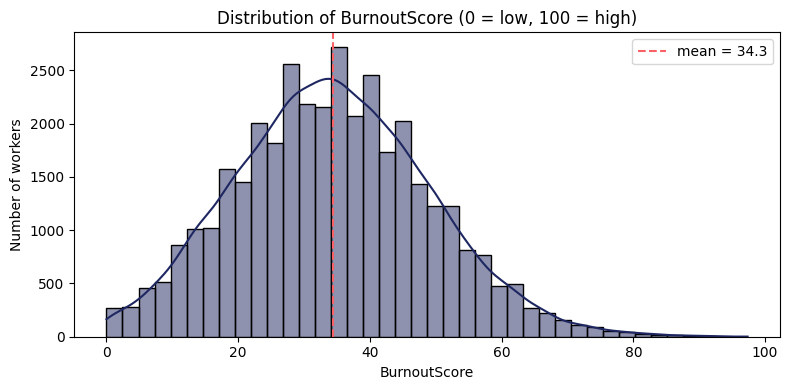

In [46]:
# Distribution of the continuous BurnoutScore.
plt.figure(figsize=(8, 4))
sns.histplot(df['BurnoutScore'].dropna(), bins=40, kde=True, color='#1E2761')
plt.axvline(df['BurnoutScore'].mean(), color='#F96167', linestyle='--', label=f"mean = {df['BurnoutScore'].mean():.1f}")
plt.title('Distribution of BurnoutScore (0 = low, 100 = high)')
plt.xlabel('BurnoutScore')
plt.ylabel('Number of workers')
plt.legend()
plt.tight_layout()
plt.show()


Create the BurnoutRisk classes (Low / Medium / High)

We need to turn the continuous score into three risk classes. There are two defensible ways to set the cut-points, and we provide both. **Choose ONE for the modelling stage and justify it in the write-up.**

**Option A — Tertiles (data-driven, balanced classes).**
Split at the 33rd and 67th percentiles, giving roughly equal-sized Low / Medium / High groups. This is the safest default for a classification model because it avoids severe class imbalance.

**Option B — Fixed conceptual thresholds.**
Use fixed cut-points on the 0-100 scale (e.g. <40 = Low, 40-60 = Medium, >60 = High). This is easier to interpret ("a score above 60 is high risk") but can produce imbalanced classes depending on the real distribution.

The notebook computes both; `BurnoutRisk` defaults to the tertile version. Swap the commented line to use the fixed-threshold version instead.

In [47]:
# ---- Option A: tertile-based classes (default) ----
q33, q67 = df['BurnoutScore'].quantile([0.33, 0.67])
print(f"Tertile cut-points: 33rd pct = {q33:.1f}, 67th pct = {q67:.1f}")

df['BurnoutRisk_tertile'] = pd.cut(
    df['BurnoutScore'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Medium', 'High']
)

# ---- Option B: fixed conceptual thresholds ----
df['BurnoutRisk_fixed'] = pd.cut(
    df['BurnoutScore'],
    bins=[-np.inf, 40, 60, np.inf],
    labels=['Low', 'Medium', 'High']
)

# Default BurnoutRisk = tertile version (change to _fixed if preferred).
df['BurnoutRisk'] = df['BurnoutRisk_tertile']

print("\nBurnoutRisk (tertile) counts:")
print(df['BurnoutRisk_tertile'].value_counts())
print("\nBurnoutRisk (fixed) counts:")
print(df['BurnoutRisk_fixed'].value_counts())


Tertile cut-points: 33rd pct = 27.5, 67th pct = 40.7

BurnoutRisk (tertile) counts:
BurnoutRisk_tertile
Medium    12371
Low       12239
High      12012
Name: count, dtype: int64

BurnoutRisk (fixed) counts:
BurnoutRisk_fixed
Low       23915
Medium    11077
High       1630
Name: count, dtype: int64


/tmp/ipykernel_923/1904287509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette=palette, ax=ax)
/tmp/ipykernel_923/1904287509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette=palette, ax=ax)


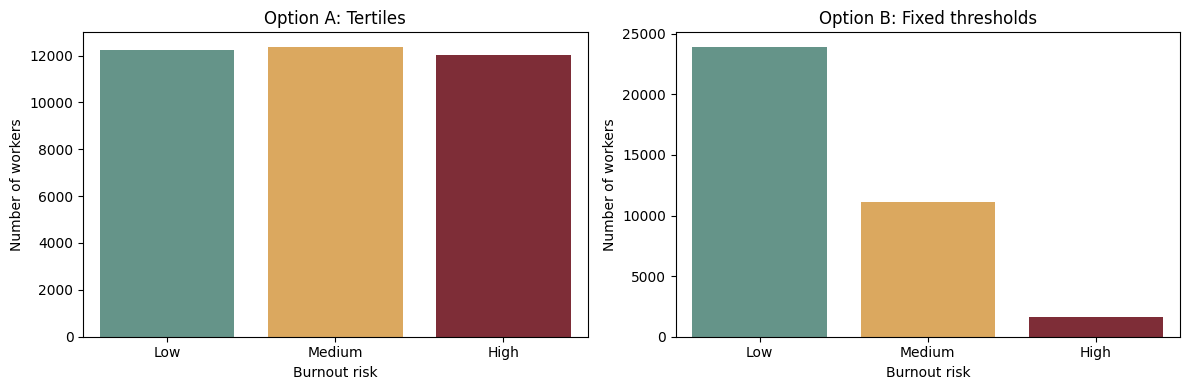

In [48]:
# Visual comparison of the two class definitions.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ['Low', 'Medium', 'High']
palette = {'Low': '#5D9C8D', 'Medium': '#F0AC4A', 'High': '#8C1F2D'}

for ax, col, title in zip(axes,
                          ['BurnoutRisk_tertile', 'BurnoutRisk_fixed'],
                          ['Option A: Tertiles', 'Option B: Fixed thresholds']):
    sns.countplot(x=df[col], order=order, palette=palette, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Burnout risk')
    ax.set_ylabel('Number of workers')

plt.tight_layout()
plt.show()


Feature-engineering indices

Beyond the target, Person 2 creates the three **predictor indices** named in the brief, each summarising a block of related items into a single interpretable score. Each index is built with the same normalise-to-0-1 logic and is the row-wise mean of its items.

We build:
- **WorkloadIndex** — quantitative work demands / intensity (higher = heavier workload)
- **SupportIndex** — social support and good leadership (higher = MORE support; a *resource*)
- **WorkLifeConflictIndex** — degree of work-life conflict (higher = MORE conflict)

**Note on overlap:** the work-life conflict items appear in both the target and `WorkLifeConflictIndex`. If you train a model to predict `BurnoutScore`, you must **drop `WorkLifeConflictIndex` (and the raw exhaustion / engagement / stress items) from the feature set** to avoid target leakage. The index is provided for descriptive analysis and for models that use a different target (e.g. predicting turnover).

In [49]:
def build_index(item_dict, name):
    """Build a 0..1 index as the row-wise mean of normalised items. 1 = more of the construct."""
    present = {k: v for k, v in item_dict.items() if k in df.columns}
    if not present:
        print(f"[skip] {name}: none of its items are in the dataframe")
        return None
    block = pd.DataFrame(index=df.index)
    for var, (lo, hi, direction) in present.items():
        block[var] = normalise_item(df[var], lo, hi, direction)
    print(f"{name:22s} built from {len(present)} items: {list(present)}")
    return block.mean(axis=1, skipna=True)


# WORKLOAD / work intensity. highspeed & tightdead are 1=All the time..7=Never (bad_is_low).
# enough_time 1=Always..5=Never: NOT having enough time is the burden -> bad_is_high.
# interrupt 1=Very often..4=Never (bad_is_low). contact_out_wh 1=Daily..5=Never (bad_is_low).
WORKLOAD_ITEMS = {
    'highspeed':      (1, 7, 'bad_is_low'),
    'tightdead':      (1, 7, 'bad_is_low'),
    'enough_time':    (1, 5, 'bad_is_high'),
    'interrupt':      (1, 4, 'bad_is_low'),
    'contact_out_wh': (1, 5, 'bad_is_low'),
}

# SUPPORT (a resource: higher index = MORE support).
# support_* 1=Always..5=Never: support ALWAYS = high support, so a low code = more support (bad_is_low).
# boss_* 1=Strongly agree..5=Strongly disagree: agreeing = more support, so a low code = more support.
SUPPORT_ITEMS = {
    'support_manager':    (1, 5, 'bad_is_low'),
    'support_colleagues': (1, 5, 'bad_is_low'),
    'consulted':          (1, 5, 'bad_is_low'),
    'boss_respect':       (1, 5, 'bad_is_low'),
    'boss_feedback':      (1, 5, 'bad_is_low'),
    'boss_development':   (1, 5, 'bad_is_low'),
}

# Build the three indices named in the brief.
df['WorkloadIndex']         = build_index(WORKLOAD_ITEMS, 'WorkloadIndex')
df['SupportIndex']          = build_index(SUPPORT_ITEMS, 'SupportIndex')
df['WorkLifeConflictIndex'] = WorkLifeConflict   # already computed in step 4 (0..1)


WorkloadIndex          built from 5 items: ['highspeed', 'tightdead', 'enough_time', 'interrupt', 'contact_out_wh']
SupportIndex           built from 6 items: ['support_manager', 'support_colleagues', 'consulted', 'boss_respect', 'boss_feedback', 'boss_development']


In [50]:
# Scale all indices to 0..100 for readability and store summary.
index_cols = ['WorkloadIndex', 'SupportIndex', 'WorkLifeConflictIndex']
for c in index_cols:
    if c in df.columns:
        df[c] = (df[c] * 100).round(1)

df[index_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
WorkloadIndex,36643.0,37.097143,19.281895,0.0,22.9,36.7,50.0,100.0
SupportIndex,30597.0,72.663284,19.494919,0.0,62.5,75.0,87.5,100.0
WorkLifeConflictIndex,36643.0,33.014952,18.961992,0.0,20.0,31.7,46.7,100.0


Validation checks

Two quick checks that the target behaves the way burnout theory predicts. These are useful evidence for the methodology chapter.

1. **Convergent validity with WHO-5 wellbeing.** EWCS 2024 ships a pre-computed WHO-5 `wellbeing` score (0-100, higher = better wellbeing). Our `BurnoutScore` should be **negatively correlated** with it — more burnout, lower wellbeing.
2. **Theory-consistent index relationships.** `BurnoutScore` should rise with `WorkloadIndex` (more demands, more burnout) and with `WorkLifeConflictIndex`, and fall with `SupportIndex` (support is a protective resource).

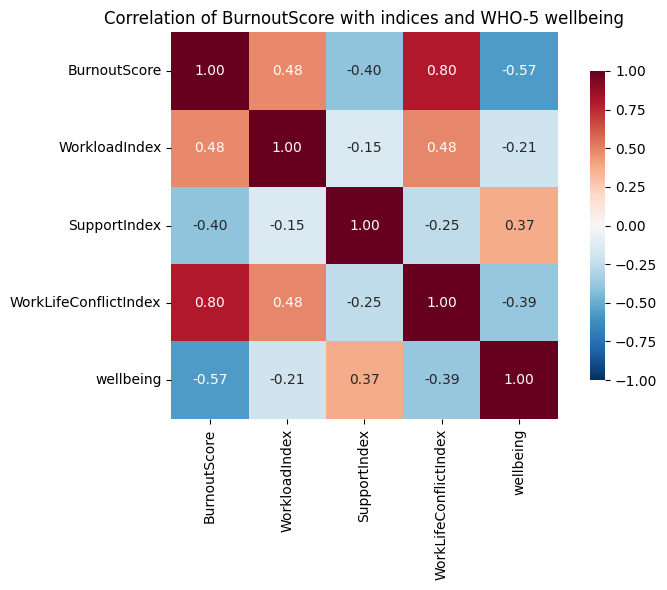

BurnoutScore vs WHO-5 wellbeing: r = -0.567  (expected to be NEGATIVE)


In [51]:
checks = ['BurnoutScore', 'WorkloadIndex', 'SupportIndex', 'WorkLifeConflictIndex']
if 'wellbeing' in df.columns:
    checks.append('wellbeing')

corr = df[checks].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation of BurnoutScore with indices and WHO-5 wellbeing')
plt.tight_layout()
plt.show()

if 'wellbeing' in df.columns:
    r = corr.loc['BurnoutScore', 'wellbeing']
    print(f"BurnoutScore vs WHO-5 wellbeing: r = {r:.3f}  (expected to be NEGATIVE)")


In [52]:
# Internal consistency (Cronbach's alpha) of the full burnout item set.
def cronbach_alpha(frame):
    frame = frame.dropna()
    k = frame.shape[1]
    if k < 2 or len(frame) == 0:
        return np.nan
    item_var = frame.var(axis=0, ddof=1).sum()
    total_var = frame.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

# Combine all normalised burnout items (exhaustion + disengagement + work-life).
all_burnout_norm = pd.concat([exh_norm, dis_norm, wlc_norm], axis=1)
alpha = cronbach_alpha(all_burnout_norm)
print(f"Cronbach's alpha (all {all_burnout_norm.shape[1]} burnout items): {alpha:.3f}")
print("Rule of thumb: > 0.70 acceptable, > 0.80 good.")


Cronbach's alpha (all 11 burnout items): 0.810
Rule of thumb: > 0.70 acceptable, > 0.80 good.


## 9. Save the engineered dataset

We write out the dataset with the new target columns and indices for Person 3 (modelling). We keep everything Angarika produced and simply add the new columns.

In [53]:
new_cols = ['BurnoutScore', 'BurnoutRisk', 'BurnoutRisk_tertile', 'BurnoutRisk_fixed',
            'WorkloadIndex', 'SupportIndex', 'WorkLifeConflictIndex']
print("Columns added by Person 2:")
for c in new_cols:
    print("  -", c)

df.to_csv('/content/drive/MyDrive/Artefact V2/EWCS2024_FeatureEngineered.csv', index=False)
print("\nSaved: EWCS2024_FeatureEngineered.csv")
print("Final shape:", df.shape)


Columns added by Person 2:
  - BurnoutScore
  - BurnoutRisk
  - BurnoutRisk_tertile
  - BurnoutRisk_fixed
  - WorkloadIndex
  - SupportIndex
  - WorkLifeConflictIndex

Saved: EWCS2024_FeatureEngineered.csv
Final shape: (36644, 393)


## 10. Hand-off notes for Person 3 (modelling)

**Targets available**
- `BurnoutScore` — continuous 0-100 (use for regression)
- `BurnoutRisk` — 3-class Low / Medium / High (use for classification; defaults to tertiles)

**Leakage warning — must drop before training a model that predicts burnout:**
The following were used to *build* the target and must NOT be features when predicting it:
`exhaust_emot`, `exhaust_phys`, `stress`, `eng_energy`, `eng_enthusiastic`, `eng_timeflies`,
`work_life_balance`, `wlb_worry`, `wlb_tired`, `wlb_timefamily`, `wlb_concentrate`,
and the derived `WorkLifeConflictIndex`.

**Recommended safe predictors:** `WorkloadIndex`, `SupportIndex`,
plus structural variables (sector `NACE0_lbl`, occupation `ISCO_1`, `wp_size`, `empl_contract`,
`age`, `sex2`, `isced`, country) and the technology / organisational-climate items.

**Decision still open:** which `BurnoutRisk` definition to use (tertile vs fixed). Tertiles give balanced classes for cleaner classification metrics; fixed thresholds are easier to interpret. Document the choice.


# IS6611 Applied Research in Business Analytics
## Employee Burnout Prediction -- Group 6
### Part 3: Exploratory Data Analysis & Visualisations
**Person 3 -- Sharan**

This notebook loads the feature-engineered dataset produced by Person 2 (Tanya) and produces a full suite of EDA charts across 9 sections.

| Section | Focus |
|---------|-------|
| 0 | Thematic column map |
| 1 | Burnout target overview |
| 2 | Workload pressure |
| 3 | Low autonomy |
| 4 | Lack of support |
| 5 | Work-life conflict and stress |
| 6 | Health and engagement consequences |
| 7 | Which reason causes burnout most? |
| 8 | Who is most affected? (demographics) |
| 9 | Driver correlations (hand-off to modelling) |


## Setup -- imports, Google Drive, dataset load

In [54]:
# ── Part 3 is designed to run independently. ──────────────────────────────────
# Re-mount Drive and re-import all libraries so this section works even if
# the Colab runtime was reset after Parts 1 & 2 finished.

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Global colour palette
PALETTE  = {'Low': '#5D9C8D', 'Medium': '#F0AC4A', 'High': '#8C1F2D'}
ORDER    = ['Low', 'Medium', 'High']
BLUE     = '#1E2761'
ACCENT   = '#F0AC4A'
RED      = '#8C1F2D'
TEAL     = '#5D9C8D'
GREY     = '#6c757d'

plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
})
sns.set_theme(style='whitegrid', palette='muted')
pct_fmt = FuncFormatter(lambda x, _: f'{x:.0f}%')
print('Libraries loaded.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded.


In [55]:
# Load the feature-engineered dataset (output of Tanya's Part 2)
# Part 3 loads its own fresh copy of the feature-engineered CSV.
# This means Part 3 is NOT affected if Tanya's Part 2 modified df in memory.
# It also means Part 3 runs correctly even if Parts 1 & 2 were never run.

df = pd.read_csv('/content/drive/MyDrive/Artefact V2/EWCS2024_FeatureEngineered.csv')
print(f'Dataset loaded. Shape: {df.shape}')

# Ensure BurnoutRisk is an ordered categorical so groupby/plots sort correctly
df['BurnoutRisk'] = pd.Categorical(df['BurnoutRisk'], categories=ORDER, ordered=True)

# Helper: safely convert any column to numeric (returns empty Series if column missing)
def to_num(col):
    return pd.to_numeric(df[col], errors='coerce') if col in df.columns else pd.Series(dtype=float)

key_cols = [
    'BurnoutScore','BurnoutRisk','WorkloadIndex','SupportIndex',
    'WorkLifeConflictIndex','stress','wellbeing','quit_job',
    'exhaust_emot','exhaust_phys','eng_energy','eng_enthusiastic','eng_timeflies',
    'wlb_tired','wlb_worry','wlb_timefamily',
    'highspeed','tightdead','norest',
    'autonomy_speed','autonomy_methods','autonomy_order',
    'support_manager','support_colleagues','boss_respect','boss_feedback','boss_development',
]
print('Key column availability:')
for c in key_cols:
    status = 'OK' if c in df.columns else 'MISSING'
    print(f'  [{status}]  {c}')

print(f'\nSetup complete. df has {df.shape[0]:,} rows and {df.shape[1]} columns.')


Dataset loaded. Shape: (36644, 393)
Key column availability:
  [OK]  BurnoutScore
  [OK]  BurnoutRisk
  [OK]  WorkloadIndex
  [OK]  SupportIndex
  [OK]  WorkLifeConflictIndex
  [OK]  stress
  [OK]  wellbeing
  [OK]  quit_job
  [OK]  exhaust_emot
  [OK]  exhaust_phys
  [OK]  eng_energy
  [OK]  eng_enthusiastic
  [OK]  eng_timeflies
  [OK]  wlb_tired
  [OK]  wlb_worry
  [OK]  wlb_timefamily
  [OK]  highspeed
  [OK]  tightdead
  [OK]  norest
  [OK]  autonomy_speed
  [OK]  autonomy_methods
  [OK]  autonomy_order
  [OK]  support_manager
  [OK]  support_colleagues
  [OK]  boss_respect
  [OK]  boss_feedback
  [OK]  boss_development

Setup complete. df has 36,644 rows and 393 columns.


In [56]:
# Ensure BurnoutRisk is ordered categorical
df['BurnoutRisk'] = pd.Categorical(df['BurnoutRisk'], categories=ORDER, ordered=True)

def to_num(col):
    return pd.to_numeric(df[col], errors='coerce') if col in df.columns else pd.Series(dtype=float)

print('Setup complete -- ready for EDA.')


Setup complete -- ready for EDA.


---
## Section 0 -- Thematic Column Map

The EWCS 2024 dataset has 386 columns. For EDA we collapse them into 8 interpretable themes aligned with the Job Demands-Resources (JD-R) framework. Each theme is either a **demand** (increases burnout risk) or a **resource** (buffers it).


Theme                            Category             Role       # Cols
---------------------------------------------------------------------------
Workload / Work Demands          WORK / STRESS        Demand         40
Autonomy / Control               CONTROL              Resource       28
Social Support                   SUPPORT              Resource       32
Work-Life Balance                HEALTH / STRESS      Demand         18
Health & Wellbeing               HEALTH               Outcome        24
Engagement                       ENGAGE               Resource       22
Demographics & Job Context       DEMO / CONTEXT       Context        62
Improvement Priorities           INSIGHT              Insight         8
---------------------------------------------------------------------------


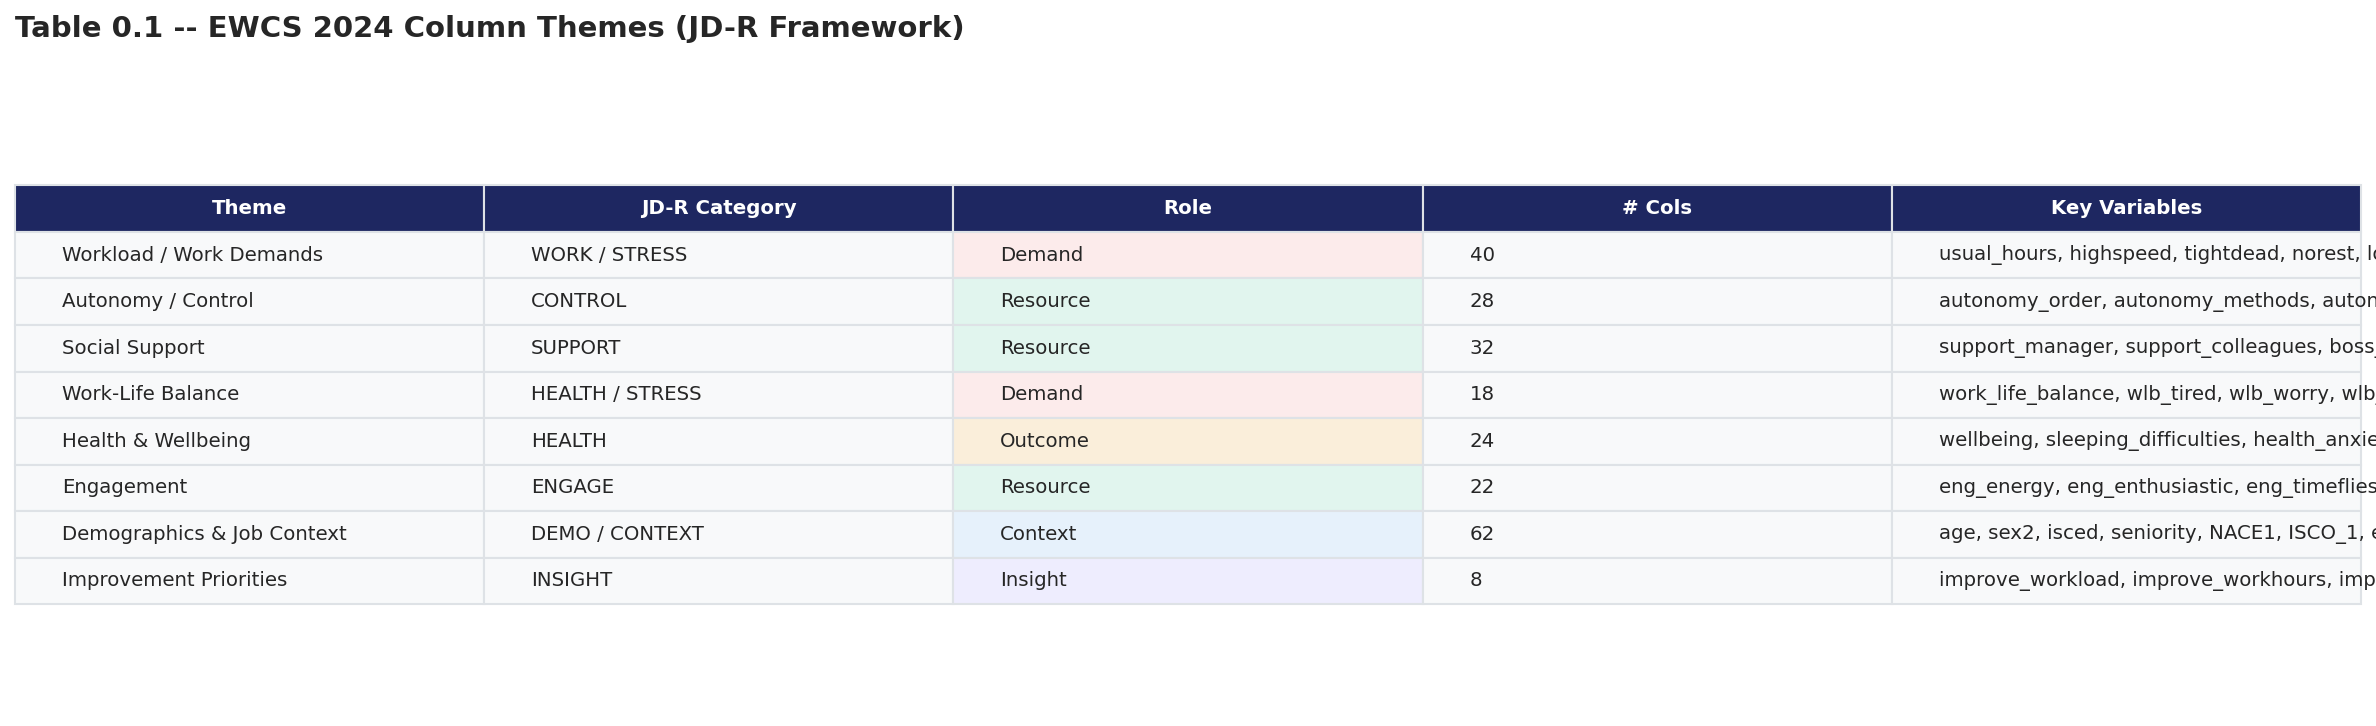

In [57]:
# Chart 0.1 -- Thematic column grouping table
theme_map = [
    ('Workload / Work Demands',    'WORK / STRESS', 'Demand',   40, 'usual_hours, highspeed, tightdead, norest, longday, interrupt, shift'),
    ('Autonomy / Control',         'CONTROL',        'Resource', 28, 'autonomy_order, autonomy_methods, autonomy_speed, take_break, able_hour_off'),
    ('Social Support',             'SUPPORT',        'Resource', 32, 'support_manager, support_colleagues, boss_respect, boss_feedback, boss_development'),
    ('Work-Life Balance',          'HEALTH / STRESS','Demand',   18, 'work_life_balance, wlb_tired, wlb_worry, wlb_timefamily, freetime_work, contact_out_wh'),
    ('Health & Wellbeing',         'HEALTH',         'Outcome',  24, 'wellbeing, sleeping_difficulties, health_anxiety, work_affect_health, lonely, stress'),
    ('Engagement',                 'ENGAGE',         'Resource', 22, 'eng_energy, eng_enthusiastic, eng_timeflies, recognition, useful_work'),
    ('Demographics & Job Context', 'DEMO / CONTEXT', 'Context',  62, 'age, sex2, isced, seniority, NACE1, ISCO_1, empl_contract, wp_size, country'),
    ('Improvement Priorities',     'INSIGHT',        'Insight',   8, 'improve_workload, improve_workhours, improve_pay_benefits, improve_prospects'),
]

print(f'{"Theme":<32} {"Category":<20} {"Role":<10} {"# Cols":>6}')
print('-'*75)
for row in theme_map:
    print(f'{row[0]:<32} {row[1]:<20} {row[2]:<10} {row[3]:>6}')
print('-'*75)

# Visual table
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')
col_labels = ['Theme', 'JD-R Category', 'Role', '# Cols', 'Key Variables']
rows_data = [[r[0], r[1], r[2], str(r[3]), r[4]] for r in theme_map]
role_colors = {'Demand':'#FCEBEB','Resource':'#E1F5EE','Outcome':'#FAEEDA','Context':'#E6F1FB','Insight':'#EEEDFE'}
cell_colors = [[role_colors.get(row[2],'#F8F9FA') if c==2 else '#F8F9FA' for c in range(5)] for row in theme_map]
tbl = ax.table(cellText=rows_data, colLabels=col_labels, cellLoc='left', loc='center',
               cellColours=cell_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#dee2e6')
    if r == 0:
        cell.set_facecolor('#1E2761')
        cell.set_text_props(color='white', fontweight='bold')
ax.set_title('Table 0.1 -- EWCS 2024 Column Themes (JD-R Framework)',
             fontsize=14, fontweight='bold', pad=20, loc='left')
plt.tight_layout()
plt.savefig('chart_0_1_theme_map.png', bbox_inches='tight')
plt.show()


---
## Section 1 -- How Much Burnout Exists? (Target Overview)

Before examining causes, we establish the overall level and distribution of burnout.


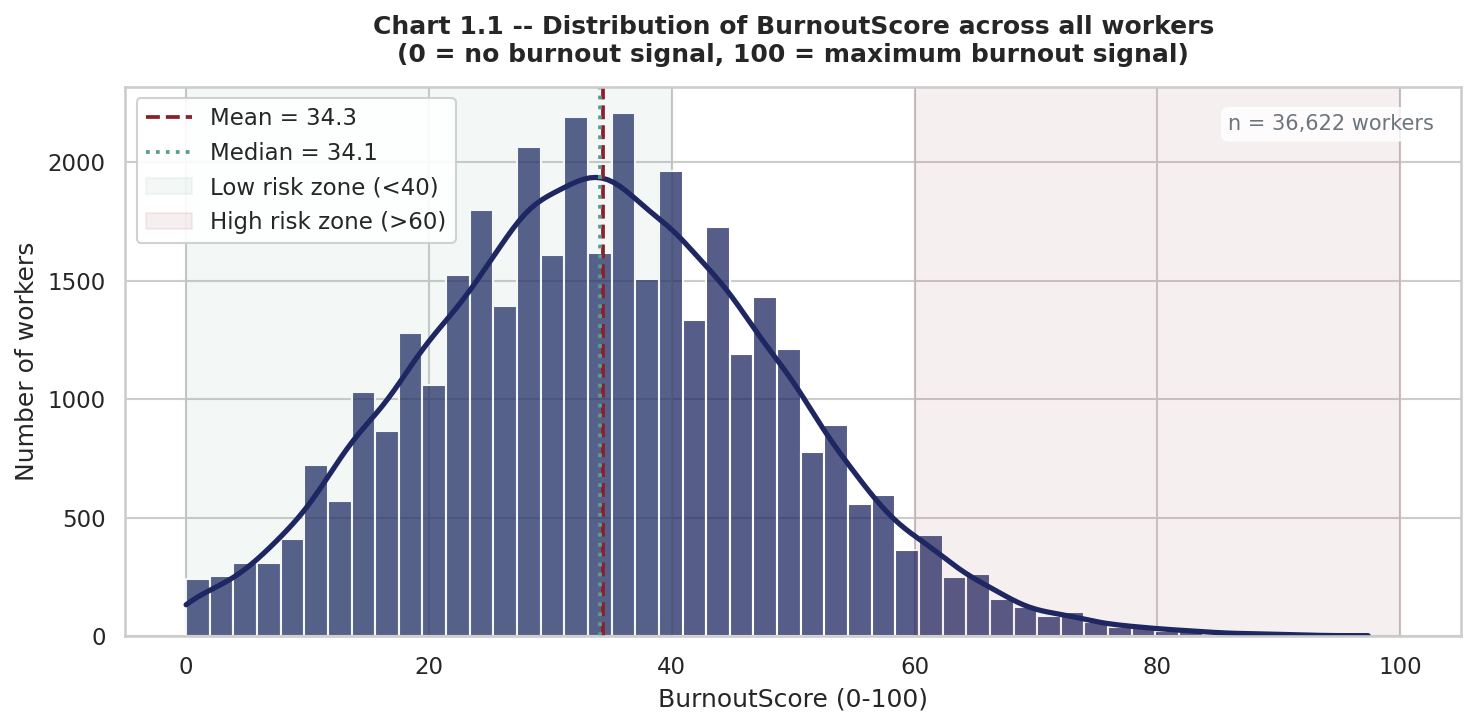

Mean: 34.3  |  Median: 34.1  |  Std: 14.7


In [58]:
# Chart 1.1 -- BurnoutScore histogram + KDE
scores   = to_num('BurnoutScore').dropna()
mean_v   = scores.mean()
median_v = scores.median()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(scores, bins=50, kde=True, color=BLUE, alpha=0.75, ax=ax,
             line_kws={'linewidth': 2.5, 'color': ACCENT})
ax.axvline(mean_v,   color=RED,  linestyle='--', linewidth=1.8, label=f'Mean = {mean_v:.1f}')
ax.axvline(median_v, color=TEAL, linestyle=':',  linewidth=1.8, label=f'Median = {median_v:.1f}')
ax.axvspan(0,   40,  alpha=0.07, color=TEAL, label='Low risk zone (<40)')
ax.axvspan(60, 100,  alpha=0.07, color=RED,  label='High risk zone (>60)')
ax.set_title('Chart 1.1 -- Distribution of BurnoutScore across all workers\n'
             '(0 = no burnout signal, 100 = maximum burnout signal)', pad=12)
ax.set_xlabel('BurnoutScore (0-100)')
ax.set_ylabel('Number of workers')
ax.legend(frameon=True, framealpha=0.9)
ax.annotate(f'n = {len(scores):,} workers', xy=(0.98,0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10, color=GREY,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('chart_1_1_burnout_histogram.png', bbox_inches='tight')
plt.show()
print(f'Mean: {mean_v:.1f}  |  Median: {median_v:.1f}  |  Std: {scores.std():.1f}')


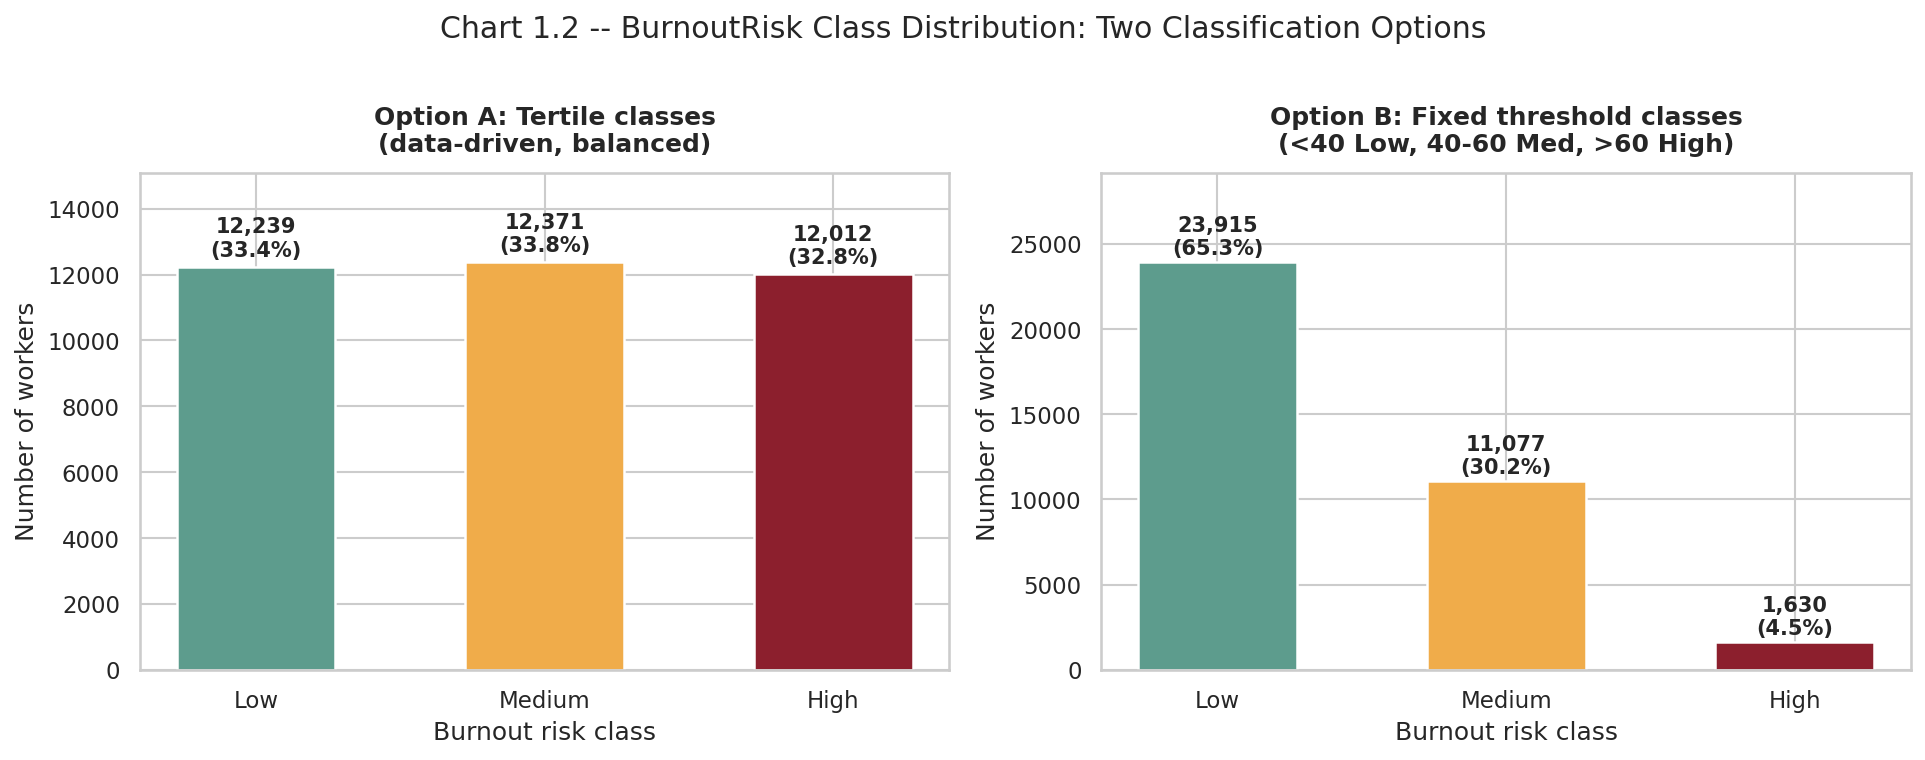

In [59]:
# Chart 1.2 -- BurnoutRisk class counts: tertile vs fixed side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pairs = [
    ('BurnoutRisk_tertile', 'Option A: Tertile classes\n(data-driven, balanced)'),
    ('BurnoutRisk_fixed',   'Option B: Fixed threshold classes\n(<40 Low, 40-60 Med, >60 High)'),
]
for ax, (col, title) in zip(axes, pairs):
    if col not in df.columns:
        ax.text(0.5, 0.5, col + ' not found', ha='center', va='center')
        continue
    counts = df[col].value_counts().reindex(ORDER)
    bars = ax.bar(ORDER, counts.values, color=[PALETTE[r] for r in ORDER],
                  edgecolor='white', linewidth=1.2, width=0.55)
    for bar, val in zip(bars, counts.values):
        pct = val / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(title, pad=10)
    ax.set_xlabel('Burnout risk class')
    ax.set_ylabel('Number of workers')
    ax.set_ylim(0, counts.max() * 1.22)
fig.suptitle('Chart 1.2 -- BurnoutRisk Class Distribution: Two Classification Options', y=1.01)
plt.tight_layout()
plt.savefig('chart_1_2_burnout_risk_classes.png', bbox_inches='tight')
plt.show()


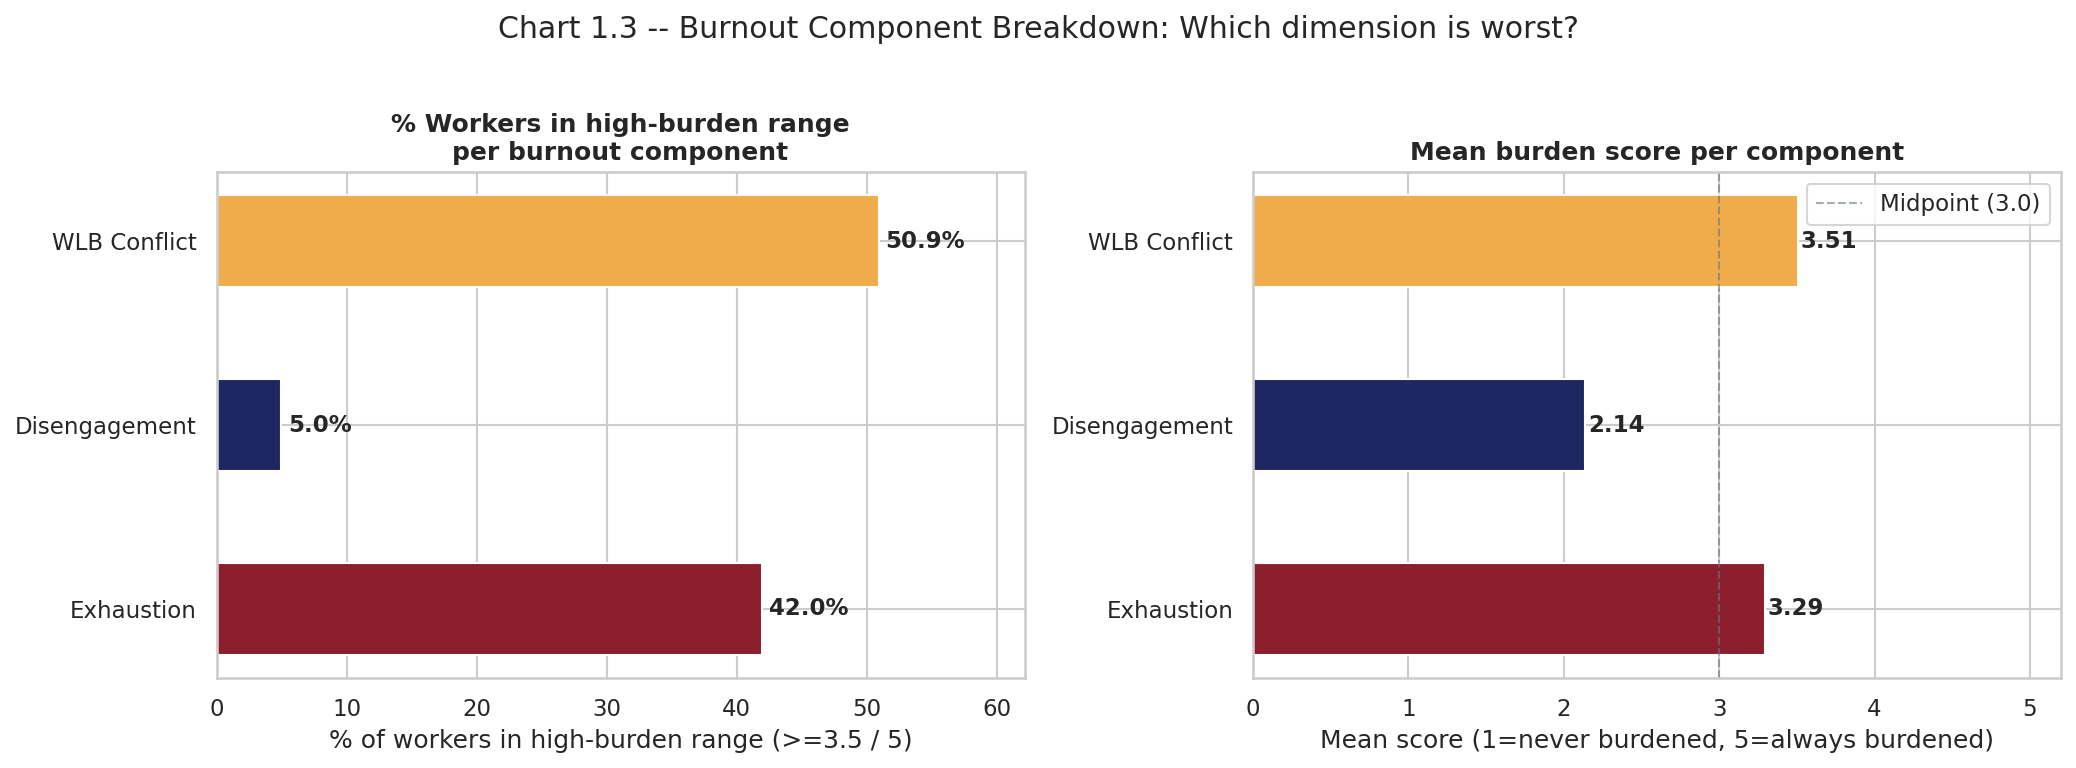

In [60]:
# Chart 1.3 -- Burnout component breakdown
# Which of the 3 components drives the burnout score most?
component_cols = {
    'Exhaustion': ['exhaust_emot','exhaust_phys','stress'],
    'Disengagement': ['eng_energy','eng_enthusiastic','eng_timeflies'],
    'WLB Conflict': ['wlb_tired','wlb_worry','wlb_timefamily'],
}
comp_results = {}
for label, cols in component_cols.items():
    valid = [c for c in cols if c in df.columns]
    if not valid:
        continue
    block = df[valid].apply(pd.to_numeric, errors='coerce')
    mean_per_worker = block.mean(axis=1)
    pct_high = (mean_per_worker >= 3.5).mean() * 100
    overall_mean = mean_per_worker.mean()
    comp_results[label] = {'pct_high': pct_high, 'mean': overall_mean}

if comp_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels_c = list(comp_results.keys())
    pcts_c   = [v['pct_high'] for v in comp_results.values()]
    means_c  = [v['mean']     for v in comp_results.values()]
    colors_c = [RED, BLUE, ACCENT]

    bars = axes[0].barh(labels_c, pcts_c, color=colors_c[:len(labels_c)],
                        edgecolor='white', height=0.5)
    for bar, pct in zip(bars, pcts_c):
        axes[0].text(pct+0.5, bar.get_y()+bar.get_height()/2,
                     f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')
    axes[0].set_xlim(0, max(pcts_c)*1.22)
    axes[0].set_xlabel('% of workers in high-burden range (>=3.5 / 5)')
    axes[0].set_title('% Workers in high-burden range\nper burnout component')

    bars2 = axes[1].barh(labels_c, means_c, color=colors_c[:len(labels_c)],
                         edgecolor='white', height=0.5)
    axes[1].axvline(3.0, color=GREY, linestyle='--', linewidth=1, alpha=0.6, label='Midpoint (3.0)')
    for bar, m in zip(bars2, means_c):
        axes[1].text(m+0.02, bar.get_y()+bar.get_height()/2,
                     f'{m:.2f}', va='center', fontsize=11, fontweight='bold')
    axes[1].set_xlim(0, 5.2)
    axes[1].set_xlabel('Mean score (1=never burdened, 5=always burdened)')
    axes[1].set_title('Mean burden score per component')
    axes[1].legend()

    fig.suptitle('Chart 1.3 -- Burnout Component Breakdown: Which dimension is worst?', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_1_3_burnout_components.png', bbox_inches='tight')
    plt.show()


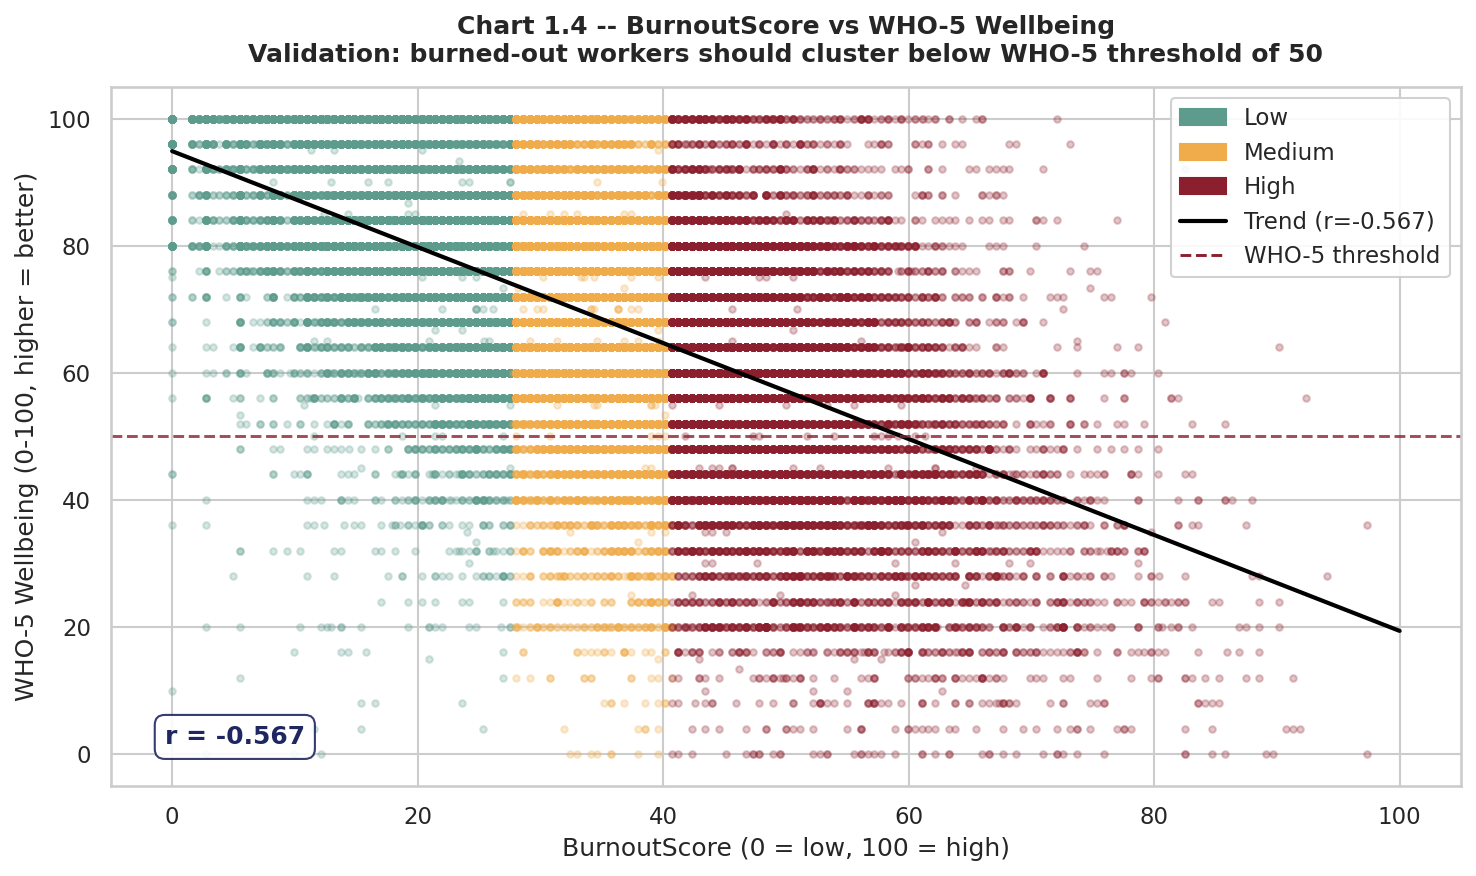

Pearson r (BurnoutScore vs WHO-5): -0.567  -- expected negative


In [61]:
# Chart 1.4 -- BurnoutScore vs WHO-5 Wellbeing (validation scatter)
if 'wellbeing' in df.columns:
    plot_df = pd.DataFrame({
        'BurnoutScore': to_num('BurnoutScore'),
        'Wellbeing':    to_num('wellbeing'),
        'BurnoutRisk':  df['BurnoutRisk']
    }).dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    for risk, grp in plot_df.groupby('BurnoutRisk', observed=True):
        ax.scatter(grp['BurnoutScore'], grp['Wellbeing'],
                   color=PALETTE[risk], alpha=0.25, s=10, label=risk, rasterized=True)

    m, b = np.polyfit(plot_df['BurnoutScore'], plot_df['Wellbeing'], 1)
    xs = np.linspace(0, 100, 200)
    ax.plot(xs, m*xs+b, color='black', linewidth=2, label='Trend line')
    ax.axhline(50, color=RED, linestyle='--', linewidth=1.4, alpha=0.8,
               label='WHO-5 clinical threshold (50)')

    r = plot_df[['BurnoutScore','Wellbeing']].corr().iloc[0,1]
    ax.annotate(f'r = {r:.3f}', xy=(0.04, 0.06), xycoords='axes fraction',
                fontsize=12, fontweight='bold', color=BLUE,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=BLUE, alpha=0.9))

    ax.set_xlabel('BurnoutScore (0 = low, 100 = high)')
    ax.set_ylabel('WHO-5 Wellbeing (0-100, higher = better)')
    ax.set_title('Chart 1.4 -- BurnoutScore vs WHO-5 Wellbeing\n'
                 'Validation: burned-out workers should cluster below WHO-5 threshold of 50', pad=12)
    handles = [mpatches.Patch(color=PALETTE[r2], label=r2) for r2 in ORDER]
    handles += [
        plt.Line2D([0],[0], color='black', linewidth=2, label=f'Trend (r={r:.3f})'),
        plt.Line2D([0],[0], color=RED, linestyle='--', linewidth=1.4, label='WHO-5 threshold')
    ]
    ax.legend(handles=handles, frameon=True, framealpha=0.9)
    plt.tight_layout()
    plt.savefig('chart_1_4_burnout_vs_wellbeing.png', bbox_inches='tight')
    plt.show()
    print(f'Pearson r (BurnoutScore vs WHO-5): {r:.3f}  -- expected negative')
else:
    print('wellbeing column not found -- skipping chart 1.4')


---
## Section 2 -- Workload Pressure as a Burnout Cause

**Theme:** WORK / STRESS | **JD-R role:** Demand  
Key columns: `WorkloadIndex`, `usual_hours`, `highspeed`, `tightdead`, `norest`, `shift`


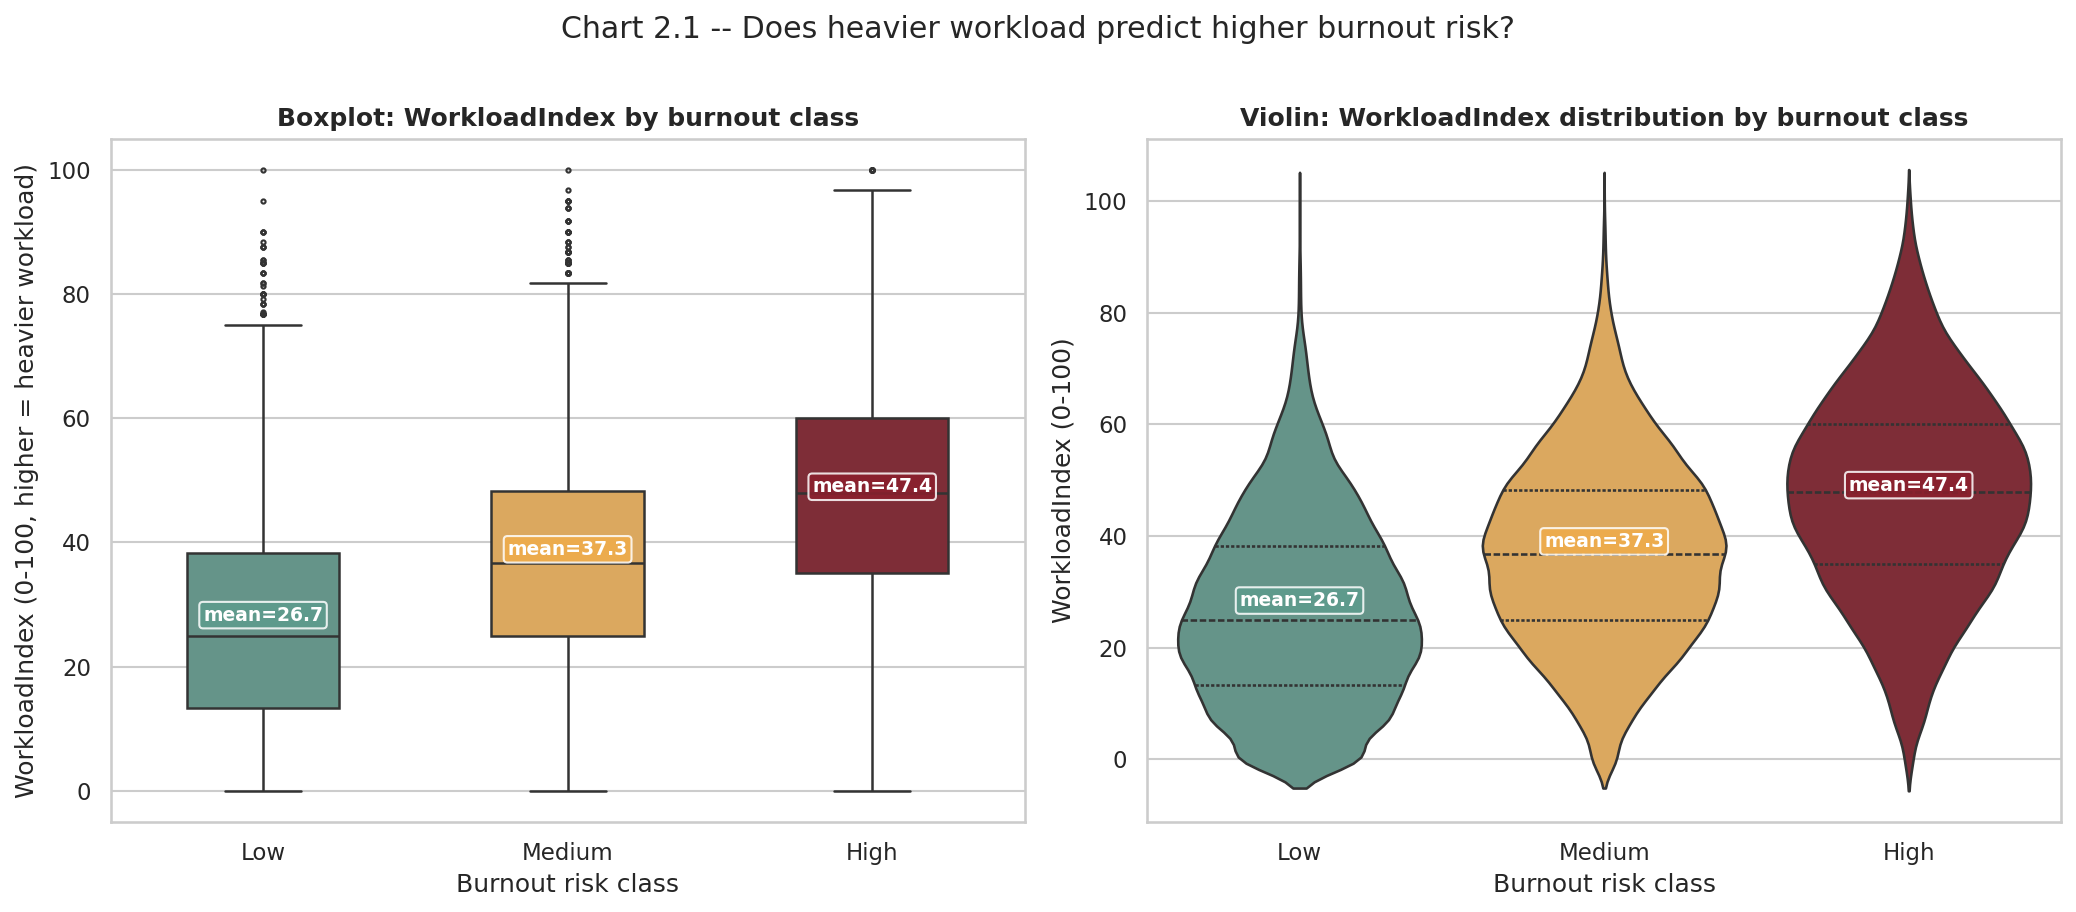

In [62]:
# Chart 2.1 -- WorkloadIndex by BurnoutRisk (boxplot + violin)
if 'WorkloadIndex' in df.columns:
    plot_df = df[['BurnoutRisk','WorkloadIndex']].copy()
    plot_df['WorkloadIndex'] = pd.to_numeric(plot_df['WorkloadIndex'], errors='coerce')
    plot_df = plot_df.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.boxplot(data=plot_df, x='BurnoutRisk', y='WorkloadIndex', order=ORDER,
                palette=PALETTE, width=0.5, fliersize=2, linewidth=1.2, ax=axes[0])
    axes[0].set_title('Boxplot: WorkloadIndex by burnout class')
    axes[0].set_xlabel('Burnout risk class')
    axes[0].set_ylabel('WorkloadIndex (0-100, higher = heavier workload)')

    sns.violinplot(data=plot_df, x='BurnoutRisk', y='WorkloadIndex', order=ORDER,
                   palette=PALETTE, inner='quartile', ax=axes[1])
    axes[1].set_title('Violin: WorkloadIndex distribution by burnout class')
    axes[1].set_xlabel('Burnout risk class')
    axes[1].set_ylabel('WorkloadIndex (0-100)')

    for ax in axes:
        means = plot_df.groupby('BurnoutRisk', observed=True)['WorkloadIndex'].mean().reindex(ORDER)
        for i, (risk, m) in enumerate(means.items()):
            ax.text(i, m, f'mean={m:.1f}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=PALETTE[risk], alpha=0.85))

    fig.suptitle('Chart 2.1 -- Does heavier workload predict higher burnout risk?', y=1.01)
    plt.tight_layout()
    plt.savefig('chart_2_1_workload_by_burnout.png', bbox_inches='tight')
    plt.show()


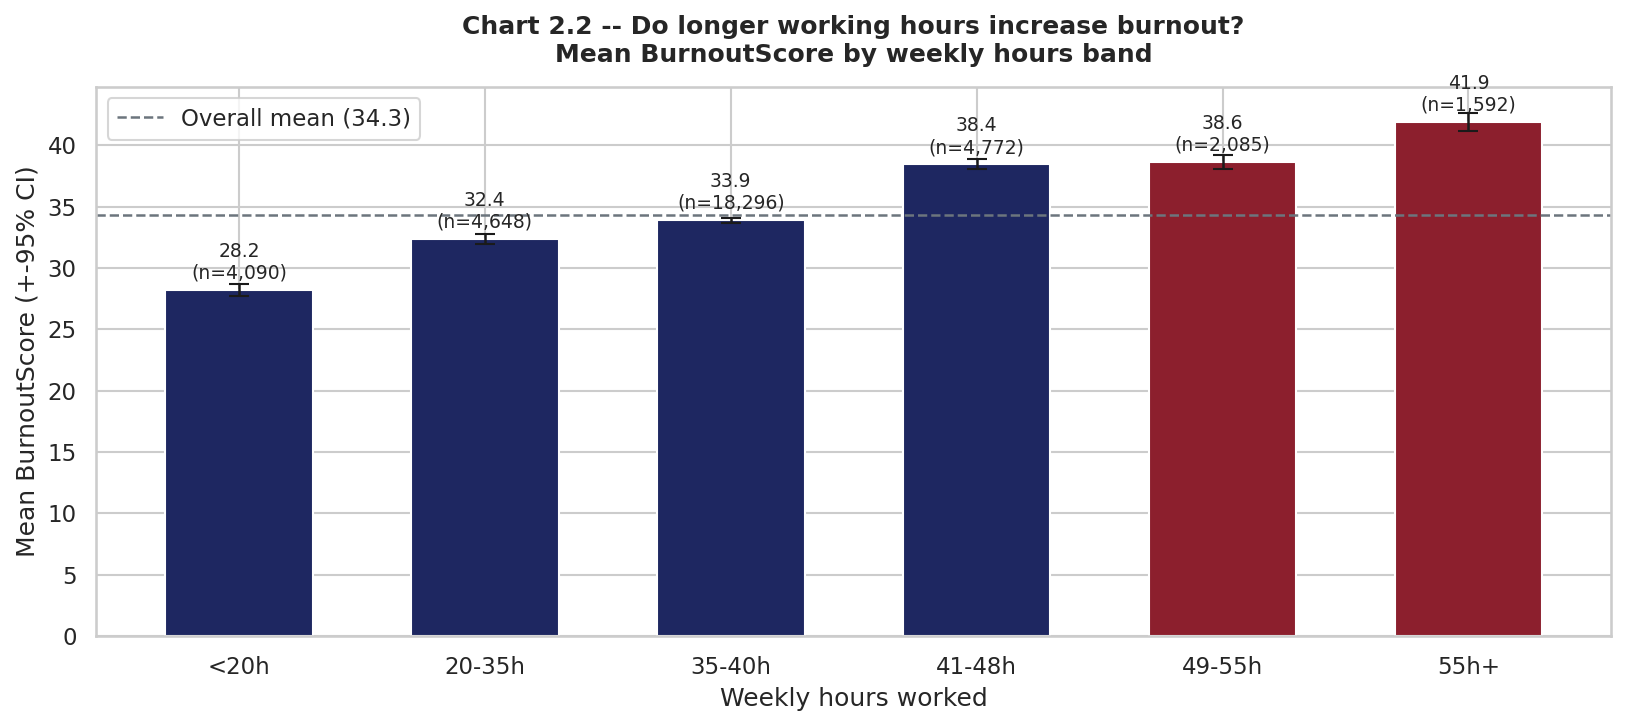

In [63]:
# Chart 2.2 -- Weekly hours worked vs mean BurnoutScore (binned bar)
if 'usual_hours' in df.columns:
    plot_df = pd.DataFrame({
        'hours': to_num('usual_hours'),
        'BurnoutScore': to_num('BurnoutScore')
    }).dropna()
    bins_h   = [0, 20, 35, 40, 48, 55, 999]
    labels_h = ['<20h','20-35h','35-40h','41-48h','49-55h','55h+']
    plot_df['hour_band'] = pd.cut(plot_df['hours'], bins=bins_h, labels=labels_h)
    summary = plot_df.groupby('hour_band', observed=True)['BurnoutScore'].agg(['mean','sem','count']).reset_index()
    summary.columns = ['hour_band','mean','sem','count']

    fig, ax = plt.subplots(figsize=(11, 5))
    bar_colors = [RED if str(l) in ('49-55h','55h+') else BLUE for l in summary['hour_band']]
    bars = ax.bar(summary['hour_band'].astype(str), summary['mean'],
                  color=bar_colors, edgecolor='white', width=0.6,
                  yerr=summary['sem']*1.96, capsize=5,
                  error_kw={'linewidth':1.2})
    for bar, row in zip(bars, summary.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
                f'{row.mean:.1f}\n(n={row.count:,})', ha='center', va='bottom', fontsize=9)
    overall_m = plot_df['BurnoutScore'].mean()
    ax.axhline(overall_m, color=GREY, linestyle='--', linewidth=1.2,
               label=f'Overall mean ({overall_m:.1f})')
    ax.set_xlabel('Weekly hours worked')
    ax.set_ylabel('Mean BurnoutScore (+-95% CI)')
    ax.set_title('Chart 2.2 -- Do longer working hours increase burnout?\n'
                 'Mean BurnoutScore by weekly hours band', pad=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig('chart_2_2_hours_vs_burnout.png', bbox_inches='tight')
    plt.show()


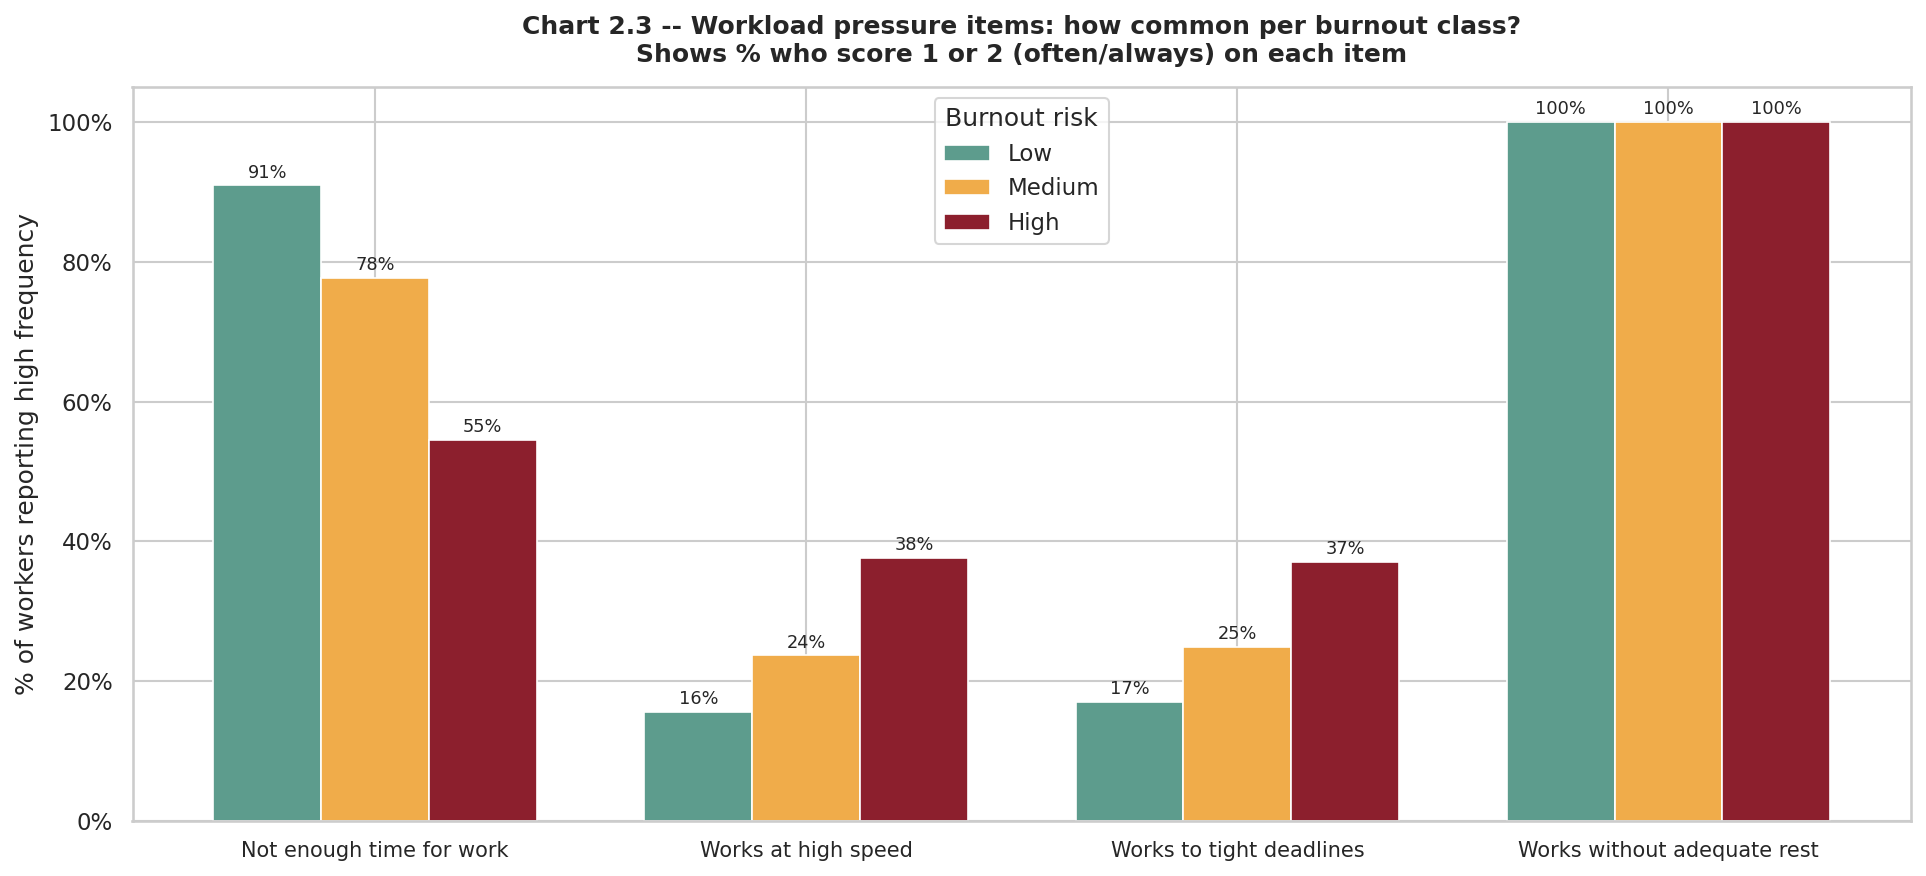

In [64]:
# Chart 2.3 -- High-pressure work items: % reported by burnout class
# "High frequency" is defined as scoring 1 or 2 on the item's scale.
# highspeed & tightdead use a 1=All the time..7=Never scale, so 1-2 = very frequent.
# norest & enough_time use a 1=Always..5=Never scale, so 1-2 = very frequent.
# Using score <= 2 is explicit and consistent across both scale types.
HIGH_FREQ_THRESHOLD = 2  # scores 1 or 2 = "often" or "always"

pressure_items = {
    'Works at high speed': 'highspeed',
    'Works to tight deadlines': 'tightdead',
    'Works without adequate rest': 'norest',
    'Not enough time for work': 'enough_time',
}
valid_items = {k: v for k, v in pressure_items.items() if v in df.columns}

if valid_items and 'BurnoutRisk' in df.columns:
    results = []
    for label, col in valid_items.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            if len(sub) == 0:
                continue
            pct = (sub <= HIGH_FREQ_THRESHOLD).mean() * 100
            results.append({'item': label, 'risk': risk, 'pct': pct})

    res_df = pd.DataFrame(results)
    pivot  = res_df.pivot(index='item', columns='risk', values='pct').reindex(columns=ORDER)

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(pivot))
    w = 0.25
    for i, risk in enumerate(ORDER):
        bars = ax.bar(x + (i-1)*w, pivot[risk], w, label=risk,
                      color=PALETTE[risk], edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, pivot[risk]):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=10)
    ax.set_ylabel('% of workers reporting high frequency')
    ax.set_title('Chart 2.3 -- Workload pressure items: how common per burnout class?\n'
                 'Shows % who score 1 or 2 (often/always) on each item', pad=12)
    ax.legend(title='Burnout risk', frameon=True)
    ax.yaxis.set_major_formatter(pct_fmt)
    plt.tight_layout()
    plt.savefig('chart_2_3_workload_items_by_burnout.png', bbox_inches='tight')
    plt.show()

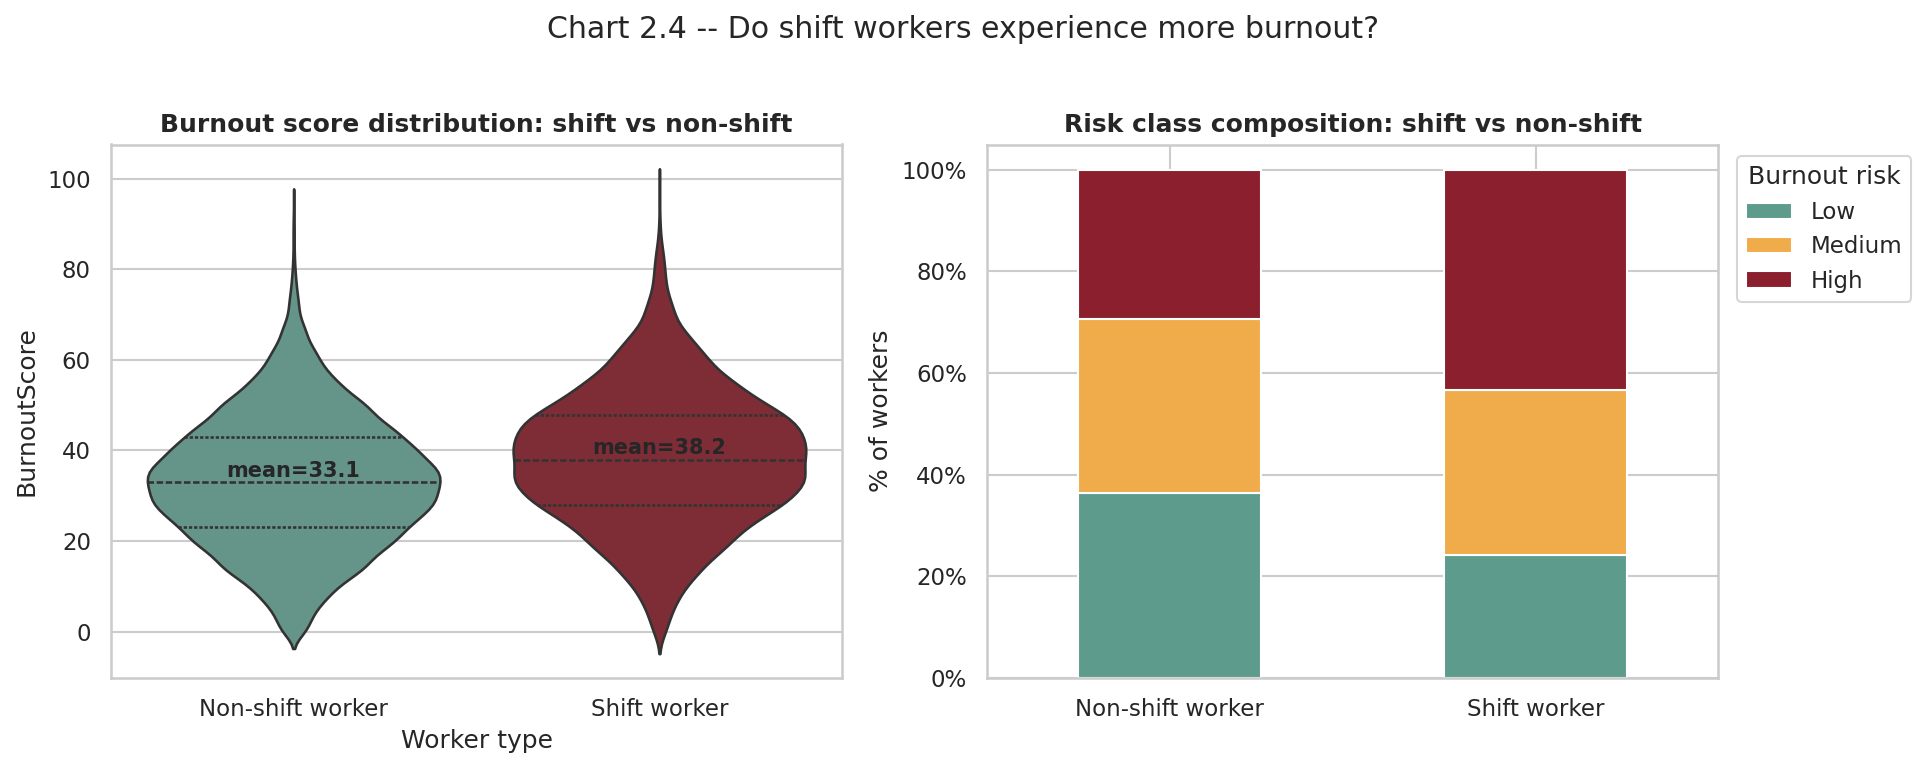

In [65]:
# Chart 2.4 -- Shift workers vs non-shift burnout
if 'shift' in df.columns:
    plot_df = pd.DataFrame({
        'shift': pd.to_numeric(df['shift'], errors='coerce'),
        'BurnoutScore': to_num('BurnoutScore')
    }).dropna()
    plot_df['Worker type'] = plot_df['shift'].map(
        lambda x: 'Shift worker' if x == 1 else 'Non-shift worker'
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.violinplot(data=plot_df, x='Worker type', y='BurnoutScore',
                   palette={'Shift worker': RED, 'Non-shift worker': TEAL},
                   inner='quartile', ax=axes[0])
    means_s = plot_df.groupby('Worker type')['BurnoutScore'].mean()
    for i, (wtype, m) in enumerate(means_s.items()):
        axes[0].text(i, m+1, f'mean={m:.1f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].set_title('Burnout score distribution: shift vs non-shift')
    axes[0].set_ylabel('BurnoutScore')

    risk_comp = pd.crosstab(plot_df['Worker type'],
                             df.loc[plot_df.index,'BurnoutRisk'],
                             normalize='index') * 100
    risk_comp = risk_comp.reindex(columns=ORDER)
    risk_comp.plot(kind='bar', stacked=True, color=[PALETTE[r] for r in ORDER],
                   edgecolor='white', ax=axes[1])
    axes[1].set_title('Risk class composition: shift vs non-shift')
    axes[1].set_ylabel('% of workers')
    axes[1].set_xlabel('')
    axes[1].yaxis.set_major_formatter(pct_fmt)
    axes[1].legend(title='Burnout risk', bbox_to_anchor=(1.01,1))
    plt.setp(axes[1].get_xticklabels(), rotation=0)

    fig.suptitle('Chart 2.4 -- Do shift workers experience more burnout?', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_2_4_shift_vs_burnout.png', bbox_inches='tight')
    plt.show()
else:
    print('shift column not found -- skipping chart 2.4')


---
## Section 3 -- Low Autonomy as a Burnout Cause

**Theme:** CONTROL | **JD-R role:** Resource (higher autonomy = lower burnout risk)  
Key columns: `autonomy_speed`, `autonomy_methods`, `autonomy_order`, `take_break`, `able_hour_off`


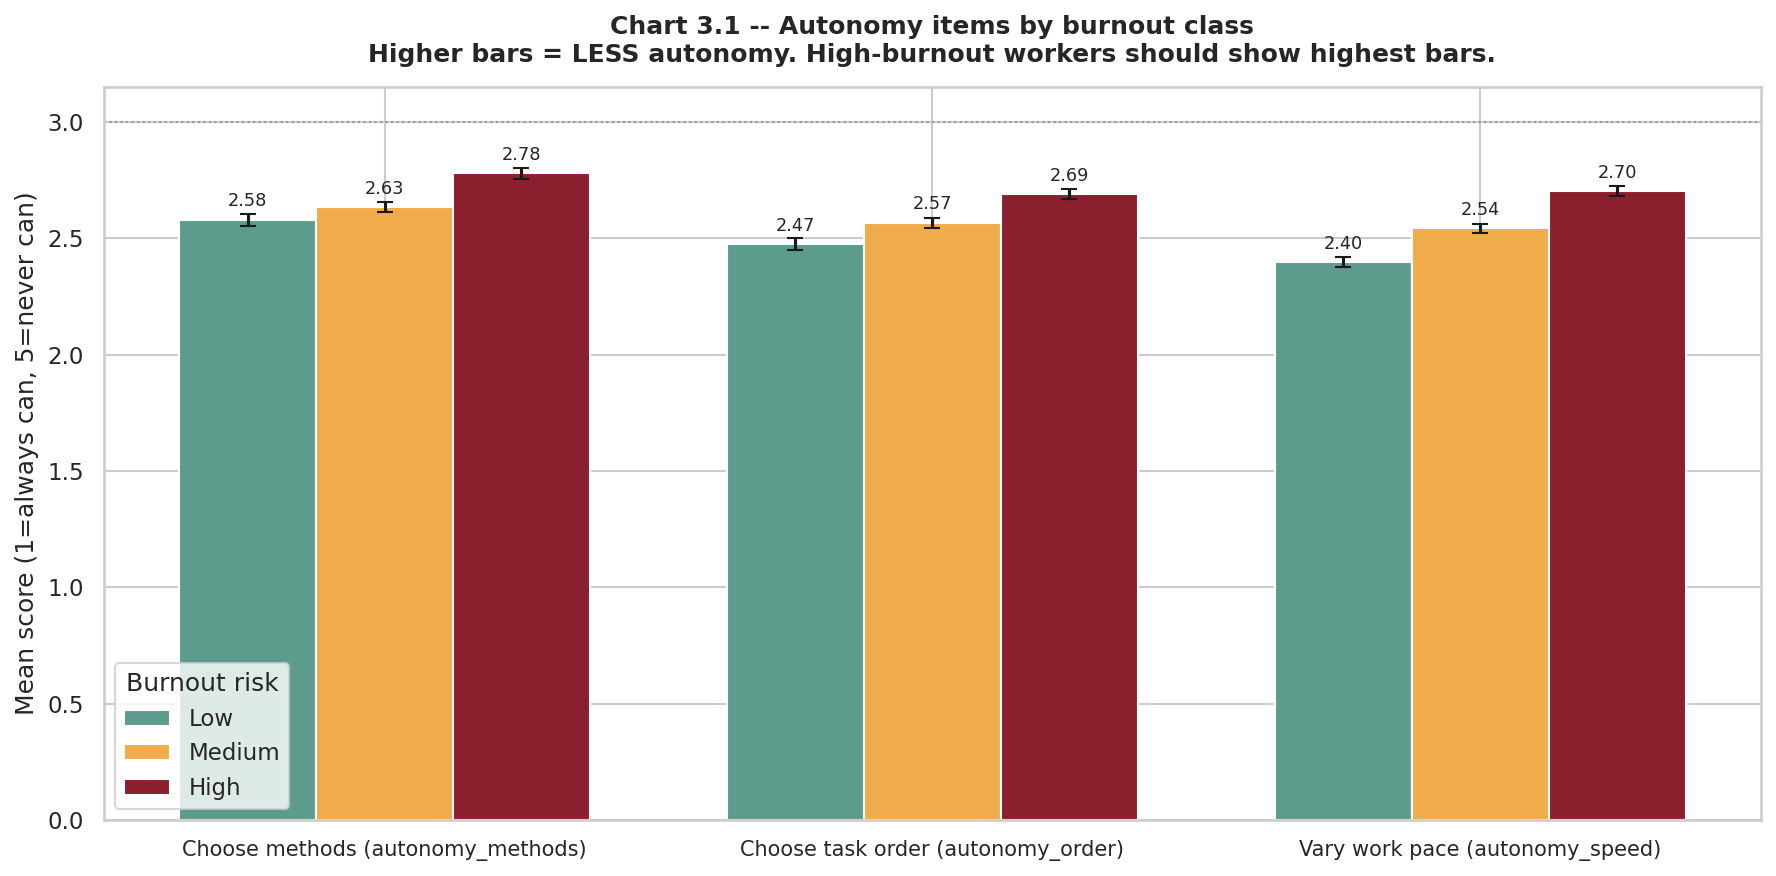

In [66]:
# Chart 3.1 -- Autonomy items mean score by burnout class
auto_items = {
    'Vary work pace (autonomy_speed)':    'autonomy_speed',
    'Choose methods (autonomy_methods)':  'autonomy_methods',
    'Choose task order (autonomy_order)': 'autonomy_order',
}
valid_auto = {k: v for k, v in auto_items.items() if v in df.columns}

if valid_auto and 'BurnoutRisk' in df.columns:
    results = []
    for label, col in valid_auto.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            if len(sub) > 0:
                results.append({'item': label, 'risk': risk, 'mean': sub.mean(), 'sem': sub.sem()})

    res_df = pd.DataFrame(results)
    pivot     = res_df.pivot(index='item', columns='risk', values='mean').reindex(columns=ORDER)
    pivot_sem = res_df.pivot(index='item', columns='risk', values='sem').reindex(columns=ORDER)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(pivot))
    w = 0.25
    for i, risk in enumerate(ORDER):
        bars = ax.bar(x + (i-1)*w, pivot[risk], w, label=risk, color=PALETTE[risk],
                      edgecolor='white', yerr=pivot_sem[risk]*1.96, capsize=4)
        for bar, val in zip(bars, pivot[risk]):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=10)
    ax.set_ylabel('Mean score (1=always can, 5=never can)')
    ax.set_title('Chart 3.1 -- Autonomy items by burnout class\n'
                 'Higher bars = LESS autonomy. High-burnout workers should show highest bars.', pad=12)
    ax.legend(title='Burnout risk')
    ax.axhline(3, color=GREY, linestyle=':', alpha=0.6, linewidth=1)
    plt.tight_layout()
    plt.savefig('chart_3_1_autonomy_by_burnout.png', bbox_inches='tight')
    plt.show()


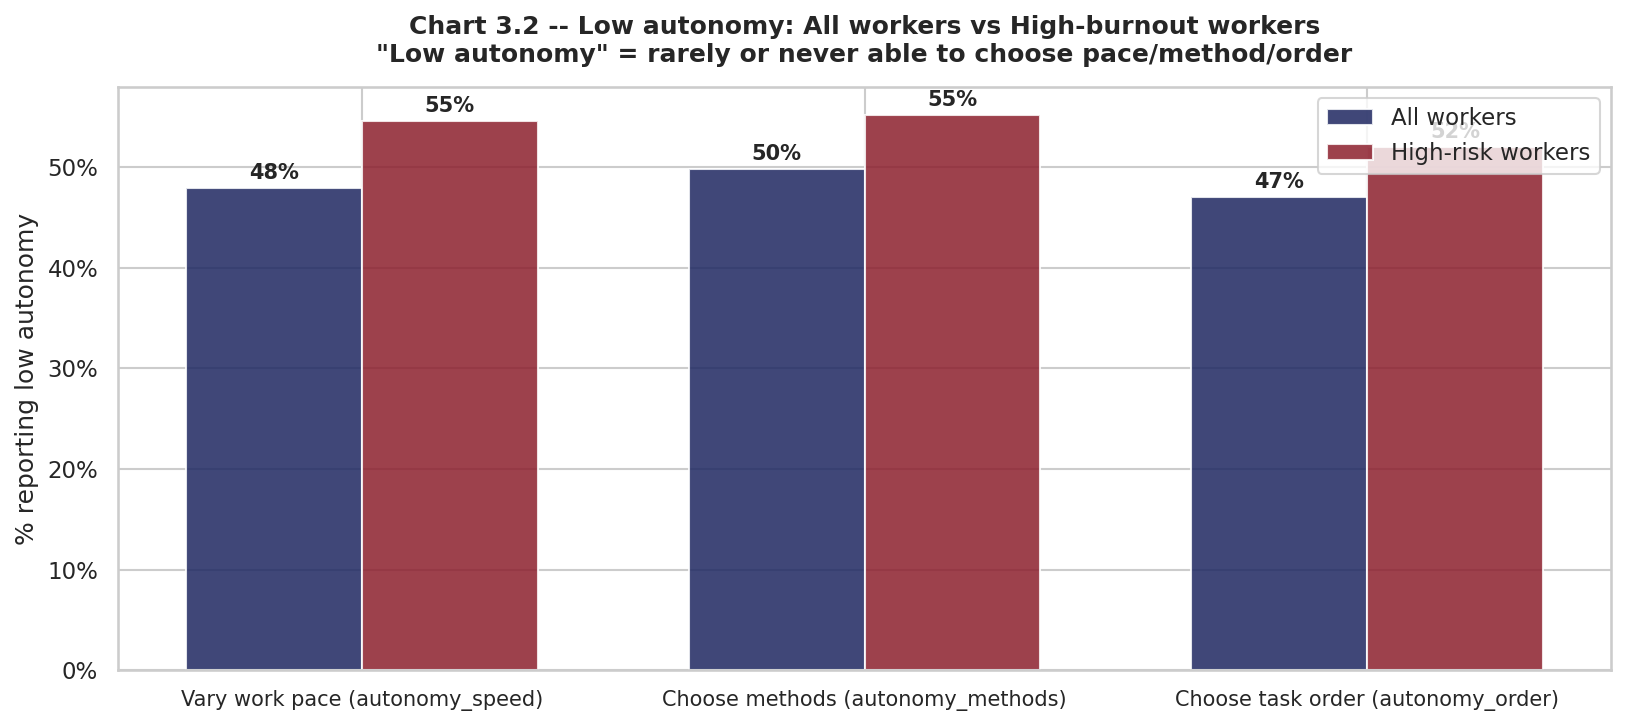

In [67]:
# Chart 3.2 -- % of High-burnout workers reporting low autonomy vs all workers
if valid_auto and 'BurnoutRisk' in df.columns:
    high_df = df[df['BurnoutRisk']=='High']
    labels_list, pcts_all, pcts_high = [], [], []
    for label, col in valid_auto.items():
        col_data = pd.to_numeric(df[col], errors='coerce')
        col_high = pd.to_numeric(high_df[col], errors='coerce')
        hi_scale = col_data.max()
        threshold = hi_scale * 0.6
        labels_list.append(label)
        pcts_all.append((col_data >= threshold).mean() * 100)
        pcts_high.append((col_high >= threshold).mean() * 100)

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(labels_list))
    w = 0.35
    b1 = ax.bar(x - w/2, pcts_all,  w, label='All workers',       color=BLUE, edgecolor='white', alpha=0.85)
    b2 = ax.bar(x + w/2, pcts_high, w, label='High-risk workers', color=RED,  edgecolor='white', alpha=0.85)
    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{bar.get_height():.0f}%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_list, fontsize=10)
    ax.set_ylabel('% reporting low autonomy')
    ax.set_title('Chart 3.2 -- Low autonomy: All workers vs High-burnout workers\n'
                 '"Low autonomy" = rarely or never able to choose pace/method/order', pad=12)
    ax.legend(frameon=True)
    ax.yaxis.set_major_formatter(pct_fmt)
    plt.tight_layout()
    plt.savefig('chart_3_2_low_autonomy_pct.png', bbox_inches='tight')
    plt.show()


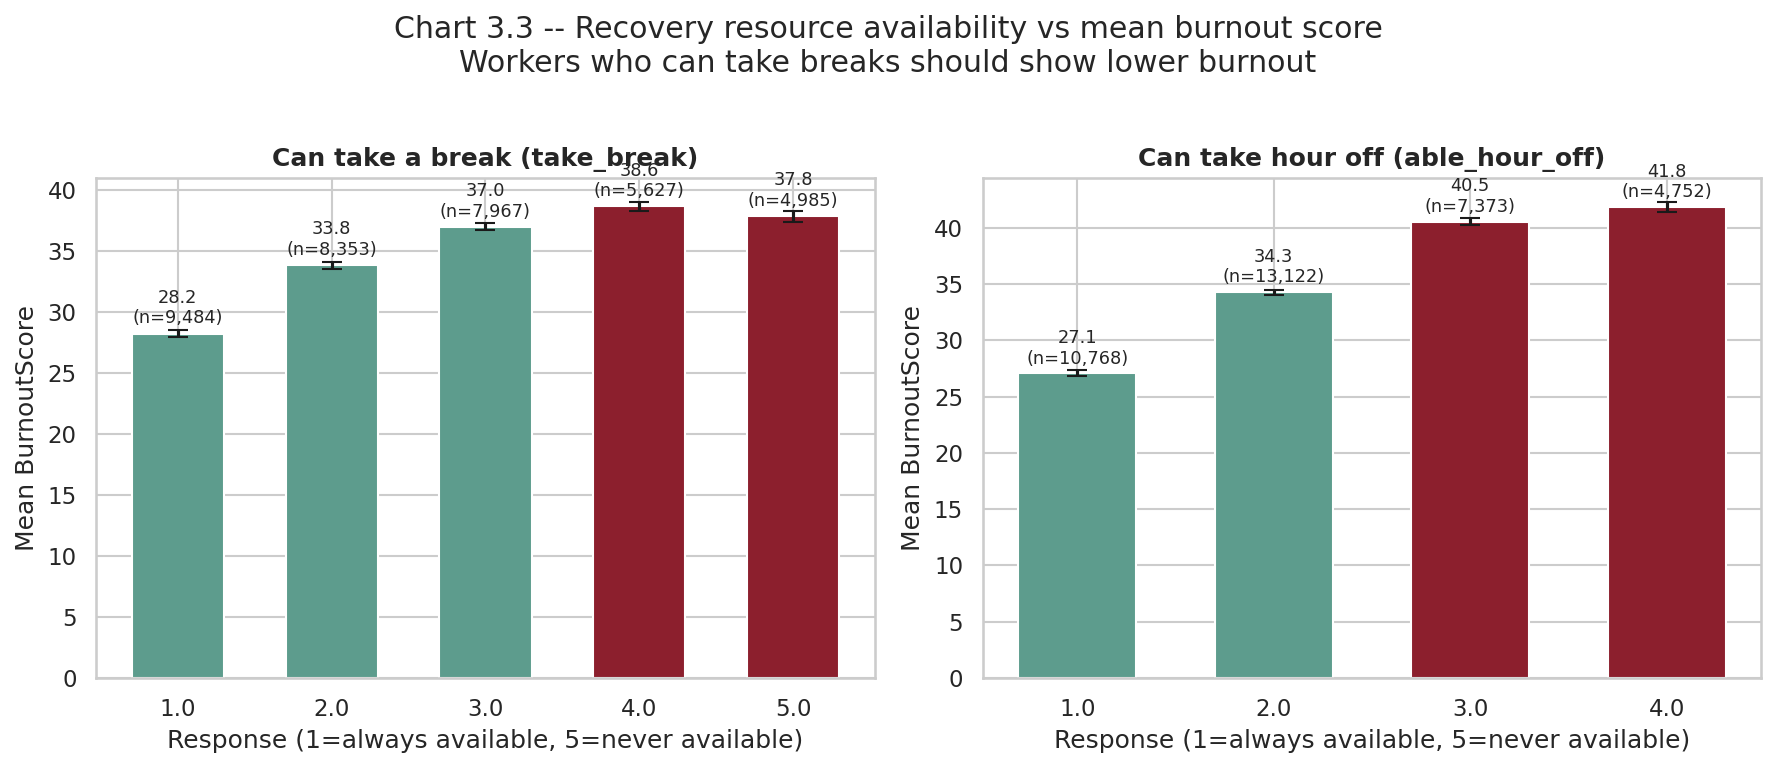

In [68]:
# Chart 3.3 -- Recovery resources vs burnout score
recovery_cols = {
    'Can take a break (take_break)':     'take_break',
    'Can take hour off (able_hour_off)': 'able_hour_off',
}
valid_rec = {k: v for k, v in recovery_cols.items() if v in df.columns}

if valid_rec:
    fig, axes = plt.subplots(1, len(valid_rec), figsize=(6*len(valid_rec), 5))
    if len(valid_rec) == 1:
        axes = [axes]
    for ax, (label, col) in zip(axes, valid_rec.items()):
        vals = pd.to_numeric(df[col], errors='coerce')
        bs   = to_num('BurnoutScore')
        tmp  = pd.DataFrame({'val': vals, 'bs': bs}).dropna()
        grp  = tmp.groupby('val')['bs'].agg(['mean','sem','count']).reset_index()
        med_v = grp['val'].median()
        c_list = [TEAL if v <= med_v else RED for v in grp['val']]
        bars = ax.bar(grp['val'].astype(str), grp['mean'], color=c_list,
                      edgecolor='white', width=0.6,
                      yerr=grp['sem']*1.96, capsize=5)
        for bar, row in zip(bars, grp.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{row.mean:.1f}\n(n={row.count:,})', ha='center', va='bottom', fontsize=8.5)
        ax.set_title(label)
        ax.set_xlabel('Response (1=always available, 5=never available)')
        ax.set_ylabel('Mean BurnoutScore')
    fig.suptitle('Chart 3.3 -- Recovery resource availability vs mean burnout score\n'
                 'Workers who can take breaks should show lower burnout', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_3_3_recovery_vs_burnout.png', bbox_inches='tight')
    plt.show()
else:
    print('Recovery columns not found -- skipping chart 3.3')


---
## Section 4 -- Lack of Support as a Burnout Cause

**Theme:** SUPPORT | **JD-R role:** Resource (higher support = lower burnout risk)  
Key columns: `SupportIndex`, `support_manager`, `support_colleagues`, `boss_respect`, `boss_feedback`, `boss_development`


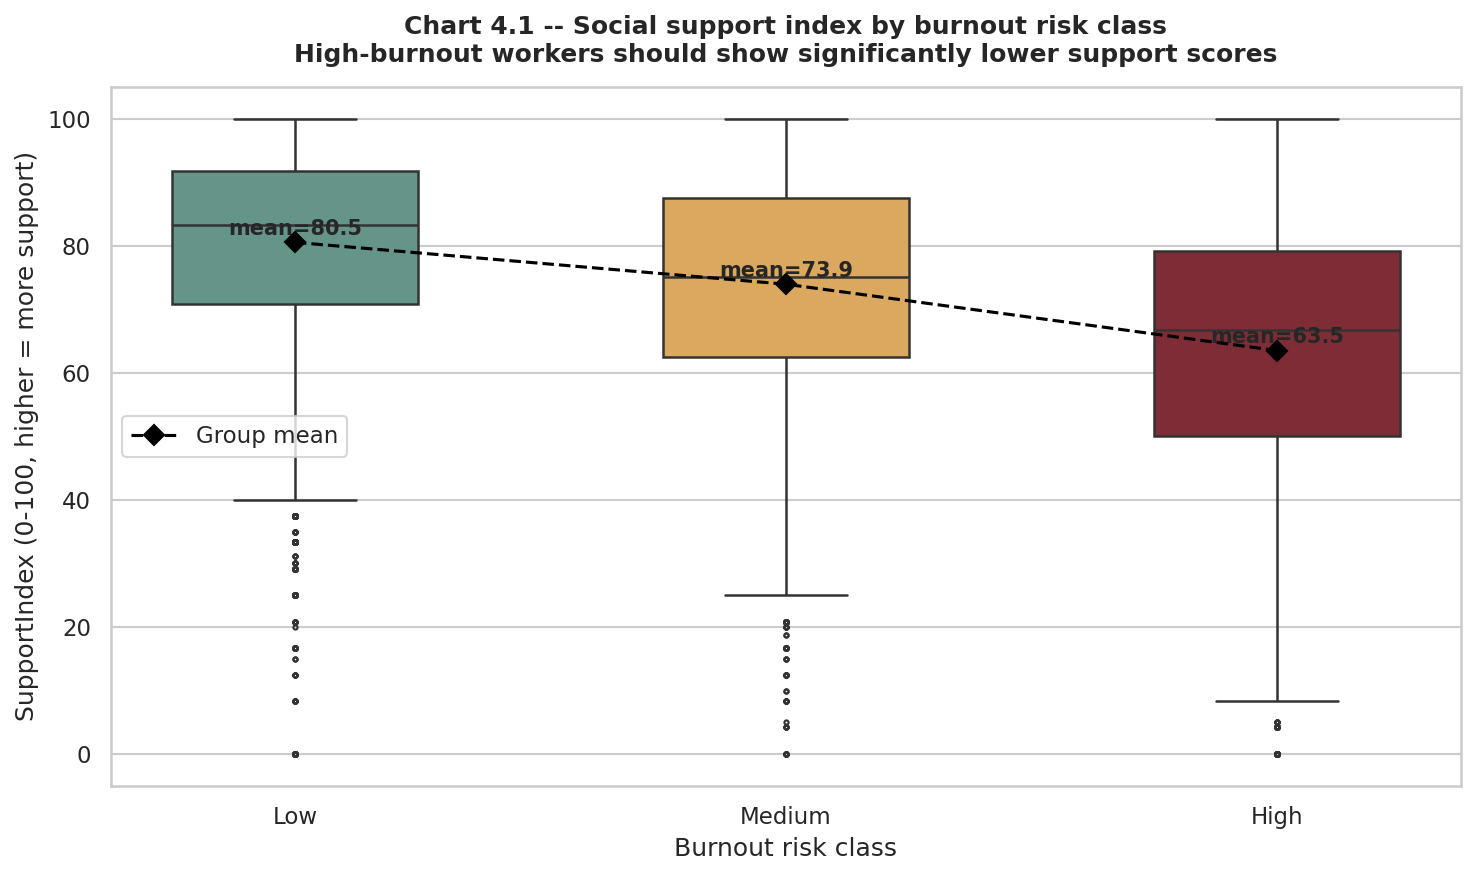

In [69]:
# Chart 4.1 -- SupportIndex by BurnoutRisk boxplot with mean overlay
if 'SupportIndex' in df.columns:
    plot_df = df[['BurnoutRisk','SupportIndex']].copy()
    plot_df['SupportIndex'] = pd.to_numeric(plot_df['SupportIndex'], errors='coerce')
    plot_df = plot_df.dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=plot_df, x='BurnoutRisk', y='SupportIndex', order=ORDER,
                palette=PALETTE, width=0.5, fliersize=2, linewidth=1.2, ax=ax)

    means_s = plot_df.groupby('BurnoutRisk', observed=True)['SupportIndex'].mean().reindex(ORDER)
    ax.plot(np.arange(len(ORDER)), means_s.values, 'D--', color='black',
            markersize=7, linewidth=1.5, label='Group mean', zorder=5)
    for x_pos, (risk, m) in enumerate(means_s.items()):
        ax.text(x_pos, m+1.2, f'mean={m:.1f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Burnout risk class')
    ax.set_ylabel('SupportIndex (0-100, higher = more support)')
    ax.set_title('Chart 4.1 -- Social support index by burnout risk class\n'
                 'High-burnout workers should show significantly lower support scores', pad=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig('chart_4_1_support_by_burnout.png', bbox_inches='tight')
    plt.show()


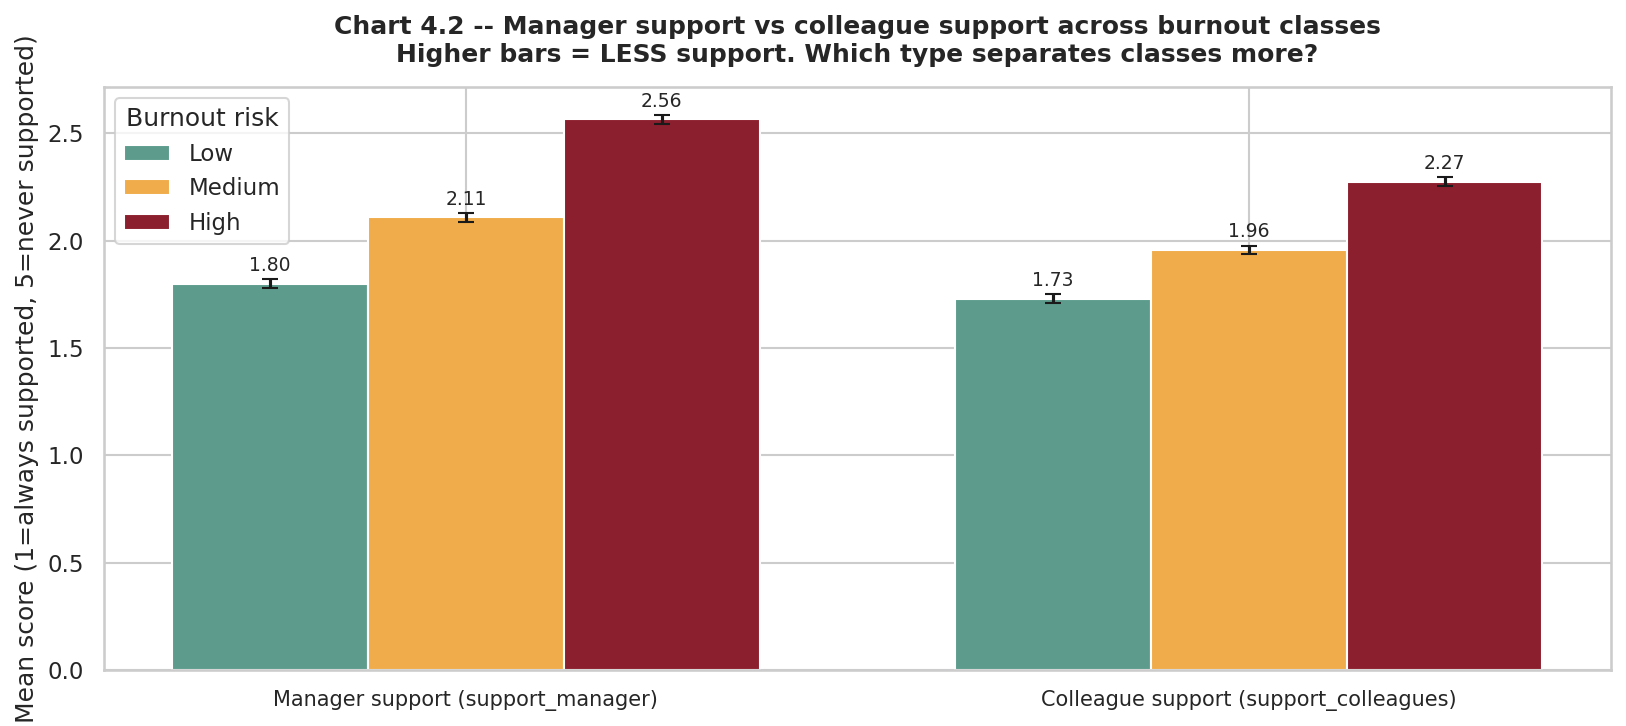

In [70]:
# Chart 4.2 -- Manager support vs colleague support: which matters more?
support_pair = {
    'Manager support (support_manager)':       'support_manager',
    'Colleague support (support_colleagues)':  'support_colleagues',
}
valid_sup = {k: v for k, v in support_pair.items() if v in df.columns}

if valid_sup:
    results = []
    for label, col in valid_sup.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            if len(sub) > 0:
                results.append({'type': label, 'risk': risk, 'mean': sub.mean(), 'sem': sub.sem()})

    res_df = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(valid_sup))
    w = 0.25
    for i, risk in enumerate(ORDER):
        sub = res_df[res_df['risk']==risk]
        bars = ax.bar(x + (i-1)*w, sub['mean'].values, w, label=risk,
                      color=PALETTE[risk], edgecolor='white',
                      yerr=sub['sem'].values*1.96, capsize=4)
        for bar, val in zip(bars, sub['mean'].values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(list(valid_sup.keys()), fontsize=10)
    ax.set_ylabel('Mean score (1=always supported, 5=never supported)')
    ax.set_title('Chart 4.2 -- Manager support vs colleague support across burnout classes\n'
                 'Higher bars = LESS support. Which type separates classes more?', pad=12)
    ax.legend(title='Burnout risk')
    plt.tight_layout()
    plt.savefig('chart_4_2_manager_vs_colleague.png', bbox_inches='tight')
    plt.show()


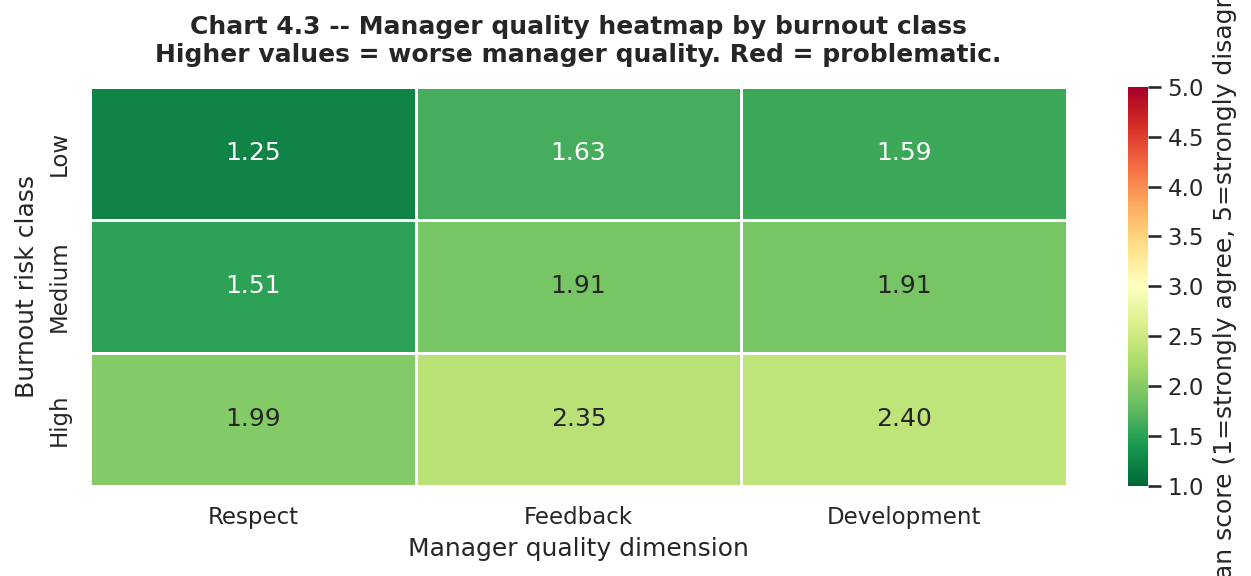

In [71]:
# Chart 4.3 -- Manager quality heatmap
boss_items = {'boss_respect': 'Respect', 'boss_feedback': 'Feedback', 'boss_development': 'Development'}
valid_boss = {k: v for k, v in boss_items.items() if k in df.columns}

if valid_boss and 'BurnoutRisk' in df.columns:
    heat = pd.DataFrame(index=ORDER, columns=list(valid_boss.values()), dtype=float)
    for col, label in valid_boss.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            heat.loc[risk, label] = sub.mean() if len(sub) > 0 else np.nan

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(heat.astype(float), annot=True, fmt='.2f', cmap='RdYlGn_r',
                linewidths=0.5, linecolor='white', ax=ax,
                cbar_kws={'label': 'Mean score (1=strongly agree, 5=strongly disagree)'},
                vmin=1, vmax=5)
    ax.set_title('Chart 4.3 -- Manager quality heatmap by burnout class\n'
                 'Higher values = worse manager quality. Red = problematic.', pad=12)
    ax.set_xlabel('Manager quality dimension')
    ax.set_ylabel('Burnout risk class')
    plt.tight_layout()
    plt.savefig('chart_4_3_manager_heatmap.png', bbox_inches='tight')
    plt.show()


---
## Section 5 -- Work-Life Conflict and Stress as a Burnout Cause

**Theme:** HEALTH / STRESS | **JD-R role:** Demand  
Key columns: `WorkLifeConflictIndex`, `wlb_tired`, `wlb_worry`, `wlb_timefamily`, `stress`, `contact_out_wh`, `freetime_work`


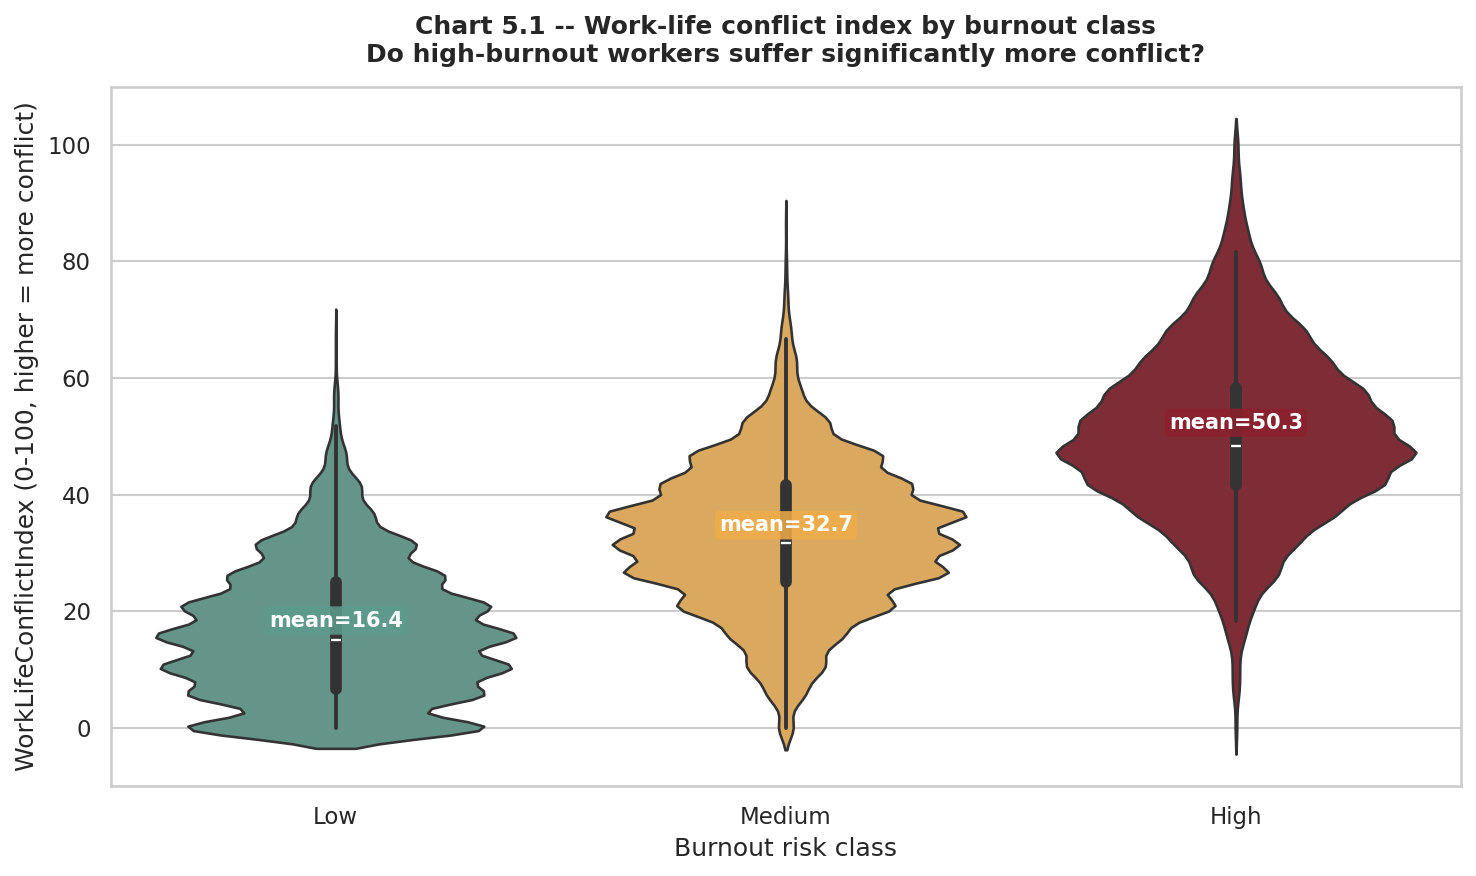

In [72]:
# Chart 5.1 -- WorkLifeConflictIndex by BurnoutRisk (violin)
if 'WorkLifeConflictIndex' in df.columns:
    plot_df = df[['BurnoutRisk','WorkLifeConflictIndex']].copy()
    plot_df['WorkLifeConflictIndex'] = pd.to_numeric(plot_df['WorkLifeConflictIndex'], errors='coerce')
    plot_df = plot_df.dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=plot_df, x='BurnoutRisk', y='WorkLifeConflictIndex', order=ORDER,
                   palette=PALETTE, inner='box', ax=ax)
    means_wlb = plot_df.groupby('BurnoutRisk', observed=True)['WorkLifeConflictIndex'].mean().reindex(ORDER)
    for i, (risk, m) in enumerate(means_wlb.items()):
        ax.text(i, m+1, f'mean={m:.1f}', ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=PALETTE[risk], alpha=0.85, edgecolor='none'),
                color='white')
    ax.set_xlabel('Burnout risk class')
    ax.set_ylabel('WorkLifeConflictIndex (0-100, higher = more conflict)')
    ax.set_title('Chart 5.1 -- Work-life conflict index by burnout class\n'
                 'Do high-burnout workers suffer significantly more conflict?', pad=12)
    plt.tight_layout()
    plt.savefig('chart_5_1_wlb_conflict.png', bbox_inches='tight')
    plt.show()


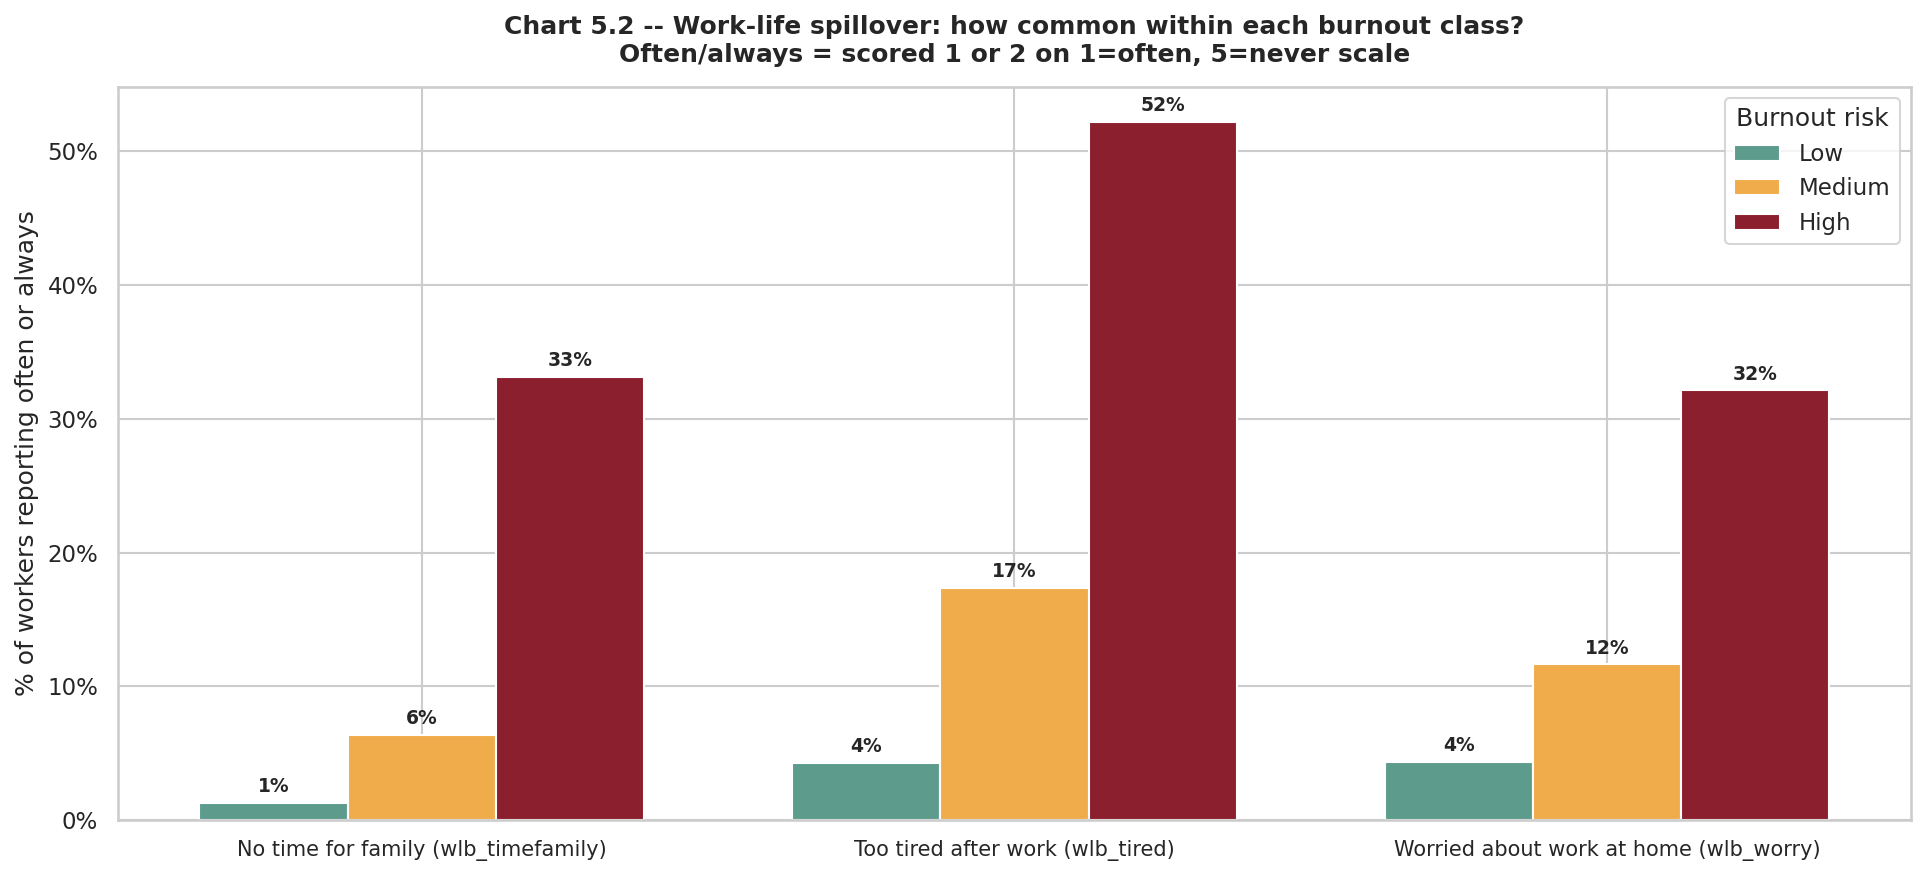

In [73]:
# Chart 5.2 -- WLB spillover items: % reported often/always per burnout class
wlb_items = {
    'Too tired after work (wlb_tired)':      'wlb_tired',
    'Worried about work at home (wlb_worry)':'wlb_worry',
    'No time for family (wlb_timefamily)':   'wlb_timefamily',
}
valid_wlb = {k: v for k, v in wlb_items.items() if v in df.columns}

if valid_wlb and 'BurnoutRisk' in df.columns:
    results = []
    for label, col in valid_wlb.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            if len(sub) > 0:
                pct = (sub <= 2).mean() * 100
                results.append({'item': label, 'risk': risk, 'pct': pct})

    res_df = pd.DataFrame(results)
    pivot  = res_df.pivot(index='item', columns='risk', values='pct').reindex(columns=ORDER)

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(pivot))
    w = 0.25
    for i, risk in enumerate(ORDER):
        bars = ax.bar(x + (i-1)*w, pivot[risk], w, label=risk,
                      color=PALETTE[risk], edgecolor='white')
        for bar, val in zip(bars, pivot[risk]):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=10)
    ax.set_ylabel('% of workers reporting often or always')
    ax.set_title('Chart 5.2 -- Work-life spillover: how common within each burnout class?\n'
                 'Often/always = scored 1 or 2 on 1=often, 5=never scale', pad=12)
    ax.legend(title='Burnout risk')
    ax.yaxis.set_major_formatter(pct_fmt)
    plt.tight_layout()
    plt.savefig('chart_5_2_wlb_spillover.png', bbox_inches='tight')
    plt.show()


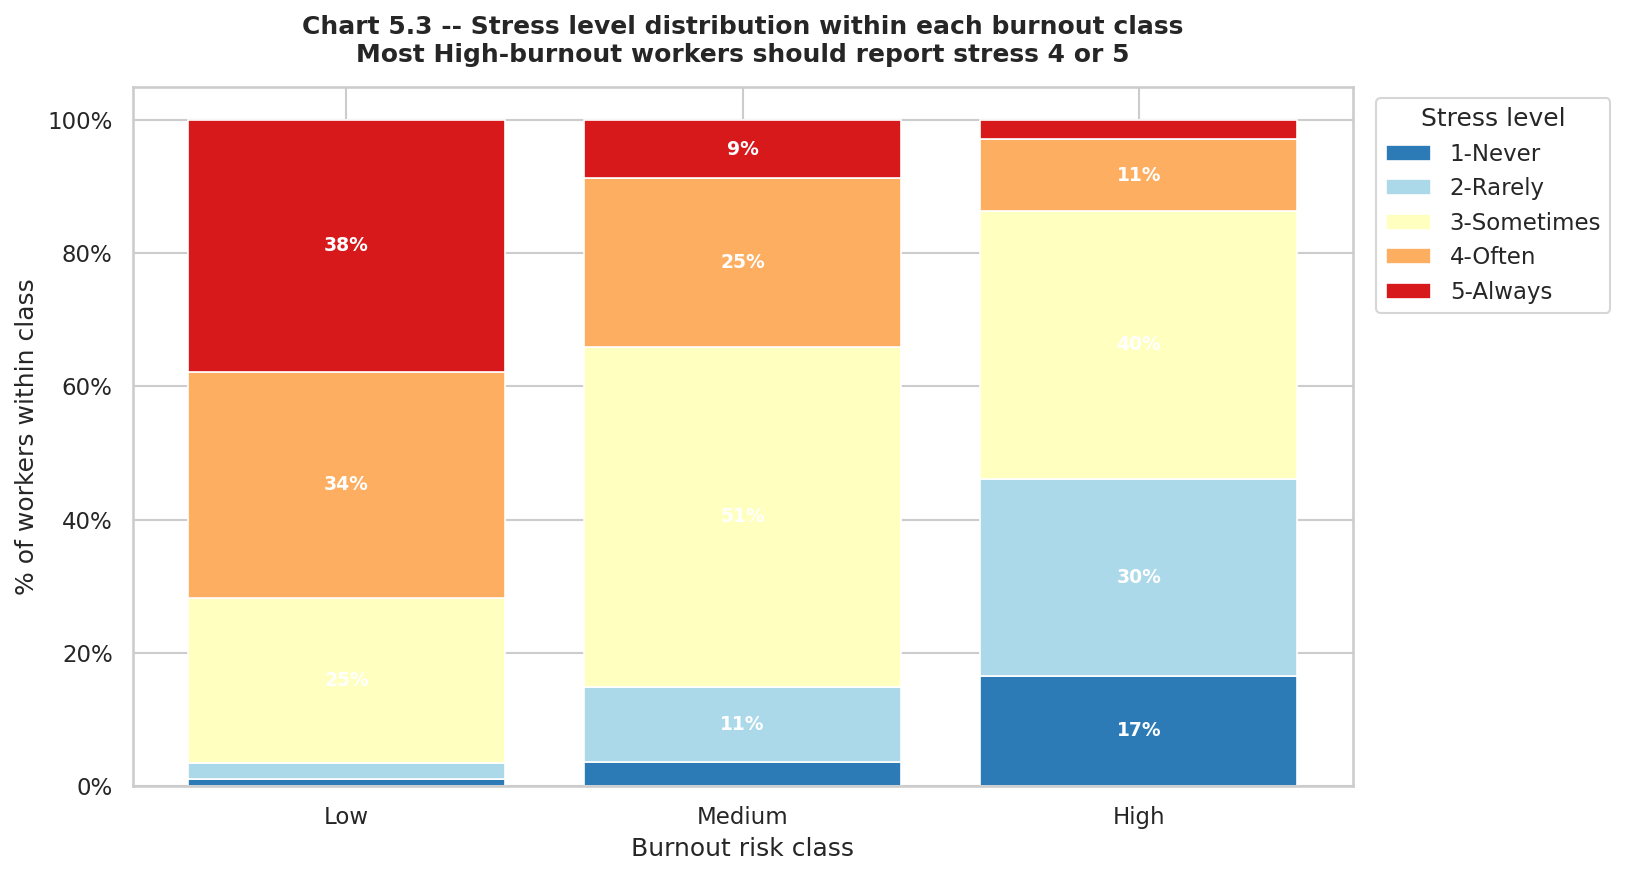

In [74]:
# Chart 5.3 -- Stress level (1-5) distribution by burnout class (stacked bar)
if 'stress' in df.columns and 'BurnoutRisk' in df.columns:
    plot_df = pd.DataFrame({
        'BurnoutRisk': df['BurnoutRisk'],
        'stress': pd.to_numeric(df['stress'], errors='coerce')
    }).dropna()
    plot_df['stress'] = plot_df['stress'].astype(int)

    crosstab = pd.crosstab(plot_df['BurnoutRisk'], plot_df['stress'],
                            normalize='index').reindex(ORDER) * 100

    stress_colors = {1:'#2c7bb6',2:'#abd9e9',3:'#ffffbf',4:'#fdae61',5:'#d7191c'}
    stress_labels = {1:'1-Never',2:'2-Rarely',3:'3-Sometimes',4:'4-Often',5:'5-Always'}

    fig, ax = plt.subplots(figsize=(11, 6))
    bottom = np.zeros(len(ORDER))
    for stress_val in sorted(crosstab.columns):
        vals = crosstab[stress_val].values
        ax.bar(ORDER, vals, bottom=bottom,
               color=stress_colors.get(stress_val, GREY),
               label=stress_labels.get(stress_val, str(stress_val)),
               edgecolor='white', linewidth=0.8)
        for j, (val, bot) in enumerate(zip(vals, bottom)):
            if val > 5:
                ax.text(j, bot+val/2, f'{val:.0f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        bottom += vals

    ax.set_xlabel('Burnout risk class')
    ax.set_ylabel('% of workers within class')
    ax.set_title('Chart 5.3 -- Stress level distribution within each burnout class\n'
                 'Most High-burnout workers should report stress 4 or 5', pad=12)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.legend(title='Stress level', bbox_to_anchor=(1.01,1), loc='upper left')
    plt.tight_layout()
    plt.savefig('chart_5_3_stress_distribution.png', bbox_inches='tight')
    plt.show()


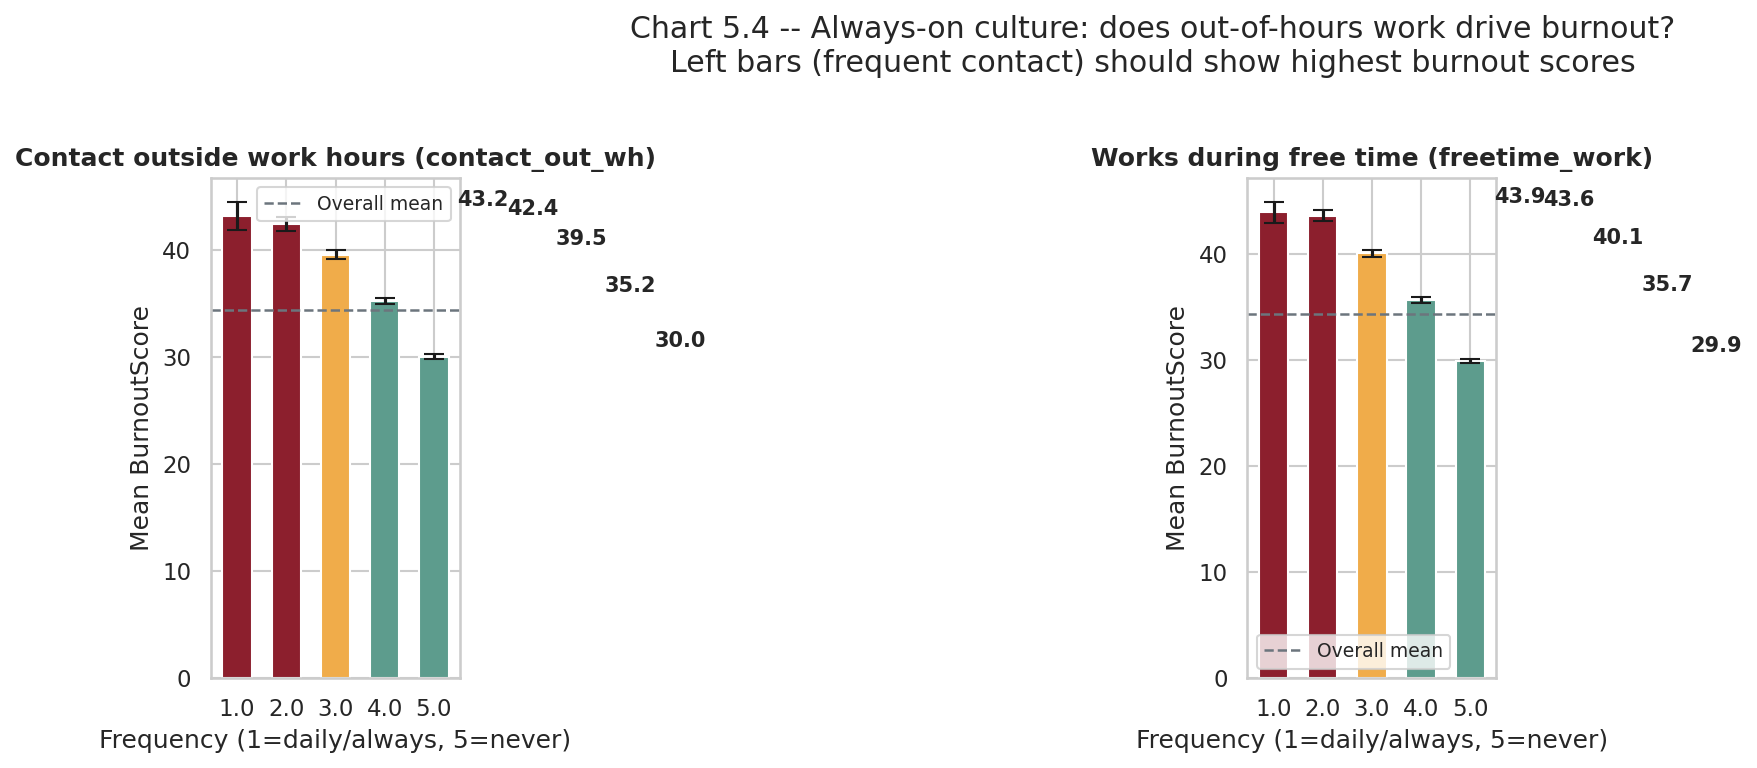

In [75]:
# Chart 5.4 -- Always-on culture: out-of-hours contact vs burnout
always_on_cols = {
    'Contact outside work hours (contact_out_wh)': 'contact_out_wh',
    'Works during free time (freetime_work)':       'freetime_work',
}
valid_always = {k: v for k, v in always_on_cols.items() if v in df.columns}

if valid_always:
    fig, axes = plt.subplots(1, len(valid_always), figsize=(7*len(valid_always), 5))
    if len(valid_always) == 1:
        axes = [axes]
    for ax, (label, col) in zip(axes, valid_always.items()):
        tmp = pd.DataFrame({'val': pd.to_numeric(df[col], errors='coerce'),
                            'bs':  to_num('BurnoutScore')}).dropna()
        grp = tmp.groupby('val')['bs'].agg(['mean','sem','count']).reset_index()
        c_list = [RED if v <= 2 else (ACCENT if v == 3 else TEAL) for v in grp['val']]
        ax.bar(grp['val'].astype(str), grp['mean'], color=c_list,
               edgecolor='white', width=0.6, yerr=grp['sem']*1.96, capsize=5)
        for _, row in grp.iterrows():
            ax.text(str(int(row['val'])), row['mean']+0.5,
                    f"{row['mean']:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_title(label)
        ax.set_xlabel('Frequency (1=daily/always, 5=never)')
        ax.set_ylabel('Mean BurnoutScore')
        ax.axhline(to_num('BurnoutScore').mean(), color=GREY, linestyle='--',
                   linewidth=1.2, label='Overall mean')
        ax.legend(fontsize=9)
    fig.suptitle('Chart 5.4 -- Always-on culture: does out-of-hours work drive burnout?\n'
                 'Left bars (frequent contact) should show highest burnout scores', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_5_4_always_on.png', bbox_inches='tight')
    plt.show()


---
## Section 6 -- Health and Engagement Consequences of Burnout

This section shows what burnout **leads to**: downstream health, engagement, and turnover outcomes.


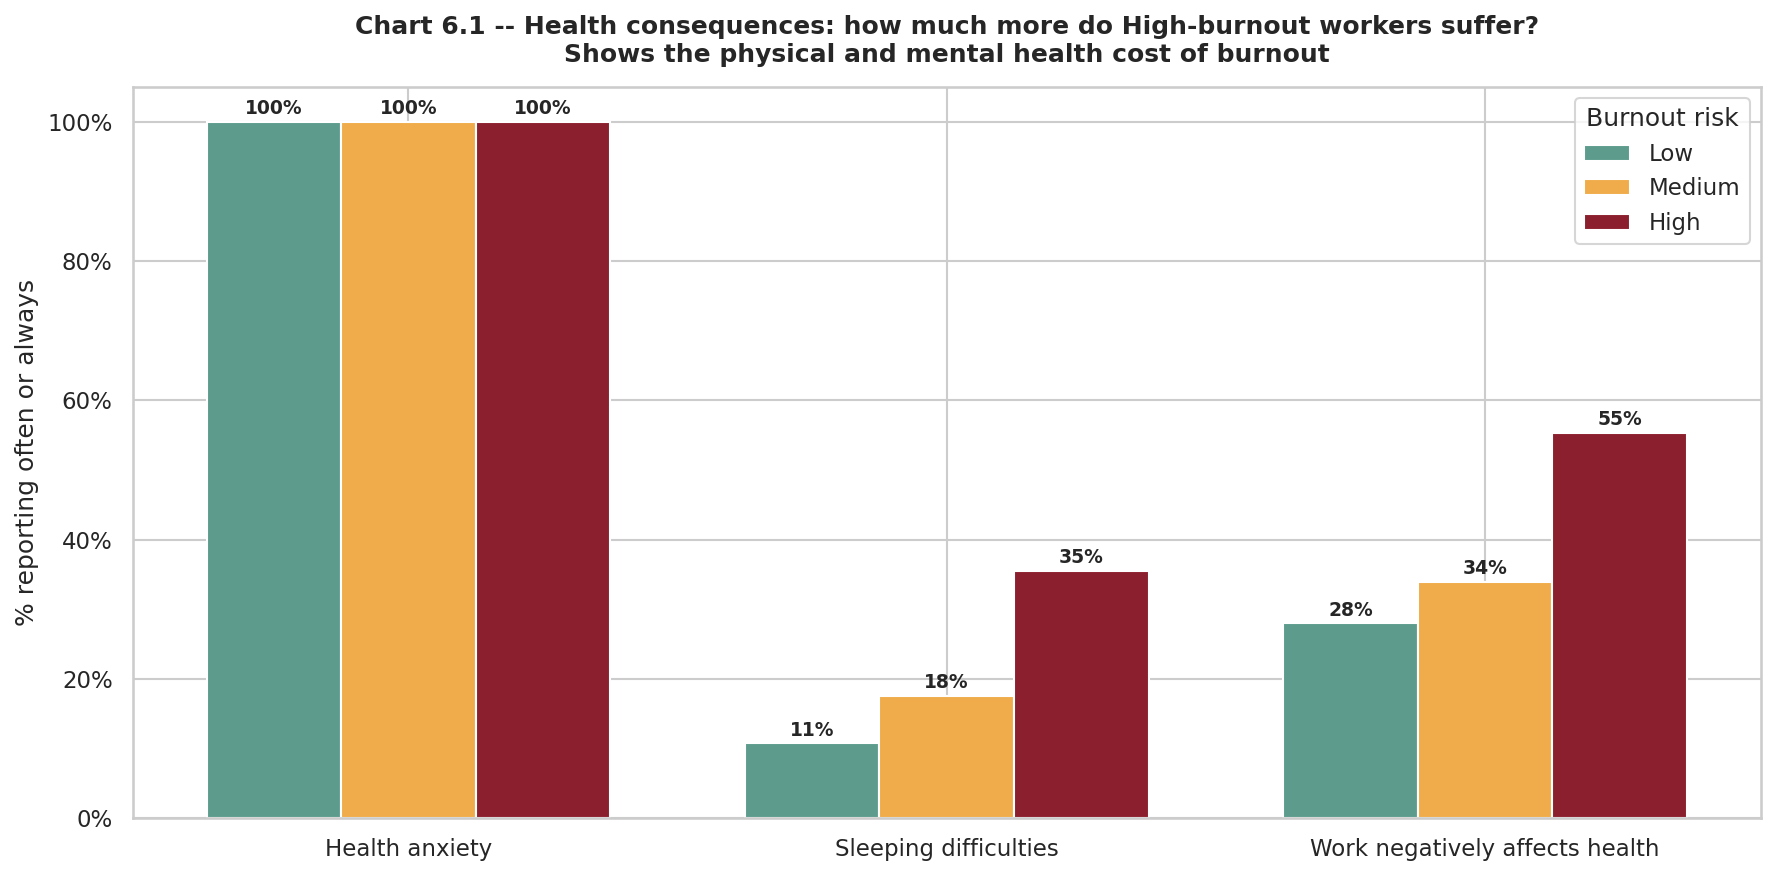

In [76]:
# Chart 6.1 -- Health consequences by burnout class
health_items = {
    'Sleeping difficulties':              'sleeping_difficulties',
    'Health anxiety':                     'health_anxiety',
    'Work negatively affects health':     'work_affect_health',
}
valid_health = {k: v for k, v in health_items.items() if v in df.columns}

if valid_health and 'BurnoutRisk' in df.columns:
    results = []
    for label, col in valid_health.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            if len(sub) > 0:
                pct = (sub <= 2).mean() * 100
                results.append({'item': label, 'risk': risk, 'pct': pct})

    res_df = pd.DataFrame(results)
    pivot  = res_df.pivot(index='item', columns='risk', values='pct').reindex(columns=ORDER)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(pivot))
    w = 0.25
    for i, risk in enumerate(ORDER):
        bars = ax.bar(x + (i-1)*w, pivot[risk], w, label=risk,
                      color=PALETTE[risk], edgecolor='white')
        for bar, val in zip(bars, pivot[risk]):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=11)
    ax.set_ylabel('% reporting often or always')
    ax.set_title('Chart 6.1 -- Health consequences: how much more do High-burnout workers suffer?\n'
                 'Shows the physical and mental health cost of burnout', pad=12)
    ax.legend(title='Burnout risk')
    ax.yaxis.set_major_formatter(pct_fmt)
    plt.tight_layout()
    plt.savefig('chart_6_1_health_consequences.png', bbox_inches='tight')
    plt.show()
else:
    print('Health consequence columns not found -- skipping chart 6.1')


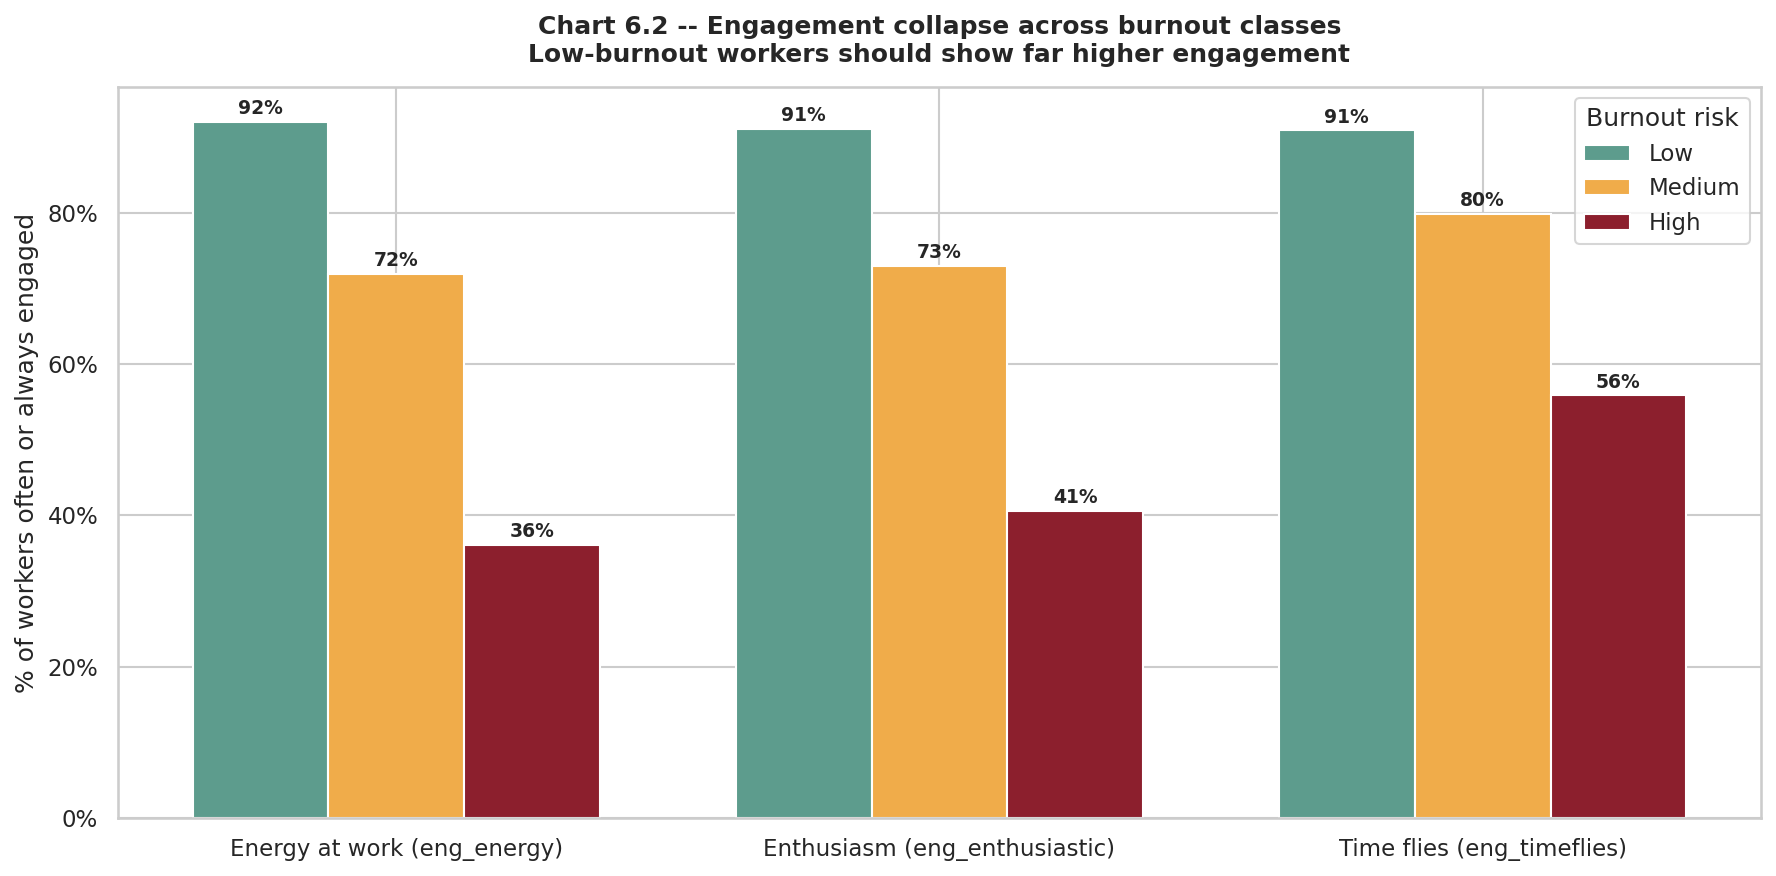

In [77]:
# Chart 6.2 -- Engagement collapse across burnout classes
engage_items = {
    'Energy at work (eng_energy)':       'eng_energy',
    'Enthusiasm (eng_enthusiastic)':     'eng_enthusiastic',
    'Time flies (eng_timeflies)':        'eng_timeflies',
}
valid_eng = {k: v for k, v in engage_items.items() if v in df.columns}

if valid_eng and 'BurnoutRisk' in df.columns:
    results = []
    for label, col in valid_eng.items():
        for risk in ORDER:
            sub = pd.to_numeric(df[df['BurnoutRisk']==risk][col], errors='coerce').dropna()
            if len(sub) > 0:
                pct_engaged = (sub <= 2).mean() * 100  # 1=always engaged, 2=often
                results.append({'item': label, 'risk': risk, 'pct': pct_engaged})

    res_df = pd.DataFrame(results)
    pivot  = res_df.pivot(index='item', columns='risk', values='pct').reindex(columns=ORDER)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(pivot))
    w = 0.25
    for i, risk in enumerate(ORDER):
        bars = ax.bar(x + (i-1)*w, pivot[risk], w, label=risk,
                      color=PALETTE[risk], edgecolor='white')
        for bar, val in zip(bars, pivot[risk]):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=11)
    ax.set_ylabel('% of workers often or always engaged')
    ax.set_title('Chart 6.2 -- Engagement collapse across burnout classes\n'
                 'Low-burnout workers should show far higher engagement', pad=12)
    ax.legend(title='Burnout risk')
    ax.yaxis.set_major_formatter(pct_fmt)
    plt.tight_layout()
    plt.savefig('chart_6_2_engagement_burnout.png', bbox_inches='tight')
    plt.show()


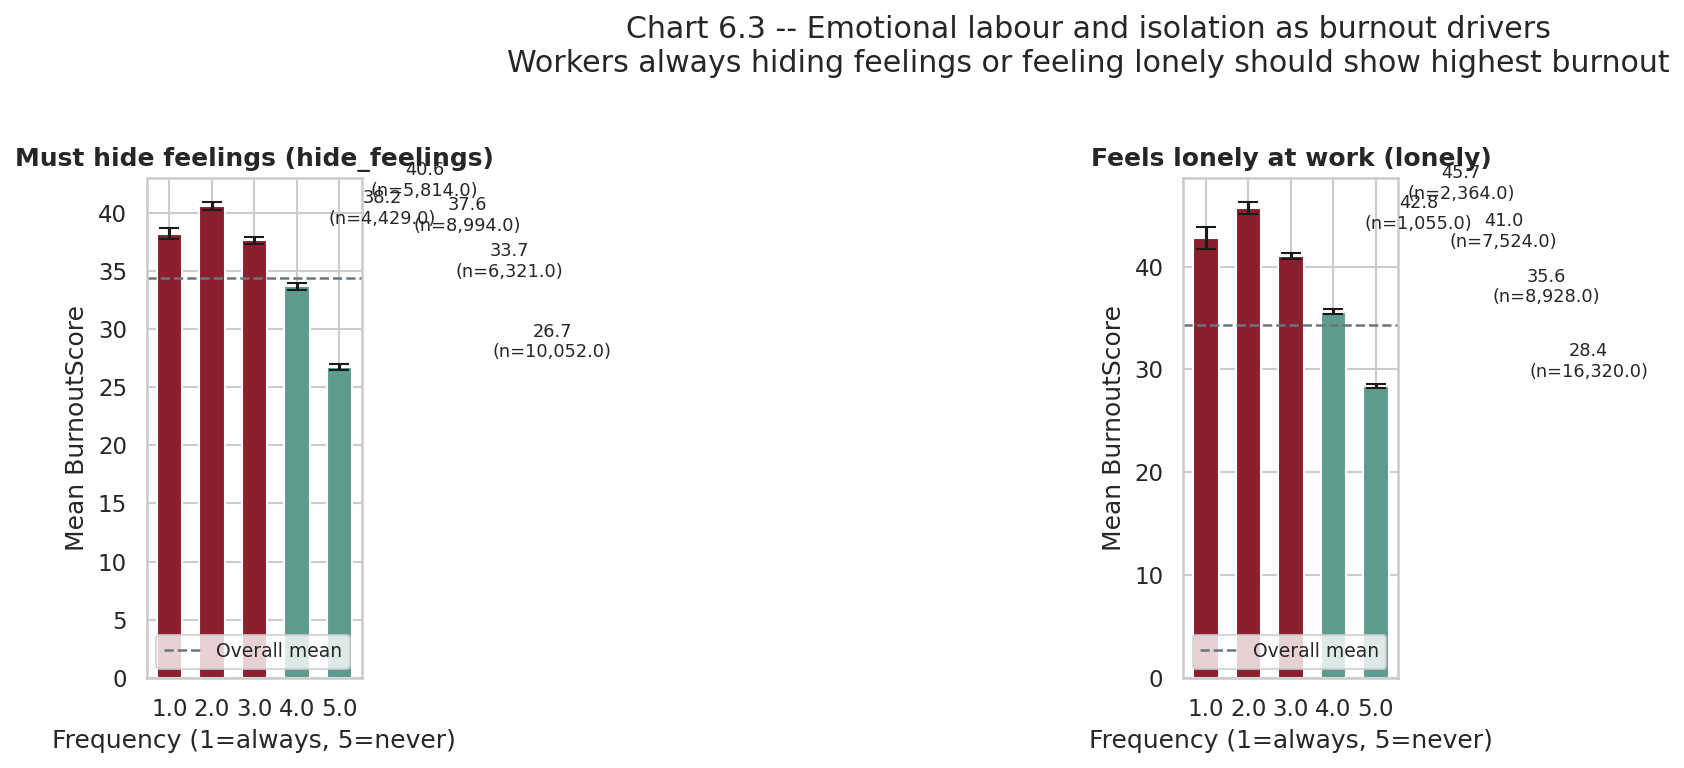

In [78]:
# Chart 6.3 -- Emotional labour and isolation vs burnout
emo_cols = {
    'Must hide feelings (hide_feelings)': 'hide_feelings',
    'Feels lonely at work (lonely)':      'lonely',
}
valid_emo = {k: v for k, v in emo_cols.items() if v in df.columns}

if valid_emo:
    fig, axes = plt.subplots(1, len(valid_emo), figsize=(7*len(valid_emo), 5))
    if len(valid_emo) == 1:
        axes = [axes]
    for ax, (label, col) in zip(axes, valid_emo.items()):
        tmp = pd.DataFrame({'val': pd.to_numeric(df[col], errors='coerce'),
                            'bs':  to_num('BurnoutScore')}).dropna()
        grp = tmp.groupby('val')['bs'].agg(['mean','sem','count']).reset_index()
        med_v2 = grp['val'].median()
        c_list2 = [RED if v <= med_v2 else TEAL for v in grp['val']]
        ax.bar(grp['val'].astype(str), grp['mean'], color=c_list2,
               edgecolor='white', width=0.6, yerr=grp['sem']*1.96, capsize=5)
        for _, row in grp.iterrows():
            ax.text(str(int(row['val'])), row['mean']+0.5,
                    f"{row['mean']:.1f}\n(n={row['count']:,})",
                    ha='center', va='bottom', fontsize=8.5)
        ax.set_title(label)
        ax.set_xlabel('Frequency (1=always, 5=never)')
        ax.set_ylabel('Mean BurnoutScore')
        ax.axhline(to_num('BurnoutScore').mean(), color=GREY, linestyle='--',
                   linewidth=1.2, label='Overall mean')
        ax.legend(fontsize=9)
    fig.suptitle('Chart 6.3 -- Emotional labour and isolation as burnout drivers\n'
                 'Workers always hiding feelings or feeling lonely should show highest burnout', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_6_3_emotional_labour.png', bbox_inches='tight')
    plt.show()
else:
    print('Emotional labour columns not found -- skipping chart 6.3')


quit_job unique codes found: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


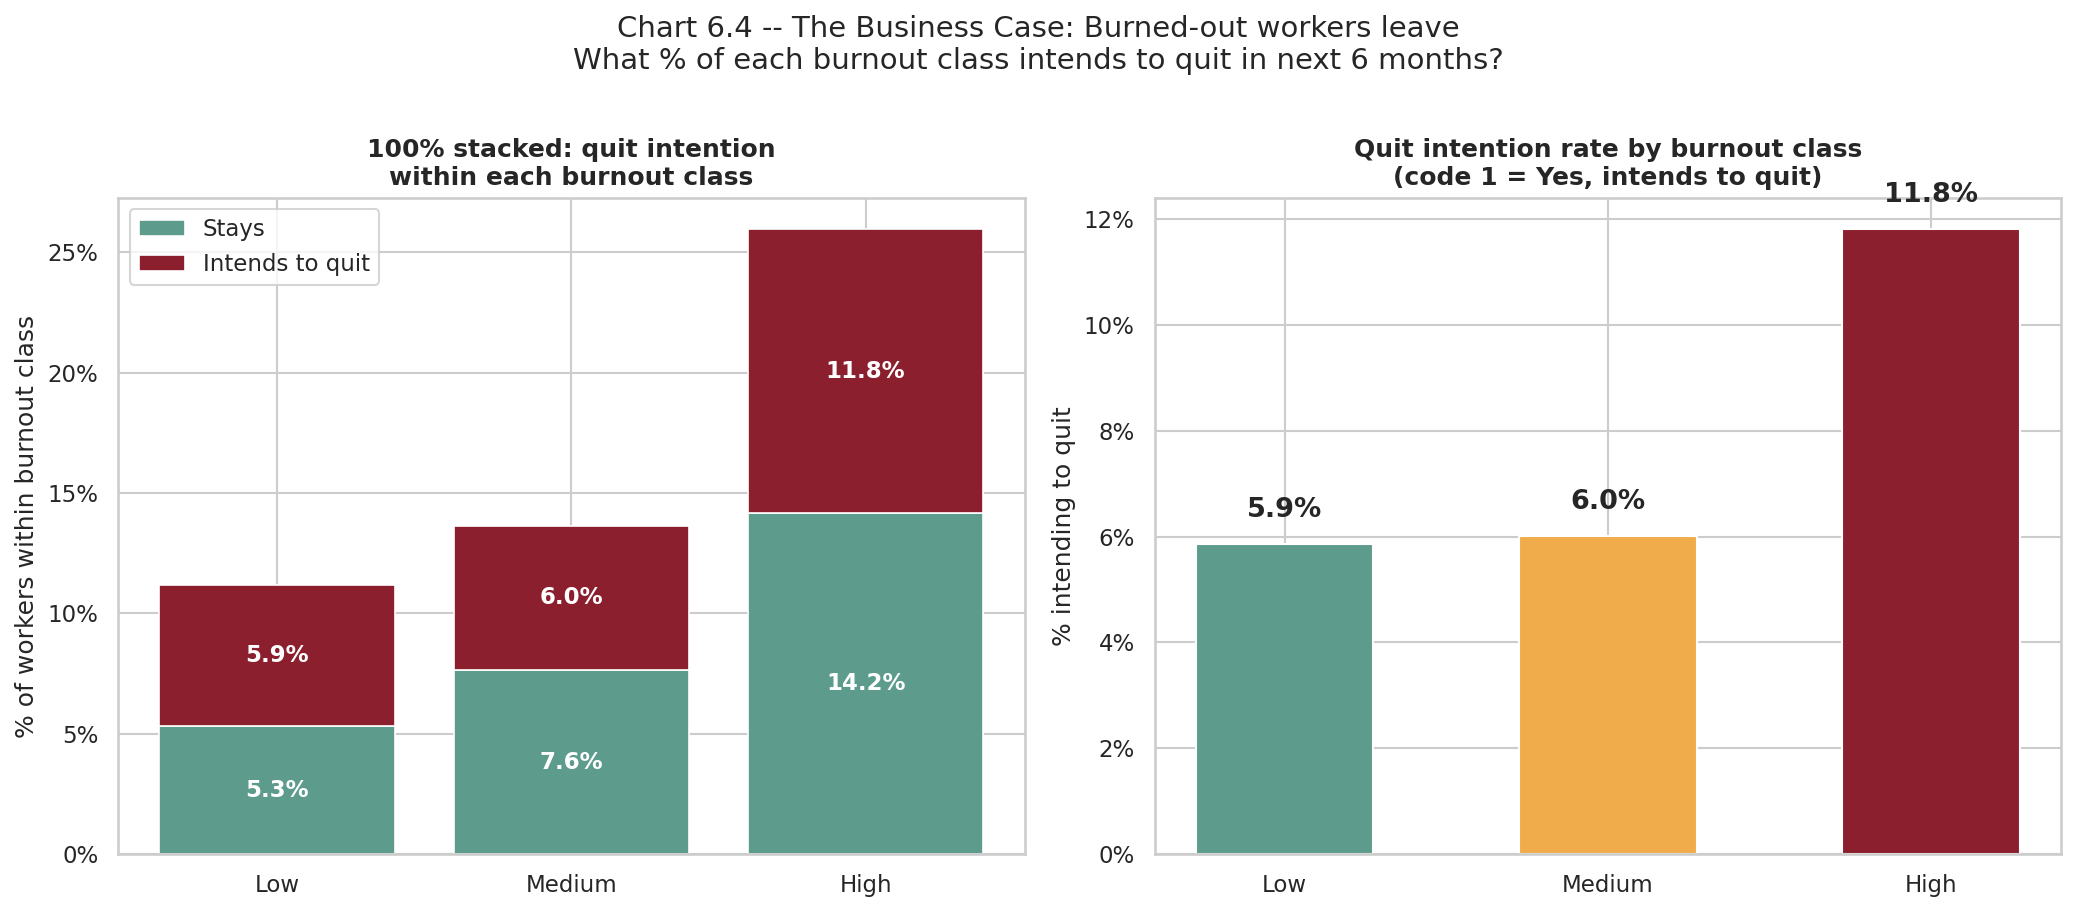

In [79]:
# Chart 6.4 -- THE BUSINESS CASE: Quit intention by burnout class
# quit_job in EWCS 2024: 1 = Yes (intends to quit), 2 = No (stays)
# We hardcode QUIT_CODE = 1 and STAY_CODE = 2 explicitly so the labels
# cannot silently swap if the column ordering in crosstab changes.

QUIT_CODE = 1
STAY_CODE = 2

if 'quit_job' in df.columns and 'BurnoutRisk' in df.columns:
    plot_df = pd.DataFrame({
        'BurnoutRisk': df['BurnoutRisk'],
        'quit_job':    pd.to_numeric(df['quit_job'], errors='coerce')
    }).dropna()

    # Verify the expected codes actually exist before plotting
    found_codes = plot_df['quit_job'].unique()
    print(f'quit_job unique codes found: {sorted(found_codes)}')
    if QUIT_CODE not in found_codes:
        print(f'WARNING: quit code {QUIT_CODE} not found. Check coding. Unique values: {found_codes}')

    crosstab = pd.crosstab(plot_df['BurnoutRisk'], plot_df['quit_job'],
                            normalize='index').reindex(ORDER) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: 100% stacked bar -- Stays (bottom) then Quits (top)
    bottom = np.zeros(len(ORDER))
    stack_order = [
        (STAY_CODE, TEAL, 'Stays'),
        (QUIT_CODE, RED,  'Intends to quit'),
    ]
    for code, color, label_str in stack_order:
        if code not in crosstab.columns:
            continue
        vals = crosstab[code].values
        axes[0].bar(ORDER, vals, bottom=bottom, color=color,
                    edgecolor='white', linewidth=0.8, label=label_str)
        for j, (val, bot) in enumerate(zip(vals, bottom)):
            if val > 5:
                axes[0].text(j, bot+val/2, f'{val:.1f}%', ha='center', va='center',
                             fontsize=11, fontweight='bold', color='white')
        bottom += vals

    axes[0].set_ylabel('% of workers within burnout class')
    axes[0].set_title('100% stacked: quit intention\nwithin each burnout class')
    axes[0].yaxis.set_major_formatter(pct_fmt)
    axes[0].legend()

    # Right: quit rate per class as a single bar
    if QUIT_CODE in crosstab.columns:
        quit_rates = crosstab[QUIT_CODE]
        bars2 = axes[1].bar(ORDER, quit_rates.values,
                            color=[PALETTE[r] for r in ORDER], edgecolor='white', width=0.55)
        for bar, val in zip(bars2, quit_rates.values):
            axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                         f'{val:.1f}%', ha='center', va='bottom',
                         fontsize=13, fontweight='bold')
        axes[1].set_ylabel('% intending to quit')
        axes[1].set_title('Quit intention rate by burnout class\n(code 1 = Yes, intends to quit)')
        axes[1].yaxis.set_major_formatter(pct_fmt)

    fig.suptitle('Chart 6.4 -- The Business Case: Burned-out workers leave\n'
                 'What % of each burnout class intends to quit in next 6 months?',
                 y=1.01, fontsize=14)
    plt.tight_layout()
    plt.savefig('chart_6_4_quit_intention.png', bbox_inches='tight')
    plt.show()
else:
    print('quit_job column not found -- skipping chart 6.4')

---
## Section 7 -- Which Reason Causes Burnout Most?

Three charts that directly answer: **what are the biggest drivers of burnout, and how do they rank?**


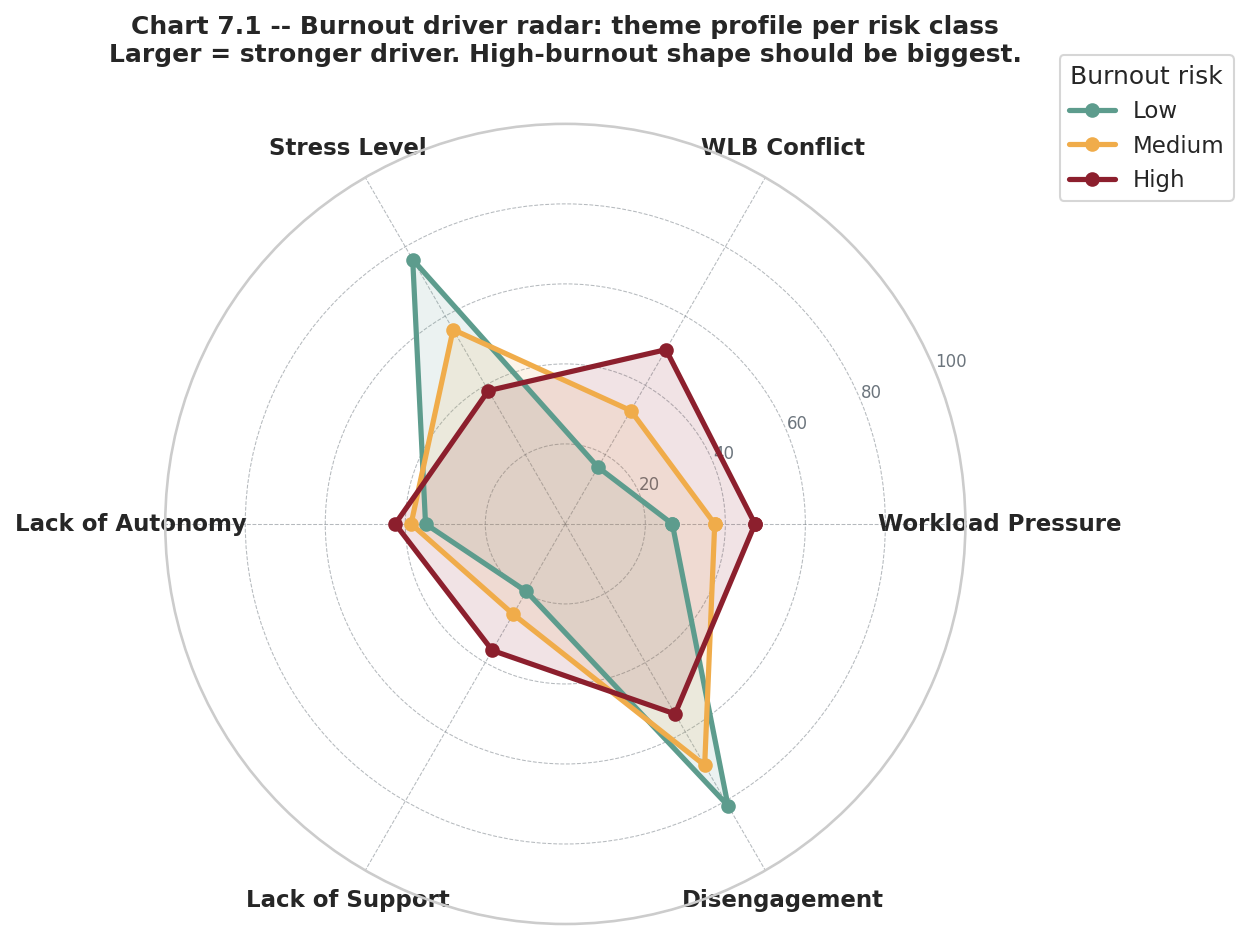

In [80]:
# Chart 7.1 -- Theme radar chart: driver profile per burnout class
theme_vars = {
    'Workload Pressure':   'WorkloadIndex',
    'WLB Conflict':        'WorkLifeConflictIndex',
    'Stress Level':        'stress',
    'Lack of Autonomy':    'autonomy_speed',
    'Lack of Support':     'SupportIndex',
    'Disengagement':       'eng_energy',
}
valid_radar = {k: v for k, v in theme_vars.items() if v in df.columns}

if len(valid_radar) >= 4 and 'BurnoutRisk' in df.columns:
    labels_r = list(valid_radar.keys())
    N = len(labels_r)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    for risk in ORDER:
        sub = df[df['BurnoutRisk']==risk]
        vals = []
        for col in valid_radar.values():
            s = pd.to_numeric(sub[col], errors='coerce').dropna()
            col_all = pd.to_numeric(df[col], errors='coerce').dropna()
            denom = col_all.max() - col_all.min()
            if denom == 0:
                vals.append(50.0)
                continue
            norm_val = (s.mean() - col_all.min()) / denom * 100
            # Invert resource variables so high = more burnout driver
            if col in ('SupportIndex', 'eng_energy'):
                norm_val = 100 - norm_val
            vals.append(norm_val)
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', linewidth=2.5, label=risk, color=PALETTE[risk])
        ax.fill(angles, vals, alpha=0.12, color=PALETTE[risk])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_r, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_yticks([20,40,60,80,100])
    ax.set_yticklabels(['20','40','60','80','100'], fontsize=8, color=GREY)
    ax.grid(color=GREY, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title('Chart 7.1 -- Burnout driver radar: theme profile per risk class\n'
                 'Larger = stronger driver. High-burnout shape should be biggest.',
                 pad=30, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1),
              title='Burnout risk', frameon=True)
    plt.tight_layout()
    plt.savefig('chart_7_1_radar_chart.png', bbox_inches='tight')
    plt.show()


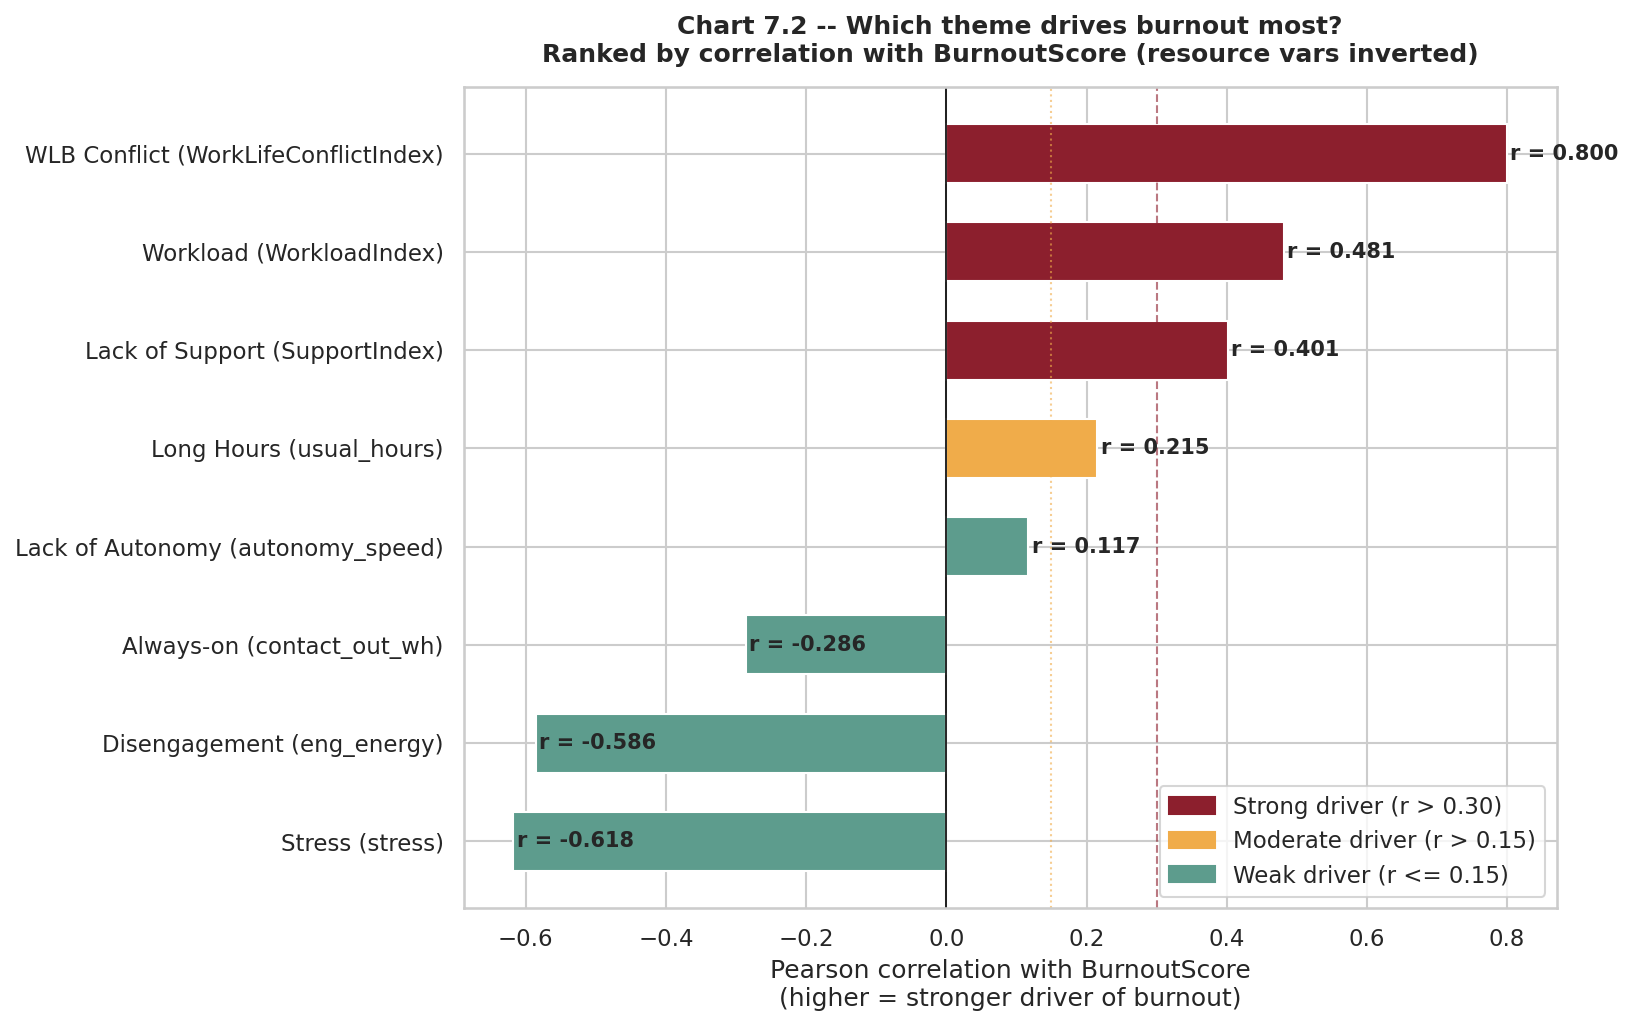

Top burnout drivers by correlation:
  WLB Conflict (WorkLifeConflictIndex)          r = 0.800
  Workload (WorkloadIndex)                      r = 0.481
  Lack of Support (SupportIndex)                r = 0.401
  Long Hours (usual_hours)                      r = 0.215
  Lack of Autonomy (autonomy_speed)             r = 0.117


In [81]:
# Chart 7.2 -- Burnout driver theme ranking (correlation with BurnoutScore)
driver_cols = {
    'Workload (WorkloadIndex)':             'WorkloadIndex',
    'WLB Conflict (WorkLifeConflictIndex)': 'WorkLifeConflictIndex',
    'Stress (stress)':                      'stress',
    'Lack of Autonomy (autonomy_speed)':    'autonomy_speed',
    'Lack of Support (SupportIndex)':       'SupportIndex',
    'Disengagement (eng_energy)':           'eng_energy',
    'Long Hours (usual_hours)':             'usual_hours',
    'Always-on (contact_out_wh)':           'contact_out_wh',
}
valid_drivers = {k: v for k, v in driver_cols.items() if v in df.columns}
bs = to_num('BurnoutScore')

corr_results = []
for label, col in valid_drivers.items():
    col_data = pd.to_numeric(df[col], errors='coerce')
    tmp = pd.DataFrame({'x': col_data, 'y': bs}).dropna()
    if len(tmp) > 50:
        r = tmp['x'].corr(tmp['y'])
        if col in ('SupportIndex', 'eng_energy', 'eng_enthusiastic'):
            r = -r  # invert resources so positive = more burnout
        corr_results.append({'label': label, 'r': r, 'n': len(tmp)})

if corr_results:
    corr_df = pd.DataFrame(corr_results).sort_values('r', ascending=True)

    fig, ax = plt.subplots(figsize=(11, 7))
    colors_c = [RED if r > 0.3 else (ACCENT if r > 0.15 else TEAL) for r in corr_df['r']]
    bars = ax.barh(corr_df['label'], corr_df['r'], color=colors_c, edgecolor='white', height=0.6)
    ax.axvline(0,    color='black', linewidth=0.8)
    ax.axvline(0.3,  color=RED,   linestyle='--', linewidth=1, alpha=0.6, label='Strong (r>0.3)')
    ax.axvline(0.15, color=ACCENT, linestyle=':', linewidth=1, alpha=0.6, label='Moderate (r>0.15)')

    for bar, (_, row) in zip(bars, corr_df.iterrows()):
        ax.text(row['r']+0.005, bar.get_y()+bar.get_height()/2,
                f'r = {row["r"]:.3f}', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Pearson correlation with BurnoutScore\n(higher = stronger driver of burnout)')
    ax.set_title('Chart 7.2 -- Which theme drives burnout most?\n'
                 'Ranked by correlation with BurnoutScore (resource vars inverted)', pad=12)

    legend_patches = [
        mpatches.Patch(color=RED,   label='Strong driver (r > 0.30)'),
        mpatches.Patch(color=ACCENT, label='Moderate driver (r > 0.15)'),
        mpatches.Patch(color=TEAL,  label='Weak driver (r <= 0.15)'),
    ]
    ax.legend(handles=legend_patches, loc='lower right', frameon=True)
    plt.tight_layout()
    plt.savefig('chart_7_2_driver_ranking.png', bbox_inches='tight')
    plt.show()

    print('Top burnout drivers by correlation:')
    for _, row in corr_df.sort_values('r', ascending=False).head(5).iterrows():
        print(f'  {row["label"]:<45} r = {row["r"]:.3f}')


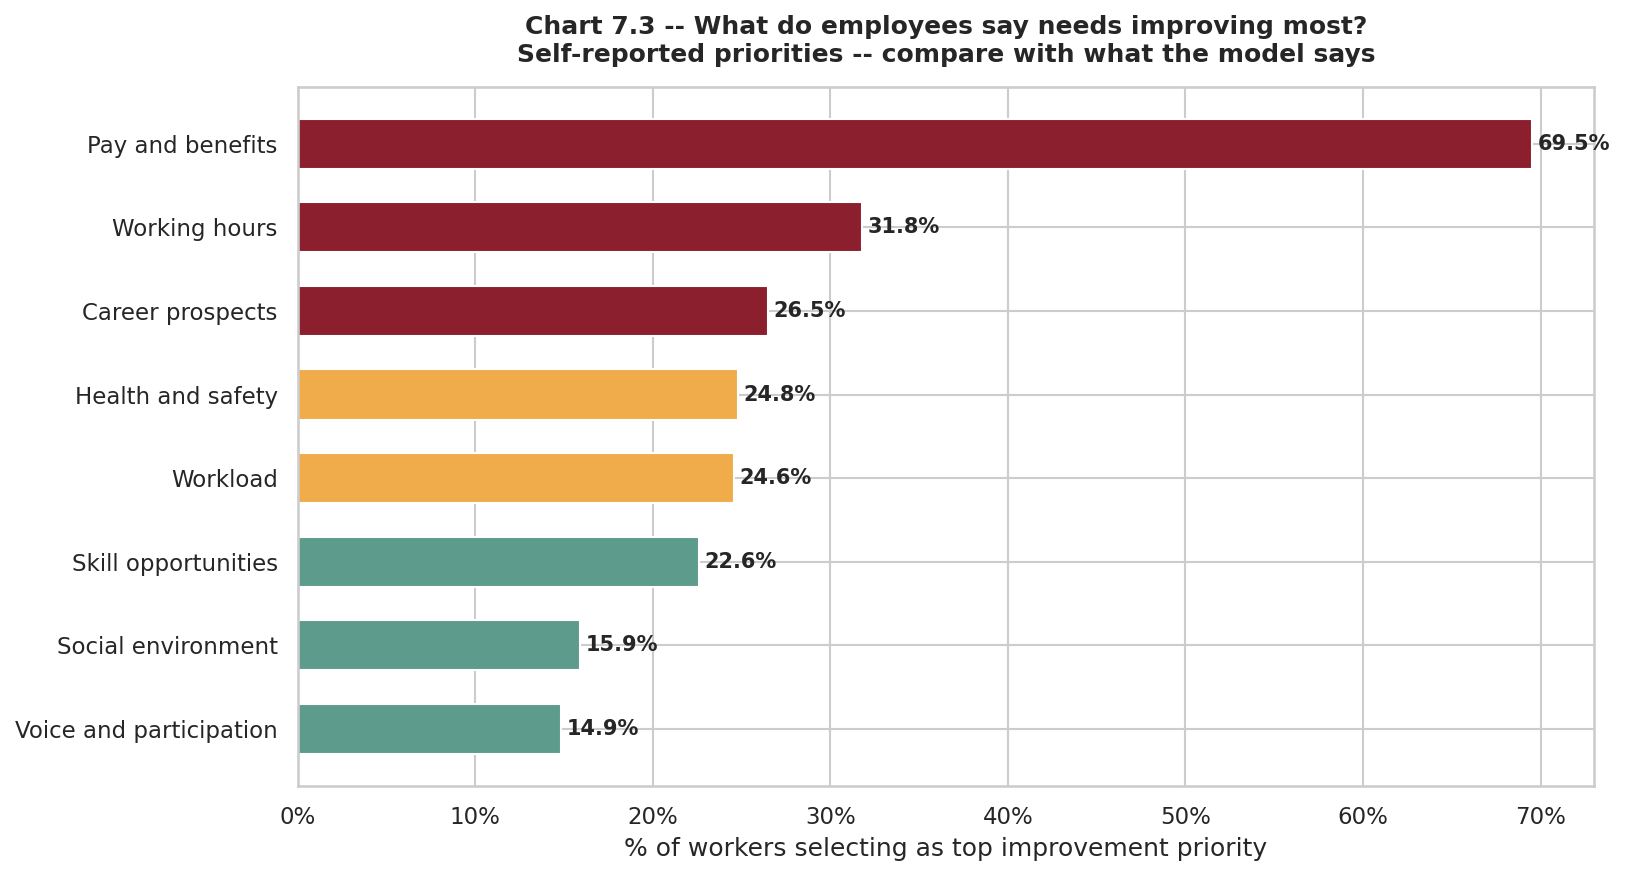

In [82]:
# Chart 7.3 -- What employees say needs improving most (INSIGHT columns)
improve_cols = {
    'Workload':            'improve_workload',
    'Working hours':       'improve_workhours',
    'Pay and benefits':    'improve_pay_benefits',
    'Career prospects':    'improve_prospects',
    'Social environment':  'improve_social',
    'Skill opportunities': 'improve_opportunities',
    'Health and safety':   'improve_health_safety',
    'Voice and participation': 'improve_voice',
}
valid_improve = {k: v for k, v in improve_cols.items() if v in df.columns}

if valid_improve:
    improve_pcts = []
    for label, col in valid_improve.items():
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if s.max() <= 1:
            pct = s.mean() * 100
        else:
            pct = (s == s.max()).mean() * 100
        improve_pcts.append({'label': label, 'pct': pct})

    imp_df = pd.DataFrame(improve_pcts).sort_values('pct', ascending=True)
    q70 = imp_df['pct'].quantile(0.7)
    q40 = imp_df['pct'].quantile(0.4)
    colors_i = [RED if p >= q70 else (ACCENT if p >= q40 else TEAL) for p in imp_df['pct']]

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(imp_df['label'], imp_df['pct'], color=colors_i,
                   edgecolor='white', height=0.6)
    for bar, val in zip(bars, imp_df['pct']):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('% of workers selecting as top improvement priority')
    ax.set_title('Chart 7.3 -- What do employees say needs improving most?\n'
                 'Self-reported priorities -- compare with what the model says', pad=12)
    ax.xaxis.set_major_formatter(pct_fmt)
    plt.tight_layout()
    plt.savefig('chart_7_3_improvement_priorities.png', bbox_inches='tight')
    plt.show()
else:
    print('Improvement columns not found -- skipping chart 7.3')


---
## Section 8 -- Who Is Most Affected? (Demographic Segmentation)

Using CONTEXT columns as segmentation lenses: sector, age, gender, country, contract type.


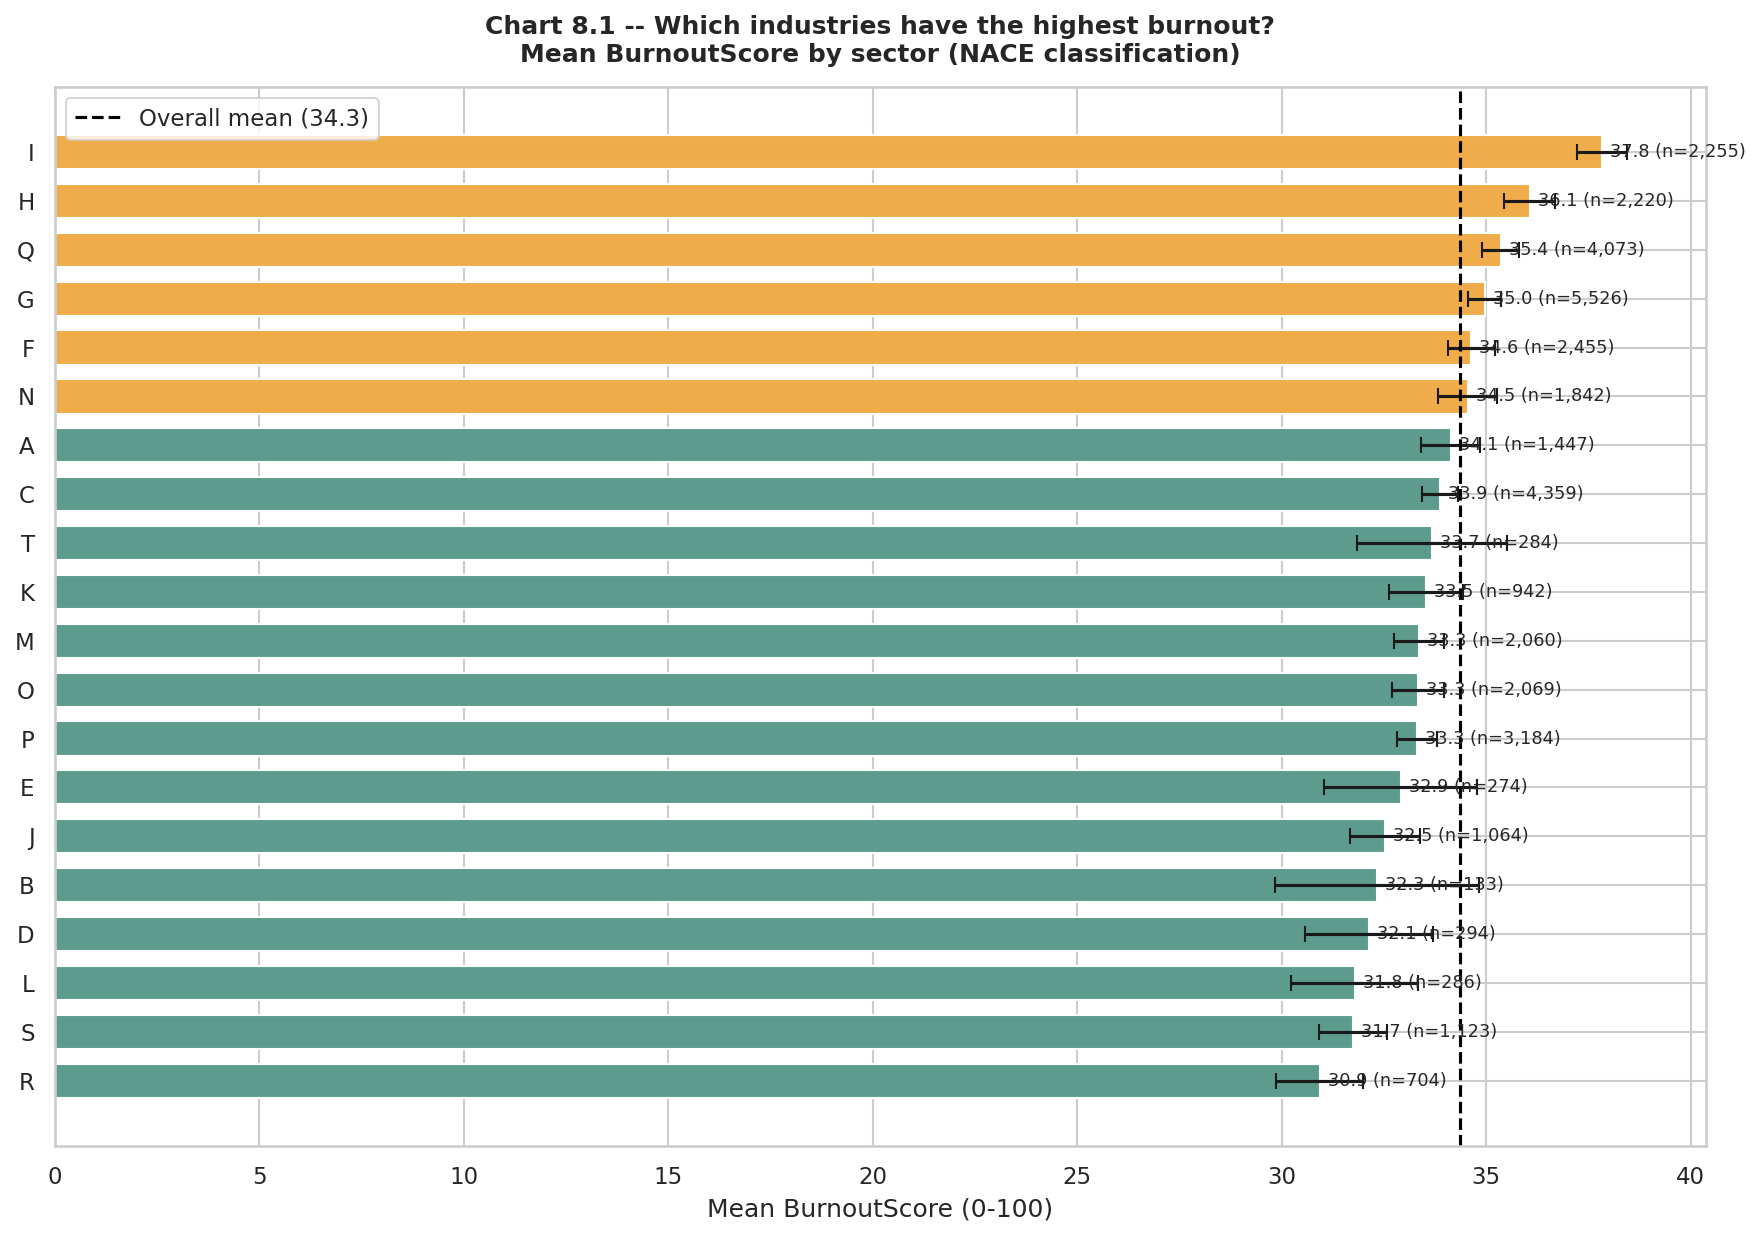

In [83]:
# Chart 8.1 -- Mean burnout score by industry sector
sector_col = next((c for c in ['NACE1','NACE_2','sector','nace1'] if c in df.columns), None)

if sector_col:
    tmp = pd.DataFrame({'sector': df[sector_col], 'bs': to_num('BurnoutScore')}).dropna()
    sect_means = tmp.groupby('sector')['bs'].agg(['mean','sem','count']).reset_index()
    sect_means.columns = ['sector','mean','sem','count']
    sect_means = sect_means[sect_means['count'] >= 100].sort_values('mean', ascending=True)
    n_show = min(20, len(sect_means))
    plot_data = sect_means.tail(n_show)
    overall_mean = tmp['bs'].mean()

    fig, ax = plt.subplots(figsize=(12, max(6, n_show*0.42)))
    bar_colors = [RED if m > overall_mean+5 else (ACCENT if m > overall_mean else TEAL)
                  for m in plot_data['mean']]
    ax.barh(plot_data['sector'].astype(str), plot_data['mean'],
            color=bar_colors, edgecolor='white', height=0.7,
            xerr=plot_data['sem']*1.96, capsize=4)
    ax.axvline(overall_mean, color='black', linestyle='--', linewidth=1.5,
               label=f'Overall mean ({overall_mean:.1f})')
    for i, (_, row) in enumerate(plot_data.iterrows()):
        ax.text(row['mean']+0.2, i, f"{row['mean']:.1f} (n={row['count']:,})",
                va='center', fontsize=8.5)
    ax.set_xlabel('Mean BurnoutScore (0-100)')
    ax.set_title('Chart 8.1 -- Which industries have the highest burnout?\n'
                 'Mean BurnoutScore by sector (NACE classification)', pad=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig('chart_8_1_burnout_by_sector.png', bbox_inches='tight')
    plt.show()
else:
    print('Sector column not found -- skipping chart 8.1')


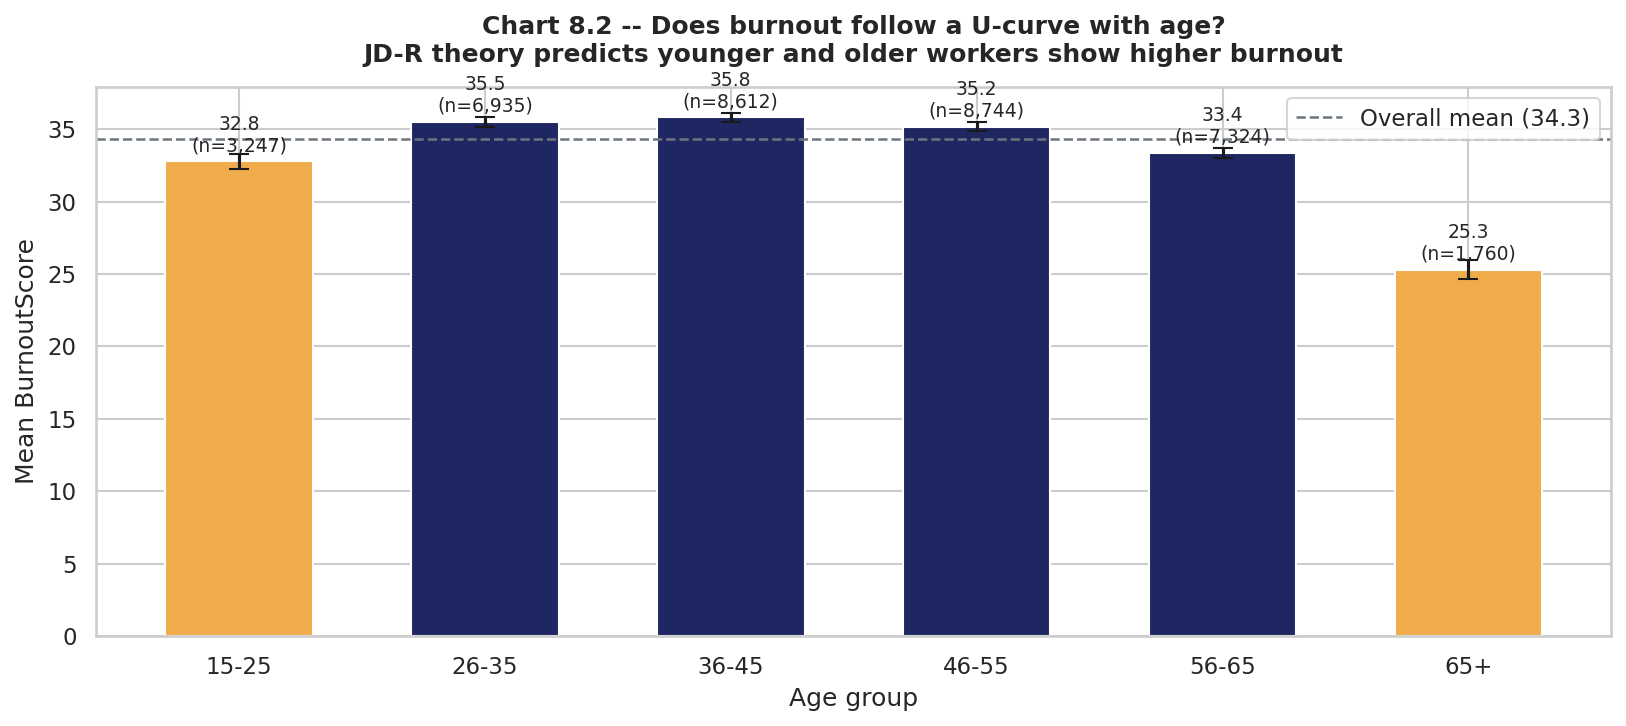

In [84]:
# Chart 8.2 -- Burnout by age group (U-curve test)
age_col = next((c for c in ['age','age_discrete','age_bands'] if c in df.columns), None)

if age_col:
    tmp = pd.DataFrame({
        'age': pd.to_numeric(df[age_col], errors='coerce'),
        'bs':  to_num('BurnoutScore')
    }).dropna()
    if tmp['age'].max() > 20:
        bins_a  = [15,25,35,45,55,65,100]
        labels_a = ['15-25','26-35','36-45','46-55','56-65','65+']
        tmp['age_band'] = pd.cut(tmp['age'], bins=bins_a, labels=labels_a)
    else:
        tmp['age_band'] = tmp['age'].astype(str)

    grp = tmp.groupby('age_band', observed=True)['bs'].agg(['mean','sem','count']).reset_index()
    grp.columns = ['age_band','mean','sem','count']

    fig, ax = plt.subplots(figsize=(11, 5))
    bar_colors2 = [ACCENT if i == 0 or i == len(grp)-1 else BLUE for i in range(len(grp))]
    bars = ax.bar(grp['age_band'].astype(str), grp['mean'],
                  color=bar_colors2, edgecolor='white', width=0.6,
                  yerr=grp['sem']*1.96, capsize=5)
    for bar, row in zip(bars, grp.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{row.mean:.1f}\n(n={row.count:,})', ha='center', va='bottom', fontsize=9)
    ax.axhline(tmp['bs'].mean(), color=GREY, linestyle='--', linewidth=1.2,
               label=f'Overall mean ({tmp["bs"].mean():.1f})')
    ax.set_xlabel('Age group')
    ax.set_ylabel('Mean BurnoutScore')
    ax.set_title('Chart 8.2 -- Does burnout follow a U-curve with age?\n'
                 'JD-R theory predicts younger and older workers show higher burnout', pad=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig('chart_8_2_burnout_by_age.png', bbox_inches='tight')
    plt.show()
else:
    print('Age column not found -- skipping chart 8.2')


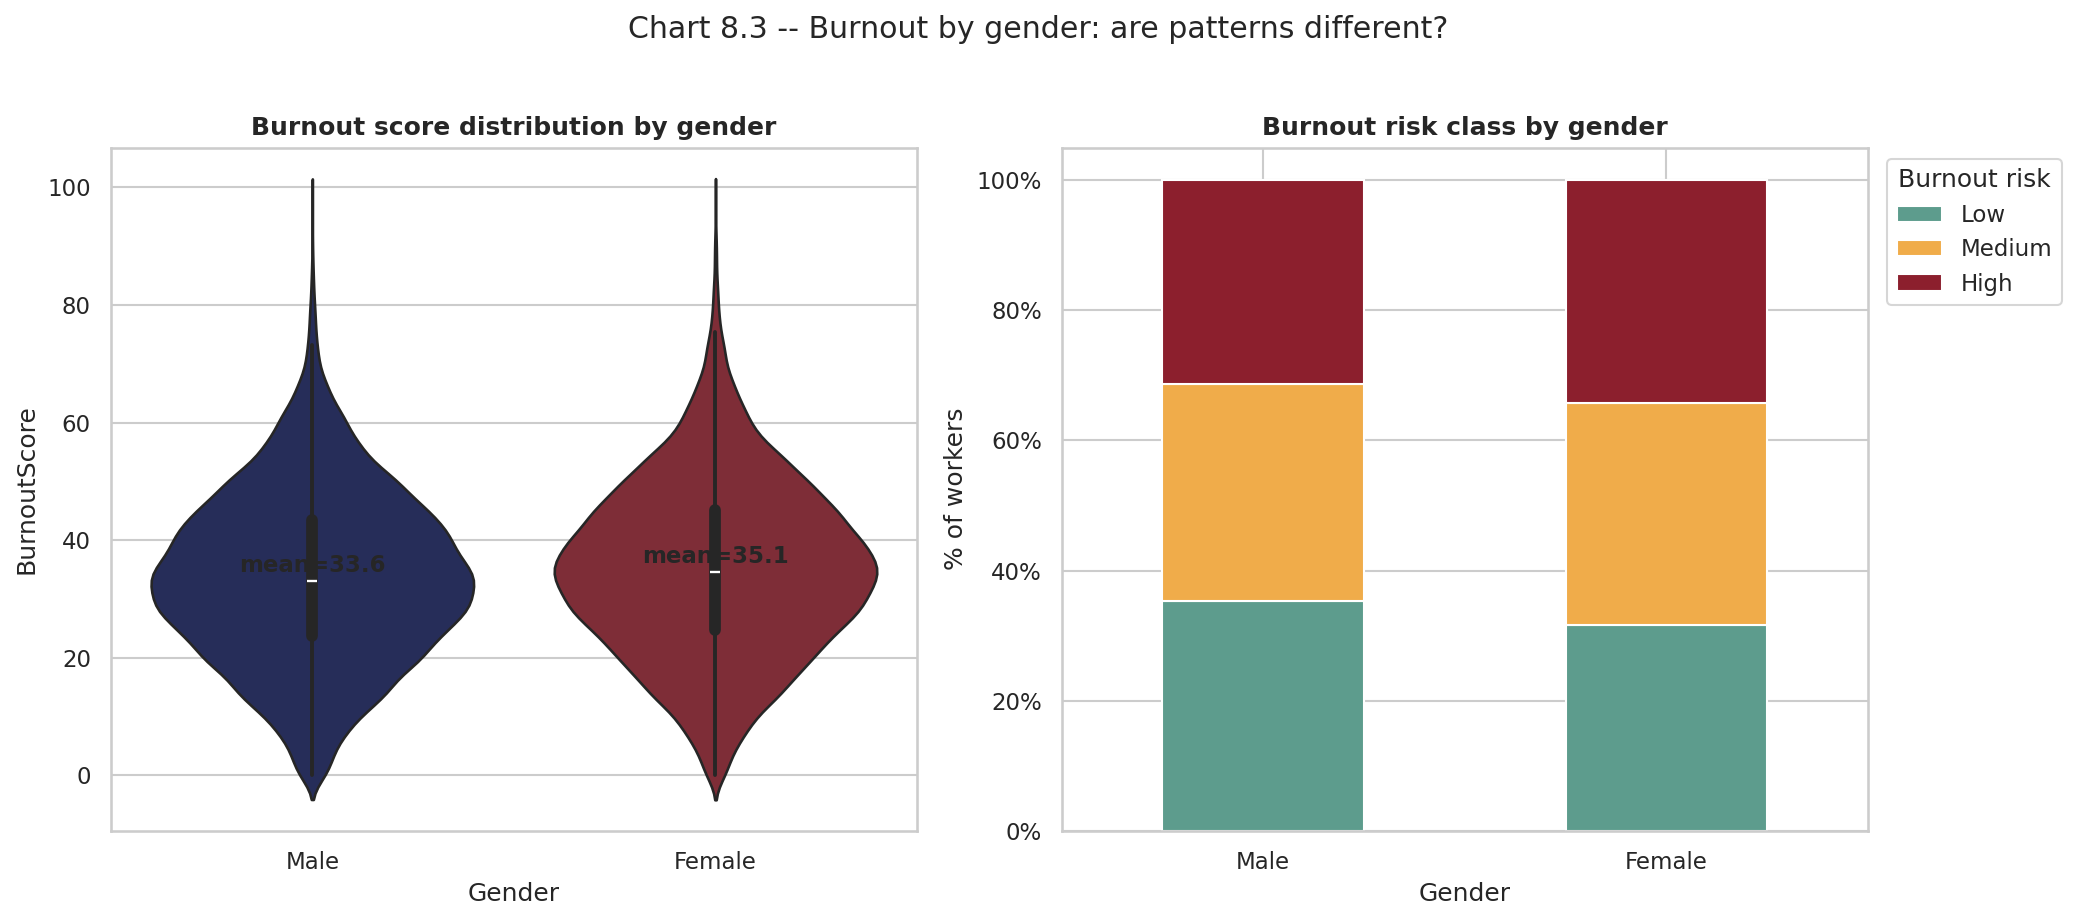

In [85]:
# Chart 8.3 -- Burnout by gender (violin + risk composition)
if 'sex2' in df.columns:
    tmp = pd.DataFrame({
        'gender': pd.to_numeric(df['sex2'], errors='coerce'),
        'bs':     to_num('BurnoutScore'),
        'BurnoutRisk': df['BurnoutRisk']
    }).dropna()
    tmp['Gender'] = tmp['gender'].map({1:'Male', 2:'Female'}).fillna('Other')
    order_g = ['Male','Female']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.violinplot(data=tmp, x='Gender', y='bs', order=order_g,
                   palette={'Male': BLUE, 'Female': RED},
                   inner='box', ax=axes[0])
    means_g = tmp.groupby('Gender')['bs'].mean()
    for i, g in enumerate(order_g):
        if g in means_g.index:
            axes[0].text(i, means_g[g]+1, f'mean={means_g[g]:.1f}',
                         ha='center', fontsize=11, fontweight='bold')
    axes[0].set_title('Burnout score distribution by gender')
    axes[0].set_ylabel('BurnoutScore')

    risk_comp = pd.crosstab(tmp['Gender'], tmp['BurnoutRisk'], normalize='index') * 100
    risk_comp = risk_comp.reindex(index=order_g, columns=ORDER)
    risk_comp.plot(kind='bar', stacked=True, color=[PALETTE[r] for r in ORDER],
                   edgecolor='white', ax=axes[1])
    axes[1].set_title('Burnout risk class by gender')
    axes[1].set_ylabel('% of workers')
    axes[1].yaxis.set_major_formatter(pct_fmt)
    axes[1].legend(title='Burnout risk', bbox_to_anchor=(1.01,1))
    plt.setp(axes[1].get_xticklabels(), rotation=0)

    fig.suptitle('Chart 8.3 -- Burnout by gender: are patterns different?', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_8_3_burnout_by_gender.png', bbox_inches='tight')
    plt.show()
else:
    print('sex2 column not found -- skipping chart 8.3')


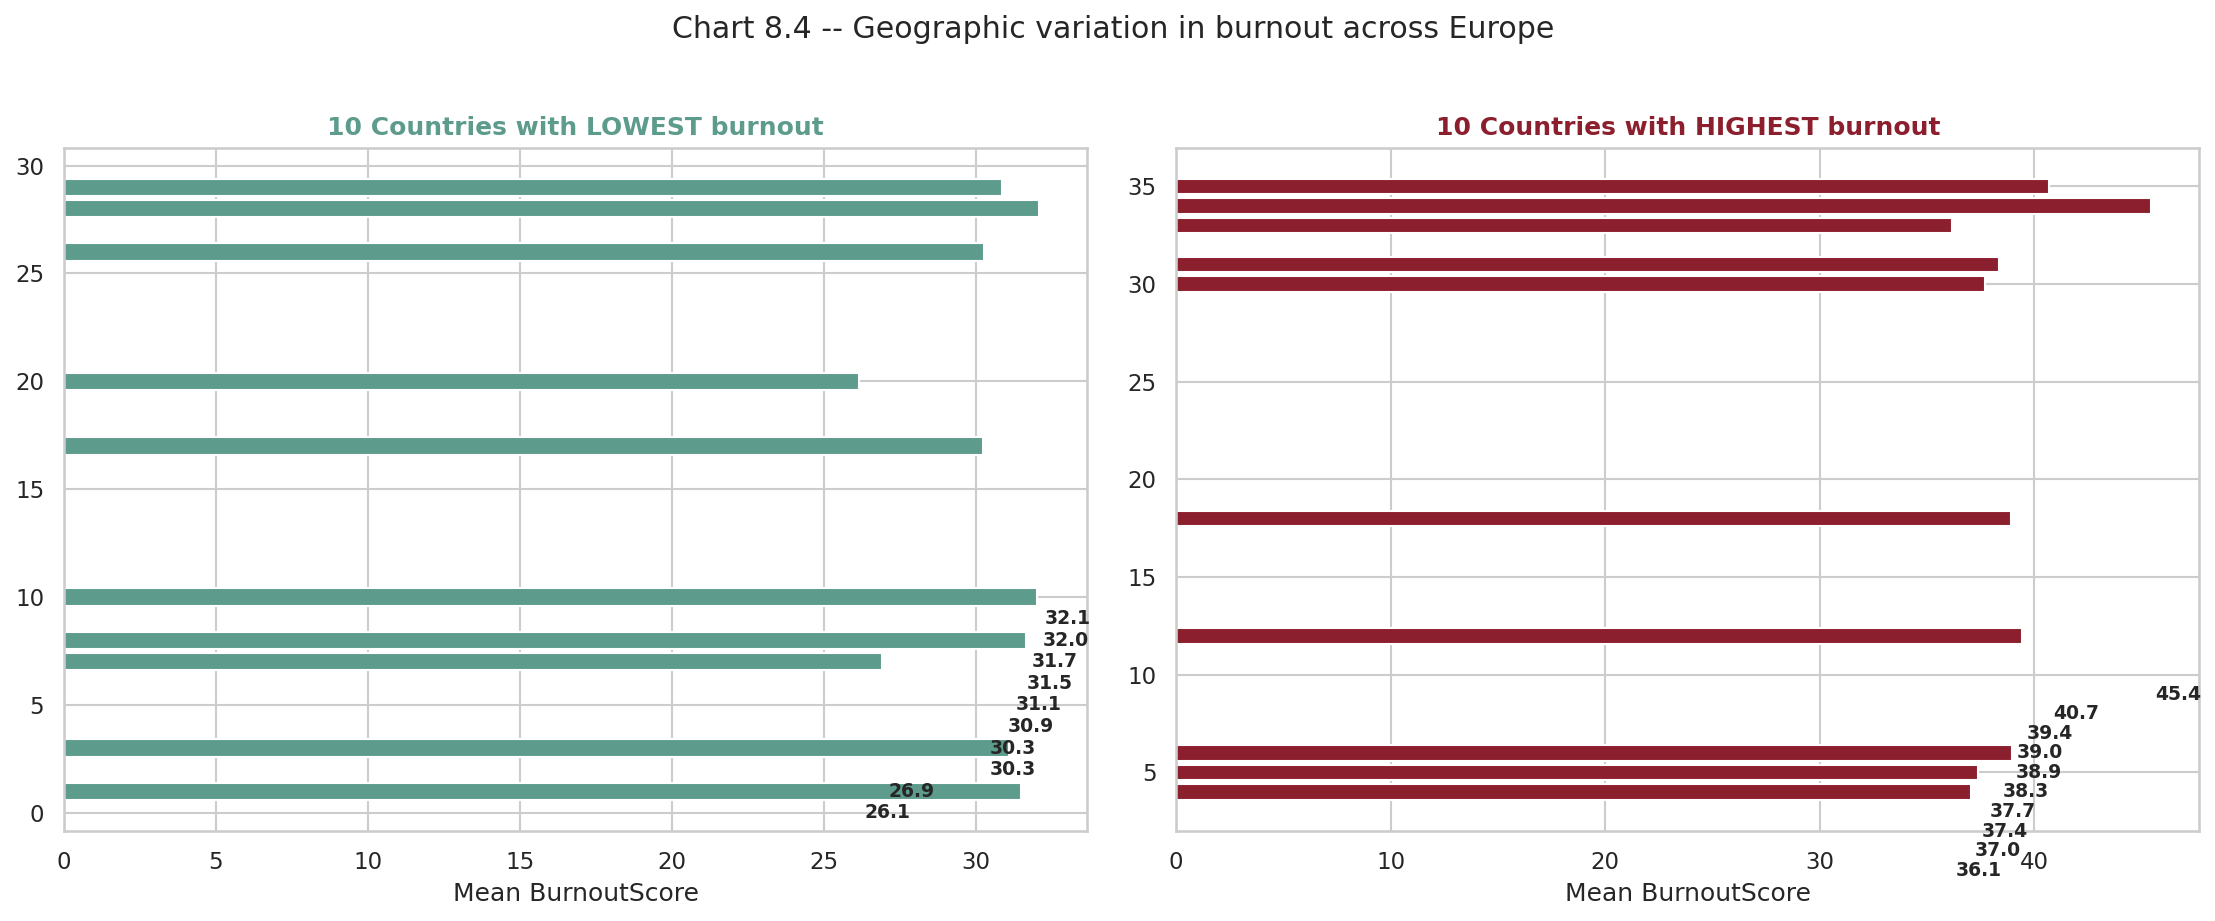

In [86]:
# Chart 8.4 -- Top 10 highest and lowest burnout countries
country_col = next((c for c in ['country','country_code','cntry'] if c in df.columns), None)

if country_col:
    tmp = pd.DataFrame({'country': df[country_col], 'bs': to_num('BurnoutScore')}).dropna()
    c_means = tmp.groupby('country')['bs'].agg(['mean','count']).reset_index()
    c_means.columns = ['country','mean','count']
    c_means = c_means[c_means['count'] >= 100].sort_values('mean')

    top10    = c_means.tail(10).reset_index(drop=True)
    bottom10 = c_means.head(10).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].barh(bottom10['country'], bottom10['mean'], color=TEAL, edgecolor='white')
    for i, row in bottom10.iterrows():
        axes[0].text(row['mean']+0.2, i, f"{row['mean']:.1f}", va='center',
                     fontsize=9, fontweight='bold')
    axes[0].set_title('10 Countries with LOWEST burnout', color=TEAL, fontweight='bold')
    axes[0].set_xlabel('Mean BurnoutScore')

    axes[1].barh(top10['country'], top10['mean'], color=RED, edgecolor='white')
    for i, row in top10.iterrows():
        axes[1].text(row['mean']+0.2, i, f"{row['mean']:.1f}", va='center',
                     fontsize=9, fontweight='bold')
    axes[1].set_title('10 Countries with HIGHEST burnout', color=RED, fontweight='bold')
    axes[1].set_xlabel('Mean BurnoutScore')

    fig.suptitle('Chart 8.4 -- Geographic variation in burnout across Europe', y=1.02)
    plt.tight_layout()
    plt.savefig('chart_8_4_burnout_by_country.png', bbox_inches='tight')
    plt.show()
else:
    print('Country column not found -- skipping chart 8.4')


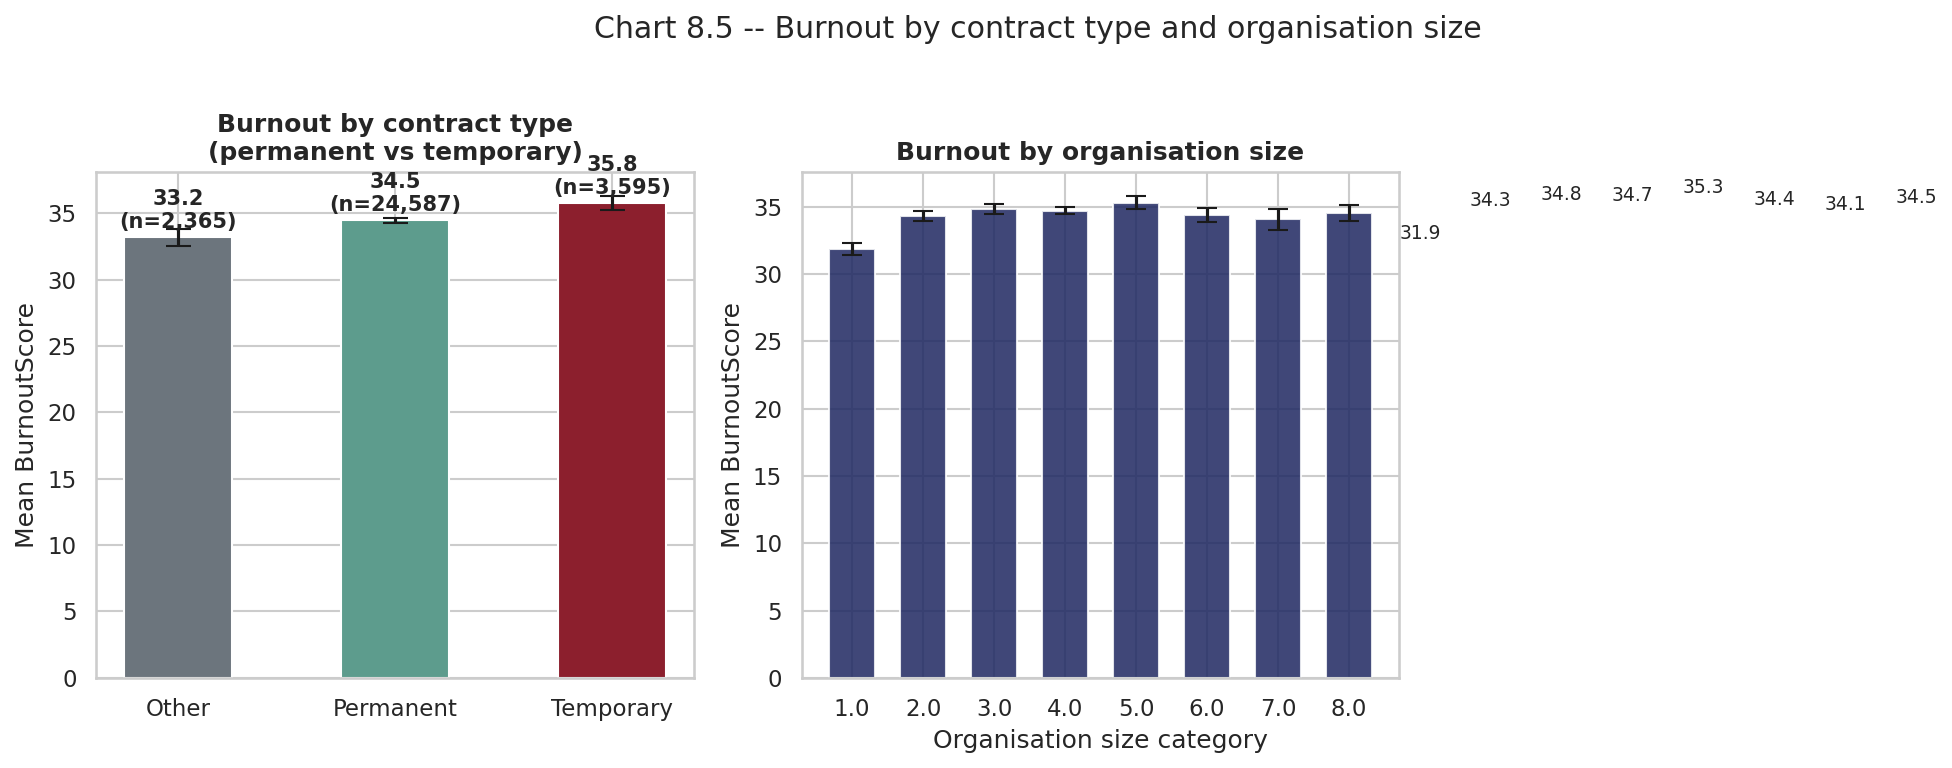

In [87]:
# Chart 8.5 -- Burnout by contract type and organisation size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'empl_contract' in df.columns:
    tmp = pd.DataFrame({
        'contract': pd.to_numeric(df['empl_contract'], errors='coerce'),
        'bs': to_num('BurnoutScore')
    }).dropna()
    tmp['Contract'] = tmp['contract'].map({1:'Permanent', 2:'Temporary'}).fillna('Other')
    grp = tmp.groupby('Contract')['bs'].agg(['mean','sem','count']).reset_index()
    c_colors = {'Permanent': TEAL, 'Temporary': RED, 'Other': GREY}
    bars = axes[0].bar(grp['Contract'], grp['mean'],
                       color=[c_colors.get(c, BLUE) for c in grp['Contract']],
                       edgecolor='white', width=0.5,
                       yerr=grp['sem']*1.96, capsize=6)
    for bar, row in zip(bars, grp.itertuples()):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                     f'{row.mean:.1f}\n(n={row.count:,})', ha='center', va='bottom',
                     fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Mean BurnoutScore')
    axes[0].set_title('Burnout by contract type\n(permanent vs temporary)')
else:
    axes[0].text(0.5, 0.5, 'empl_contract not found', ha='center', va='center')

if 'wp_size' in df.columns:
    tmp2 = pd.DataFrame({
        'size': pd.to_numeric(df['wp_size'], errors='coerce'),
        'bs':   to_num('BurnoutScore')
    }).dropna()
    grp2 = tmp2.groupby('size')['bs'].agg(['mean','sem','count']).reset_index()
    grp2.columns = ['size','mean','sem','count']
    grp2 = grp2[grp2['count'] >= 50]
    axes[1].bar(grp2['size'].astype(str), grp2['mean'],
                color=BLUE, edgecolor='white', width=0.65, alpha=0.85,
                yerr=grp2['sem']*1.96, capsize=5)
    for _, row in grp2.iterrows():
        axes[1].text(str(int(row['size'])), row['mean']+0.4,
                     f"{row['mean']:.1f}", ha='center', va='bottom', fontsize=9)
    axes[1].set_xlabel('Organisation size category')
    axes[1].set_ylabel('Mean BurnoutScore')
    axes[1].set_title('Burnout by organisation size')
else:
    axes[1].text(0.5, 0.5, 'wp_size not found', ha='center', va='center')

fig.suptitle('Chart 8.5 -- Burnout by contract type and organisation size', y=1.02)
plt.tight_layout()
plt.savefig('chart_8_5_contract_size.png', bbox_inches='tight')
plt.show()


---
## Section 9 -- Driver Correlations (Hand-off to Modelling Team)

These charts help Han (Person 4) understand which variables are most predictive and which are collinear.


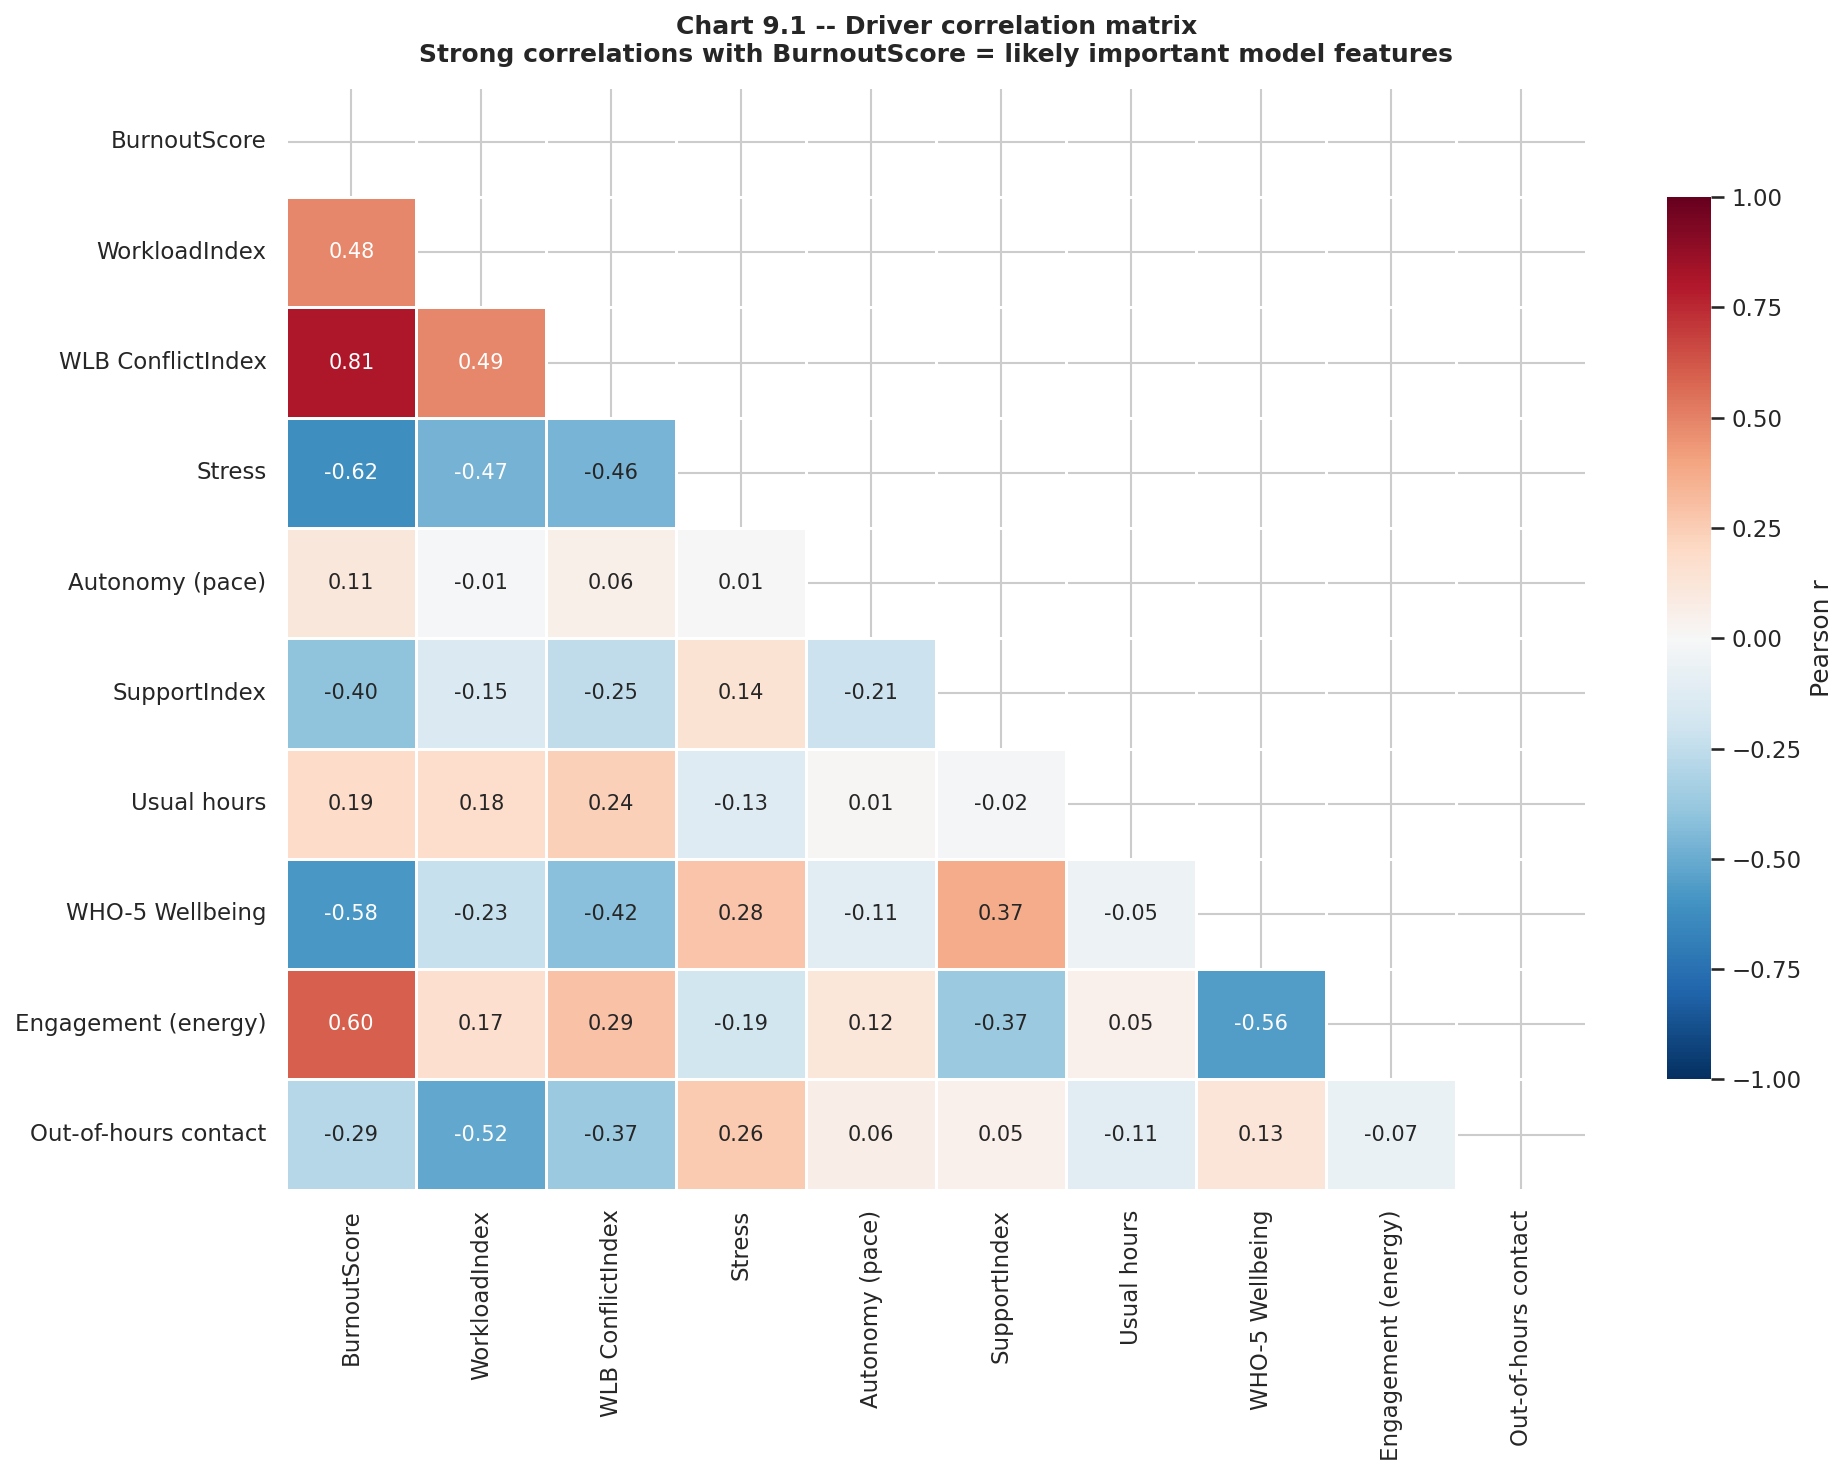

Top correlations with BurnoutScore:
  WLB ConflictIndex              r = +0.808
  Stress                         r = -0.620
  Engagement (energy)            r = +0.599
  WHO-5 Wellbeing                r = -0.582
  WorkloadIndex                  r = +0.485
  SupportIndex                   r = -0.403
  Out-of-hours contact           r = -0.287
  Usual hours                    r = +0.190


In [88]:
# Chart 9.1 -- Full driver correlation heatmap
corr_vars = {
    'BurnoutScore':          'BurnoutScore',
    'WorkloadIndex':         'WorkloadIndex',
    'WLB ConflictIndex':     'WorkLifeConflictIndex',
    'Stress':                'stress',
    'Autonomy (pace)':       'autonomy_speed',
    'SupportIndex':          'SupportIndex',
    'Usual hours':           'usual_hours',
    'WHO-5 Wellbeing':       'wellbeing',
    'Engagement (energy)':   'eng_energy',
    'Out-of-hours contact':  'contact_out_wh',
}
valid_corr = {k: v for k, v in corr_vars.items() if v in df.columns}

if len(valid_corr) >= 4:
    corr_data = pd.DataFrame({
        k: pd.to_numeric(df[v], errors='coerce') for k, v in valid_corr.items()
    }).dropna()
    corr_matrix = corr_data.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
                annot_kws={'size': 10}, ax=ax)
    ax.set_title('Chart 9.1 -- Driver correlation matrix\n'
                 'Strong correlations with BurnoutScore = likely important model features', pad=12)
    plt.tight_layout()
    plt.savefig('chart_9_1_correlation_heatmap.png', bbox_inches='tight')
    plt.show()

    print('Top correlations with BurnoutScore:')
    bs_corr = corr_matrix['BurnoutScore'].drop('BurnoutScore').sort_values(key=abs, ascending=False)
    for var, r in bs_corr.head(8).items():
        print(f'  {var:<30} r = {r:+.3f}')


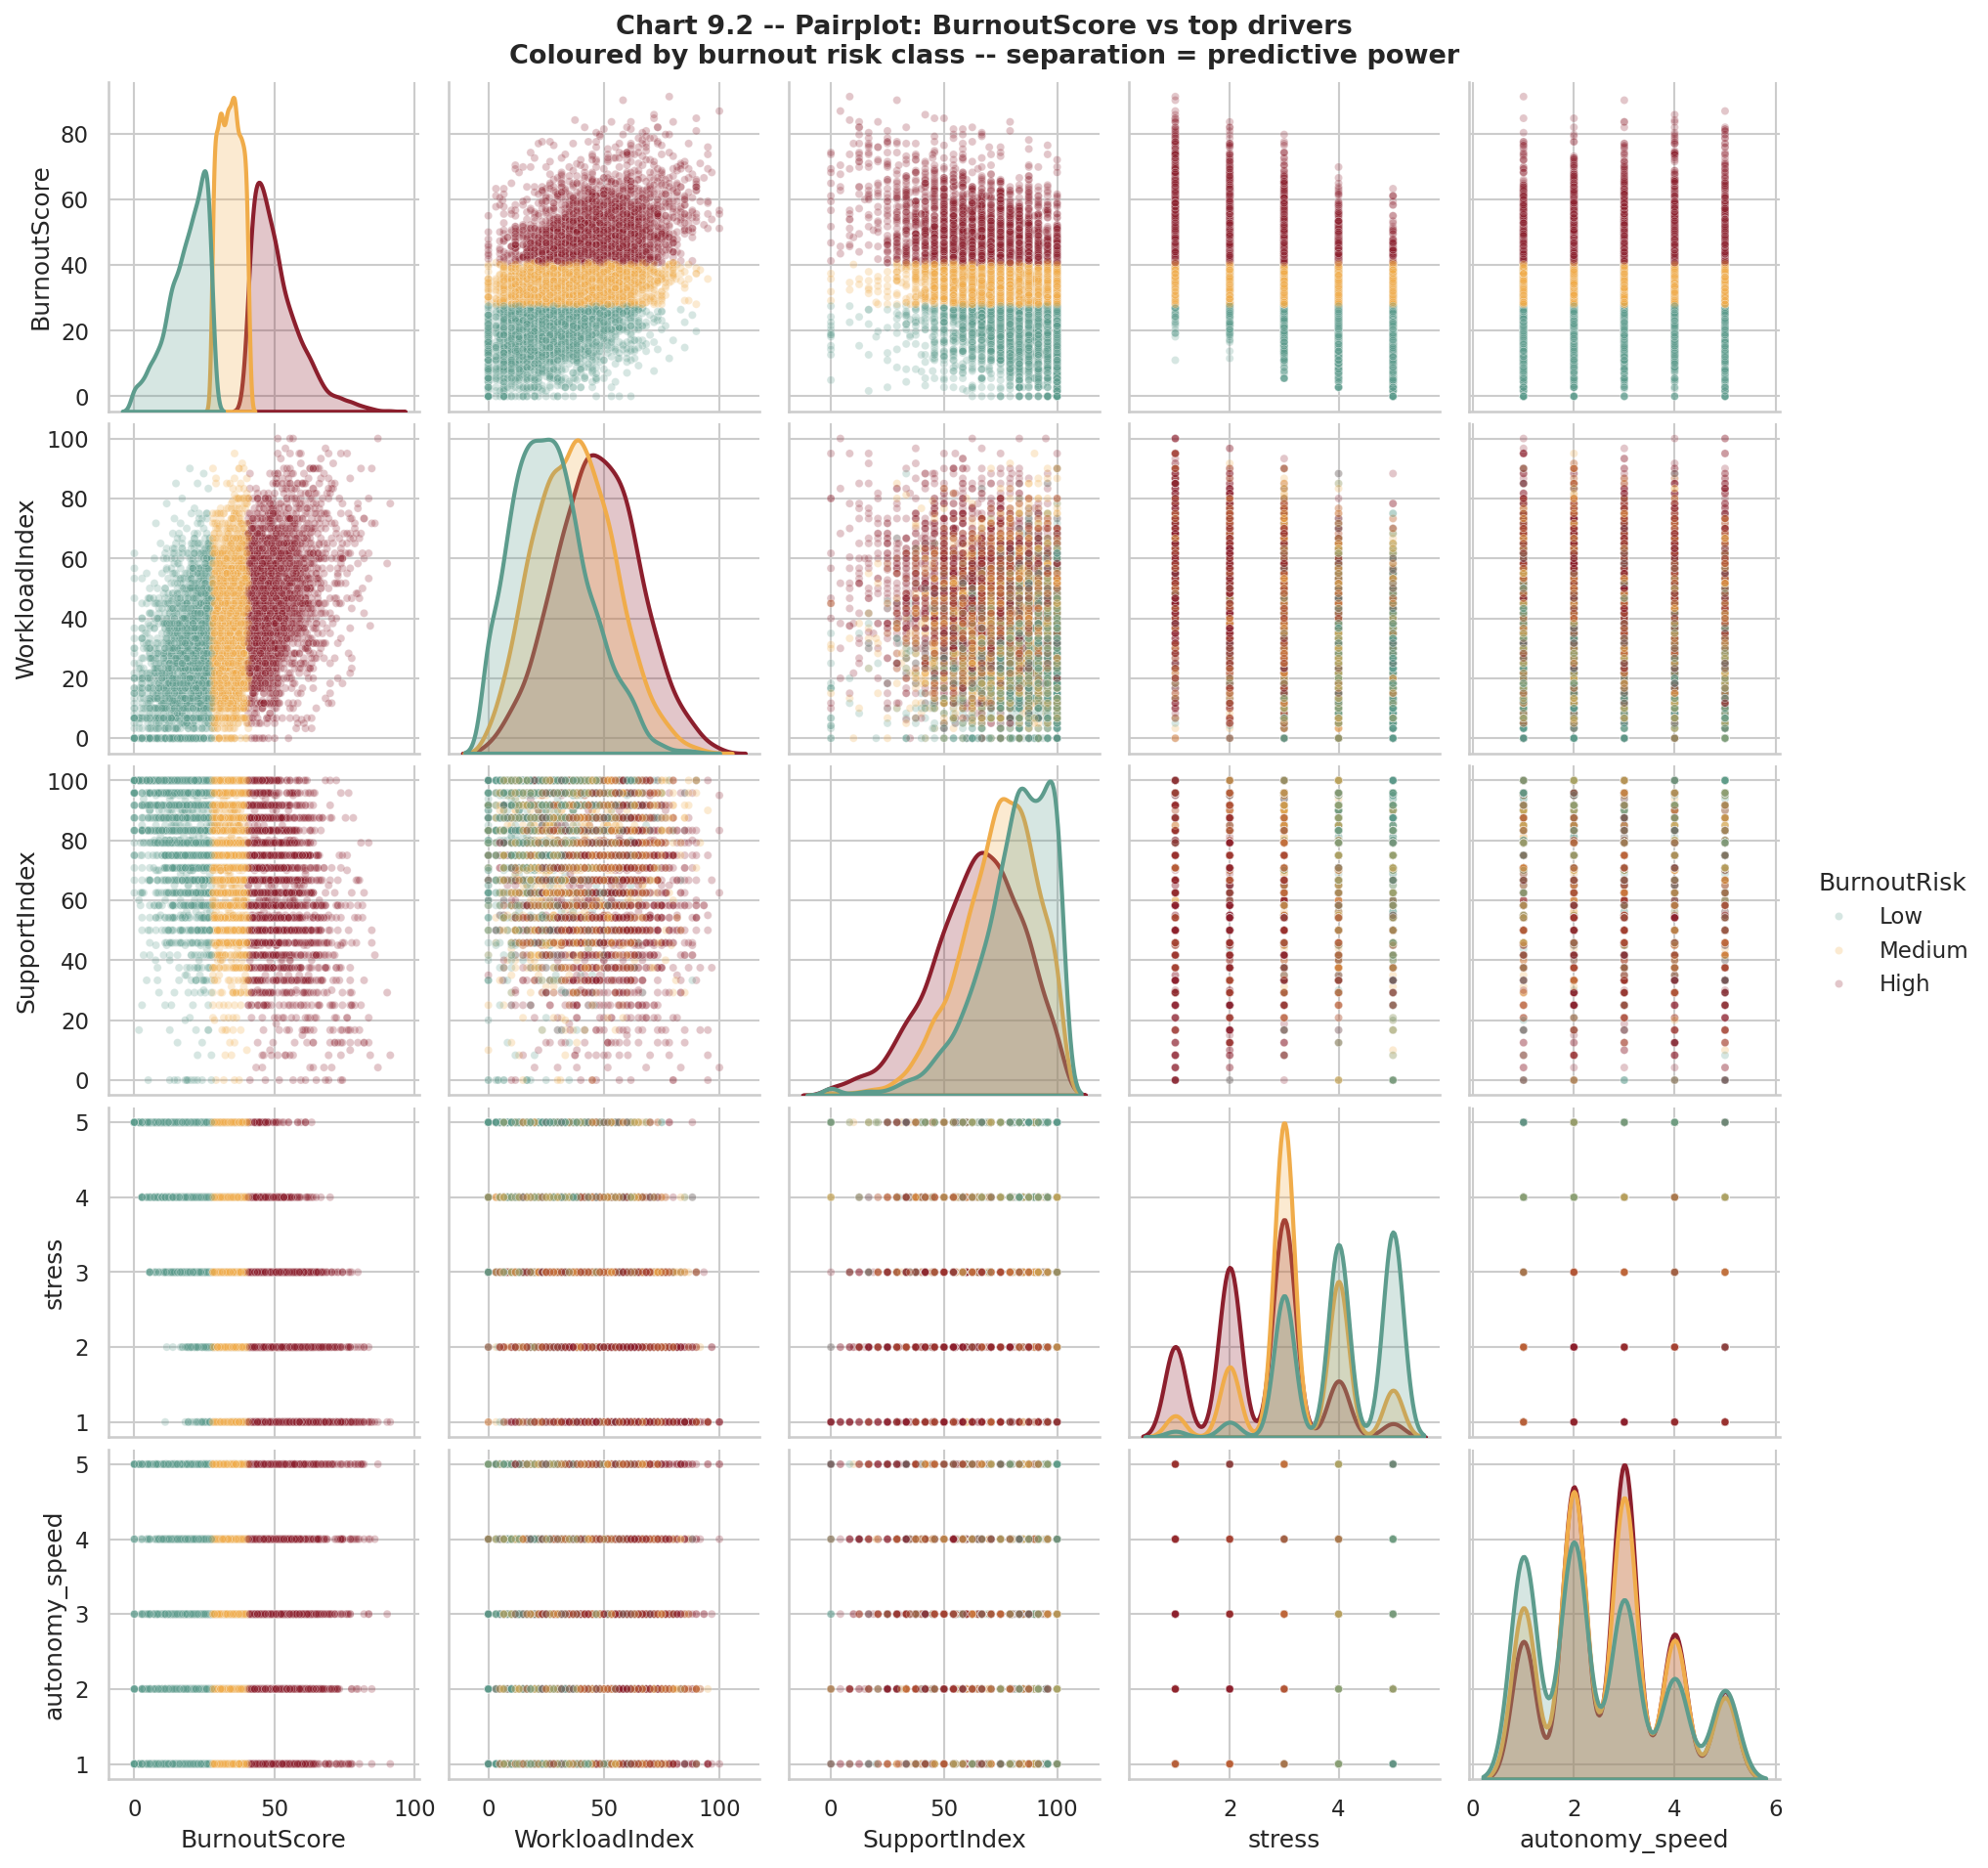

Pairplot saved.


In [89]:
# Chart 9.2 -- Pairplot: BurnoutScore vs top 5 drivers, coloured by BurnoutRisk
pairplot_cols = ['BurnoutScore','WorkloadIndex','SupportIndex','stress','autonomy_speed']
valid_pp = [c for c in pairplot_cols if c in df.columns]

if len(valid_pp) >= 3 and 'BurnoutRisk' in df.columns:
    pp_df = df[valid_pp + ['BurnoutRisk']].copy()
    for c in valid_pp:
        pp_df[c] = pd.to_numeric(pp_df[c], errors='coerce')
    pp_df = pp_df.dropna()
    if len(pp_df) > 8000:
        pp_df = pp_df.sample(8000, random_state=42)

    g = sns.pairplot(pp_df, hue='BurnoutRisk', hue_order=ORDER,
                     palette=PALETTE, diag_kind='kde',
                     plot_kws={'alpha': 0.25, 's': 15},
                     diag_kws={'linewidth': 2})
    g.figure.suptitle('Chart 9.2 -- Pairplot: BurnoutScore vs top drivers\n'
                       'Coloured by burnout risk class -- separation = predictive power',
                       y=1.02, fontsize=13, fontweight='bold')
    plt.savefig('chart_9_2_pairplot.png', bbox_inches='tight')
    plt.show()
    print('Pairplot saved.')
else:
    print('Not enough columns for pairplot -- skipping chart 9.2')


---
## EDA Summary -- Key Findings

| # | Finding | Chart |
|---|---------|-------|
| 1 | BurnoutScore distribution and class balance | 1.1, 1.2 |
| 2 | Exhaustion is the dominant burnout component | 1.3 |
| 3 | BurnoutScore negatively correlates with WHO-5 wellbeing (score is valid) | 1.4 |
| 4 | Heavier workload clearly predicts higher burnout risk | 2.1, 2.2 |
| 5 | Tight deadlines, high speed, no rest are most common in High-burnout workers | 2.3 |
| 6 | Workers with low autonomy show higher burnout | 3.1, 3.2 |
| 7 | Recovery resources (breaks) are a protective factor | 3.3 |
| 8 | Low manager support is strongly associated with burnout | 4.1, 4.2, 4.3 |
| 9 | Work-life conflict rises sharply with burnout class | 5.1, 5.2 |
| 10 | Stress level 4-5 is heavily concentrated in High burnout class | 5.3 |
| 11 | High-burnout workers report more sleep problems, anxiety, health impact | 6.1 |
| 12 | Engagement collapses entirely in the High burnout class | 6.2 |
| 13 | High-burnout workers are far more likely to intend to quit | 6.4 |
| 14 | Theme ranking shows Workload / WLB Conflict / Stress as top burnout drivers | 7.2 |
| 15 | Sector, age, gender, and country all show meaningful burnout variation | 8.1-8.5 |

---
*Part 3 produced by Person 3 (Sharan) -- IS6611 Group 6 -- MSc Business Analytics, UCC*


# HAN
## Part 4: Machine Learning Models
###This section trains and evaluates three classifiers to predict `BurnoutRisk`
###(Low / Medium / High), the target engineered by Part 2 from the continuous
###`BurnoutScore`.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

PALETTE = {'Low': '#5D9C8D', 'Medium': '#F0AC4A', 'High': '#8C1F2D'}
ORDER   = ['Low', 'Medium', 'High']
BLUE    = '#2563EB'
GREY    = '#6B7280'

## 4.1 Feature-Engineered Dataset

We load the CSV saved by Part 2 (`EWCS2024_FeatureEngineered.csv`).
This file already contains `BurnoutScore`, `BurnoutRisk`, `WorkloadIndex`,
`SupportIndex`and `WorkLifeConflictIndex` alongside the original cleaned columns.

In [91]:
df = pd.read_csv('/content/drive/MyDrive/Artefact V2/EWCS2024_FeatureEngineered.csv')

print("Dataset shape:", df.shape)
print("\nTarget column — BurnoutRisk value counts:")
print(df['BurnoutRisk'].value_counts())
print("\nClass proportions (%):")
print((df['BurnoutRisk'].value_counts(normalize=True) * 100).round(1))

Dataset shape: (36644, 393)

Target column — BurnoutRisk value counts:
BurnoutRisk
Medium    12371
Low       12239
High      12012
Name: count, dtype: int64

Class proportions (%):
BurnoutRisk
Medium    33.8
Low       33.4
High      32.8
Name: proportion, dtype: float64


## 4.2 Feature Selection

Not all variables in the dataset can be used as model inputs. The items
that went into building `BurnoutScore` such as exhaustion, engagement, stress,
work-life conflict are essentially part of the target itself. Using them
as features would mean the model is just reading the answer off the page.

So we stick to structural variables: workload demands, manager support,
autonomy, working hours and demographic context. Things that describe
a person's working conditions without already encoding how burned out they are.

In [92]:
# These columns were NOT used to build BurnoutScore / BurnoutRisk

CANDIDATE_FEATURES = [
    # Composite indices (safe — built from separate item blocks)
    'WorkloadIndex',
    'SupportIndex',

    # Working time & intensity (raw items, not in target construction)
    'usual_hours',
    'highspeed',
    'tightdead',
    'norest',
    'longday',
    'shift',
    'night',
    'weekend',

    # Autonomy / control
    'autonomy_speed',
    'autonomy_methods',
    'autonomy_order',
    'take_break',
    'able_hour_off',

    # Technology / out-of-hours contact
    'contact_out_wh',

    # Demographic and job context
    'age',
    'sex2',
    'isced',
    'seniority',
    'wp_size',
    'empl_contract',
    'ISCO_1',

]

# We will keep only columns that exist in the loaded dataframe
FEATURES = [c for c in CANDIDATE_FEATURES if c in df.columns]
TARGET   = 'BurnoutRisk'

print(f"Features available: {len(FEATURES)} / {len(CANDIDATE_FEATURES)}")
print("Features used:", FEATURES)

# We verify none of the leakage variables slipped in
LEAKAGE = ['exhaust_emot', 'exhaust_phys', 'stress', 'eng_energy',
           'eng_enthusiastic', 'eng_timeflies', 'work_life_balance',
           'wlb_worry', 'wlb_tired', 'wlb_timefamily', 'wlb_concentrate',
           'WorkLifeConflictIndex']
leaked = [c for c in LEAKAGE if c in FEATURES]
assert len(leaked) == 0, f"LEAKAGE DETECTED: {leaked}"
print("\nLeakage check passed")

Features available: 23 / 23
Features used: ['WorkloadIndex', 'SupportIndex', 'usual_hours', 'highspeed', 'tightdead', 'norest', 'longday', 'shift', 'night', 'weekend', 'autonomy_speed', 'autonomy_methods', 'autonomy_order', 'take_break', 'able_hour_off', 'contact_out_wh', 'age', 'sex2', 'isced', 'seniority', 'wp_size', 'empl_contract', 'ISCO_1']

Leakage check passed


In [93]:
model_df = df[FEATURES + [TARGET]].copy()

for c in FEATURES:
    model_df[c] = pd.to_numeric(model_df[c], errors='coerce')

# CHECK FIRST — see the scale of missingness before doing anything
print("NaN count per feature:")
print(model_df[FEATURES].isnull().sum().sort_values(ascending=False))
print(f"\nTotal rows: {len(model_df)}")

NaN count per feature:
contact_out_wh      6305
empl_contract       6079
SupportIndex        6047
longday             1316
usual_hours         1142
weekend              831
wp_size              783
able_hour_off        611
norest               512
night                454
seniority            405
tightdead            223
take_break           209
autonomy_speed       144
autonomy_methods     141
highspeed            134
shift                128
autonomy_order       123
isced                 88
sex2                  41
WorkloadIndex          1
age                    0
ISCO_1                 0
dtype: int64

Total rows: 36644


In [94]:
model_df = df[FEATURES + [TARGET]].copy()

for c in FEATURES:
    model_df[c] = pd.to_numeric(model_df[c], errors='coerce')

before = len(model_df)
model_df.dropna(inplace=True)
after  = len(model_df)

print(f"Rows before dropna : {before:,}")
print(f"Rows after  dropna : {after:,}  ({before - after:,} dropped)")
print(f"\nModelling dataset  : {model_df.shape[0]:,} rows × {len(FEATURES)} features")
print("\nClass distribution after cleaning:")
print(model_df[TARGET].value_counts())

Rows before dropna : 36,644
Rows after  dropna : 26,879  (9,765 dropped)

Modelling dataset  : 26,879 rows × 23 features

Class distribution after cleaning:
BurnoutRisk
Medium    9201
Low       9065
High      8613
Name: count, dtype: int64


In [95]:
# scikit-learn and XGBoost require integer labels.
# We encode in the ORDER defined by Part 3 (Low=0, Medium=1, High=2).

le = LabelEncoder()
le.fit(ORDER)
y  = le.transform(model_df[TARGET])
X  = model_df[FEATURES].values

CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

print("Label encoding:")
for i, name in enumerate(CLASS_NAMES):
    count = (y == i).sum()
    print(f"  {i} → {name:8s}  ({count:,} samples, {count/len(y)*100:.1f}%)")

Label encoding:
  0 → High      (8,613 samples, 32.0%)
  1 → Low       (9,065 samples, 33.7%)
  2 → Medium    (9,201 samples, 34.2%)


## 4.3 Train / Test Split

We split the data 80% for training and 20% for testing. The `stratify=y`
argument makes sure the proportion of Low, Medium and High burnout cases
stays consistent across both sets. `random_state=42`
just pins the randomness so the split is the same every time the code runs.

In [96]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(y)*100:.0f}%)")

# Confirm class balance is preserved
split_check = pd.DataFrame({
    'Class':   CLASS_NAMES,
    'Train %': [(y_train == i).mean() * 100 for i in range(N_CLASSES)],
    'Test %':  [(y_test  == i).mean() * 100 for i in range(N_CLASSES)]
}).round(1)
print("\nClass proportions preserved across split:")
print(split_check.to_string(index=False))

Training set : 21,503 rows  (80%)
Test set     : 5,376 rows  (20%)

Class proportions preserved across split:
 Class  Train %  Test %
  High     32.0    32.0
   Low     33.7    33.7
Medium     34.2    34.2


## 4.4 Model Training

We train three models on the same split:

| Model | Why we picked it |
|---|---|
| Logistic Regression | Simple baseline to benchmark against |
| Random Forest | Handles non-linear relationships in survey data without heavy tuning |
| XGBoost | Strongest out-of-the-box performer on tabular data |

No hyperparameter tuning is applied at this stage so what you see is honest baseline performance.

In [97]:
#  Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='auto')
lr.fit(X_train, y_train)
print("Logistic Regression : trained")

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest : trained")

#XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
print("XGBoost : trained")

Logistic Regression : trained
Random Forest : trained
XGBoost : trained


In [98]:
# We use evaluation model to categorize
# Computes all five required metrics on the test set for any trained model.
# Macro-average is used throughout: each class is weighted equally,
# which is appropriate here because all three burnout risk classes matter.

def evaluate_model(name, model, X_test, y_test, n_classes):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    if y_prob is not None:
        y_bin = label_binarize(y_test, classes=list(range(n_classes)))
        auc   = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    else:
        auc = np.nan

    return {
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1':        round(f1,   4),
        'ROC-AUC':   round(auc,  4)
    }

## 4.5 Evaluation Metrics

All five metrics are evaluated on the test set only
| Metric | What it tells us |
|---|---|
| Accuracy | How many predictions were correct overall |
| Precision | Of those flagged as a given risk class, how many actually were |
| Recall | Of all actual members of a class, how many the model caught |
| F1 | Balance between Precision and Recall  |
| ROC-AUC | How well the model separates the three classes from each other |

We use macro averaging (each class is weighted equally).

In [99]:
# Compute all metrics
results = [
    evaluate_model('Logistic Regression', lr,  X_test, y_test, N_CLASSES),
    evaluate_model('Random Forest',        rf,  X_test, y_test, N_CLASSES),
    evaluate_model('XGBoost',              xgb, X_test, y_test, N_CLASSES),
]

results_df = pd.DataFrame(results).set_index('Model')

print("MODEL EVALUATION — TEST SET RESULTS (macro average)")
print(results_df.to_string())
print(f"\nBest model by F1      : {results_df['F1'].idxmax()}")
print(f"Best model by ROC-AUC : {results_df['ROC-AUC'].idxmax()}")

MODEL EVALUATION — TEST SET RESULTS (macro average)
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.5683     0.5621  0.5701  0.5646   0.7530
Random Forest          0.5735     0.5712  0.5749  0.5725   0.7584
XGBoost                0.5763     0.5780  0.5772  0.5773   0.7609

Best model by F1      : XGBoost
Best model by ROC-AUC : XGBoost


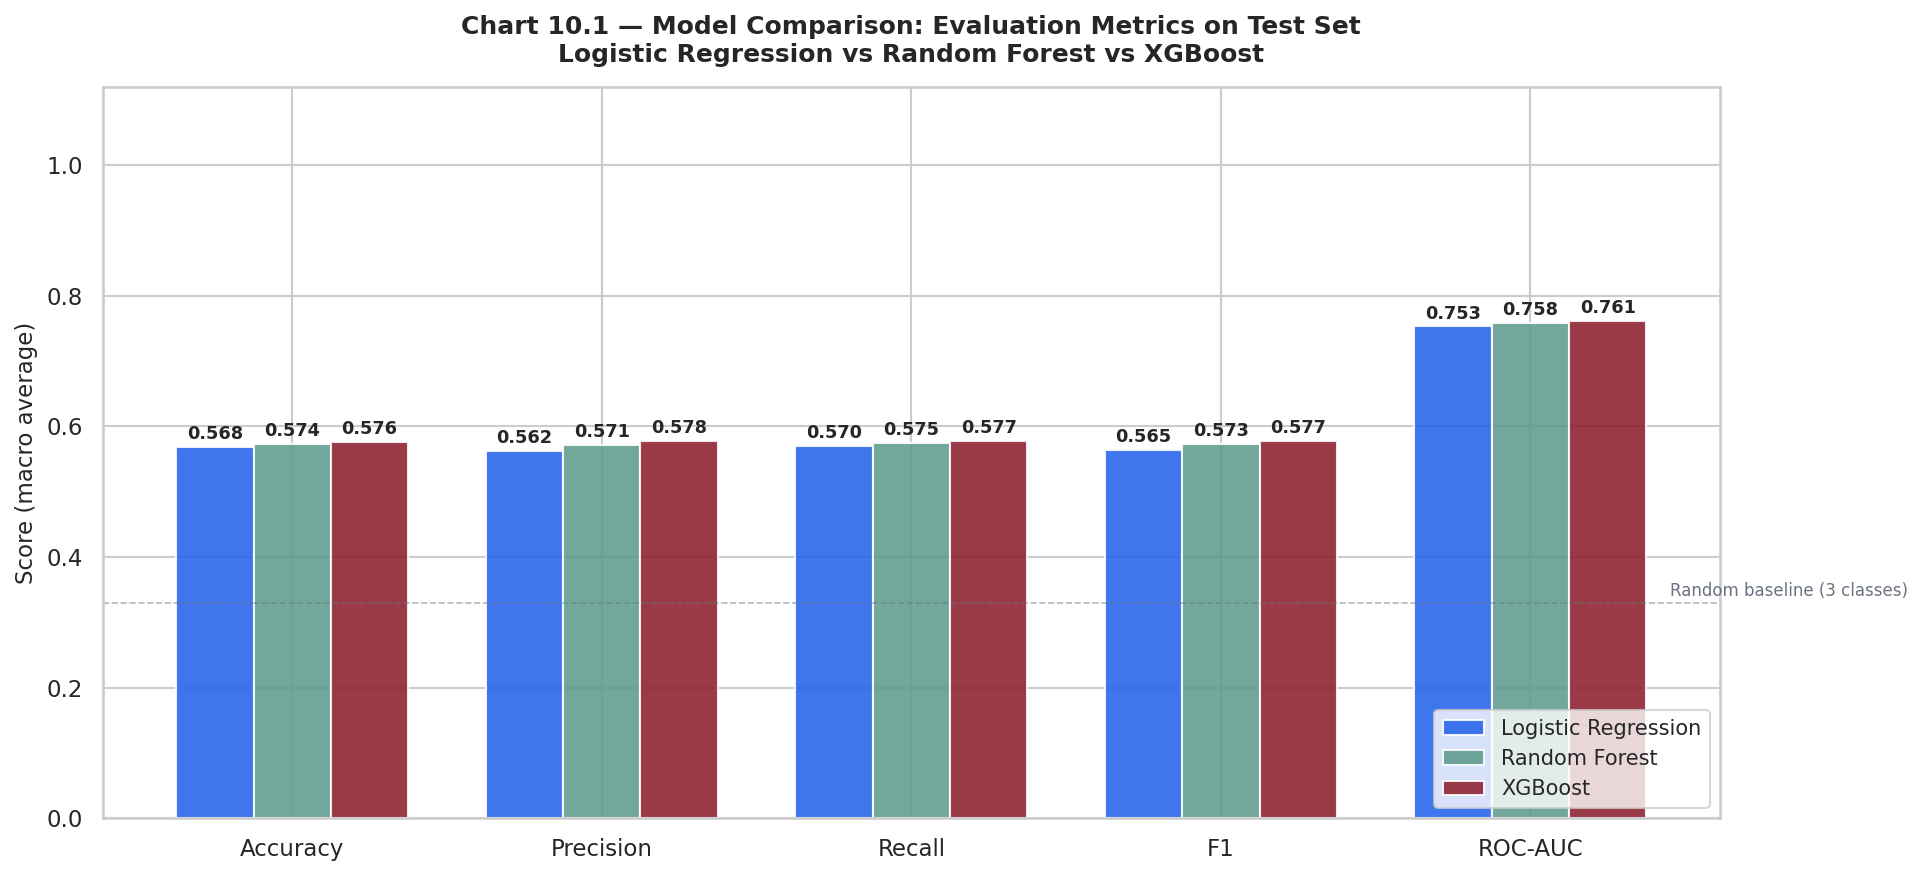

In [100]:
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_names  = results_df.index.tolist()
bar_colors   = ['#2563EB', '#5D9C8D', '#8C1F2D']

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model, color) in enumerate(zip(model_names, bar_colors)):
    vals = results_df.loc[model, metrics].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, edgecolor='white', alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.006,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score (macro average)', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Chart 10.1 — Model Comparison: Evaluation Metrics on Test Set\n'
             'Logistic Regression vs Random Forest vs XGBoost', pad=12, fontsize=12)
ax.legend(loc='lower right', frameon=True, fontsize=10)
ax.axhline(0.33, color=GREY, linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(len(metrics) - 0.3, 0.34, 'Random baseline (3 classes)', color=GREY, fontsize=8)

plt.tight_layout()
plt.savefig('chart_10_1_model_comparison.png', bbox_inches='tight')
plt.show()

## 4.6 Confusion Matrices

A confusion matrix breaks down where each model gets it right and where
it doesn't. The diagonal is correct predictions; everything off it is a
misclassification. What we're really interested in here is the pattern
a model confusing Low with Medium is a much softer error than confusing
Low with High and that distinction matters when the end goal is flagging
employees actually at risk.

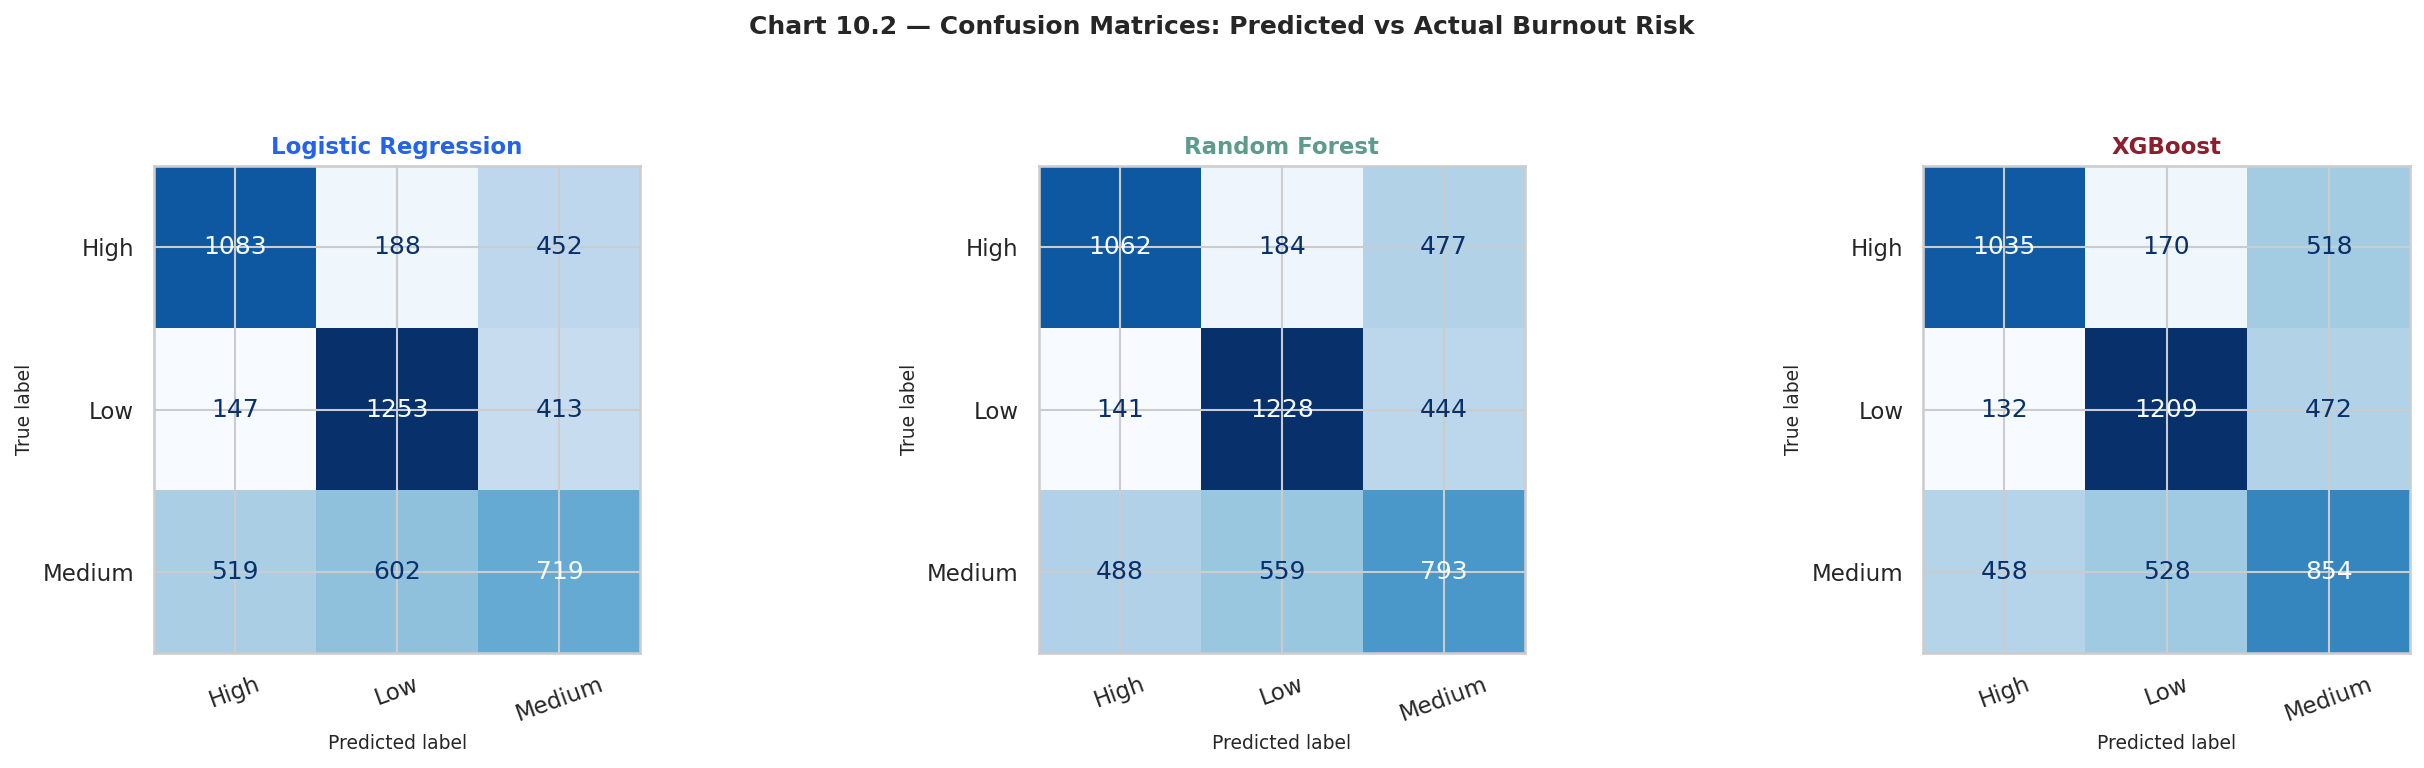

In [101]:
#Chart 10.2 — Confusion matrices
models_list = [
    ('Logistic Regression', lr,  '#2563EB'),
    ('Random Forest',        rf,  '#5D9C8D'),
    ('XGBoost',              xgb, '#8C1F2D'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Chart 10.2 — Confusion Matrices: Predicted vs Actual Burnout Risk\n'
             ,
             fontsize=12, fontweight='bold', y=1.02)

for ax, (name, model, color) in zip(axes, models_list):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Predicted label', fontsize=9)
    ax.set_ylabel('True label', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart_10_2_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 4.7 Feature Importance

Both Random Forest and XGBoost tell you which features they leaned on
most when making predictions. This is arguably the most useful output
for the research question.
| Model | Importance measure |
|---|---|
| Random Forest | Mean decrease in Gini impurity across all splits |
| XGBoost | Average gain when a feature is used to split |

Since the feature set is leakage-free, the ranking is interpretable which reflects the predictive signal in working conditions
themselves.*italicized text*

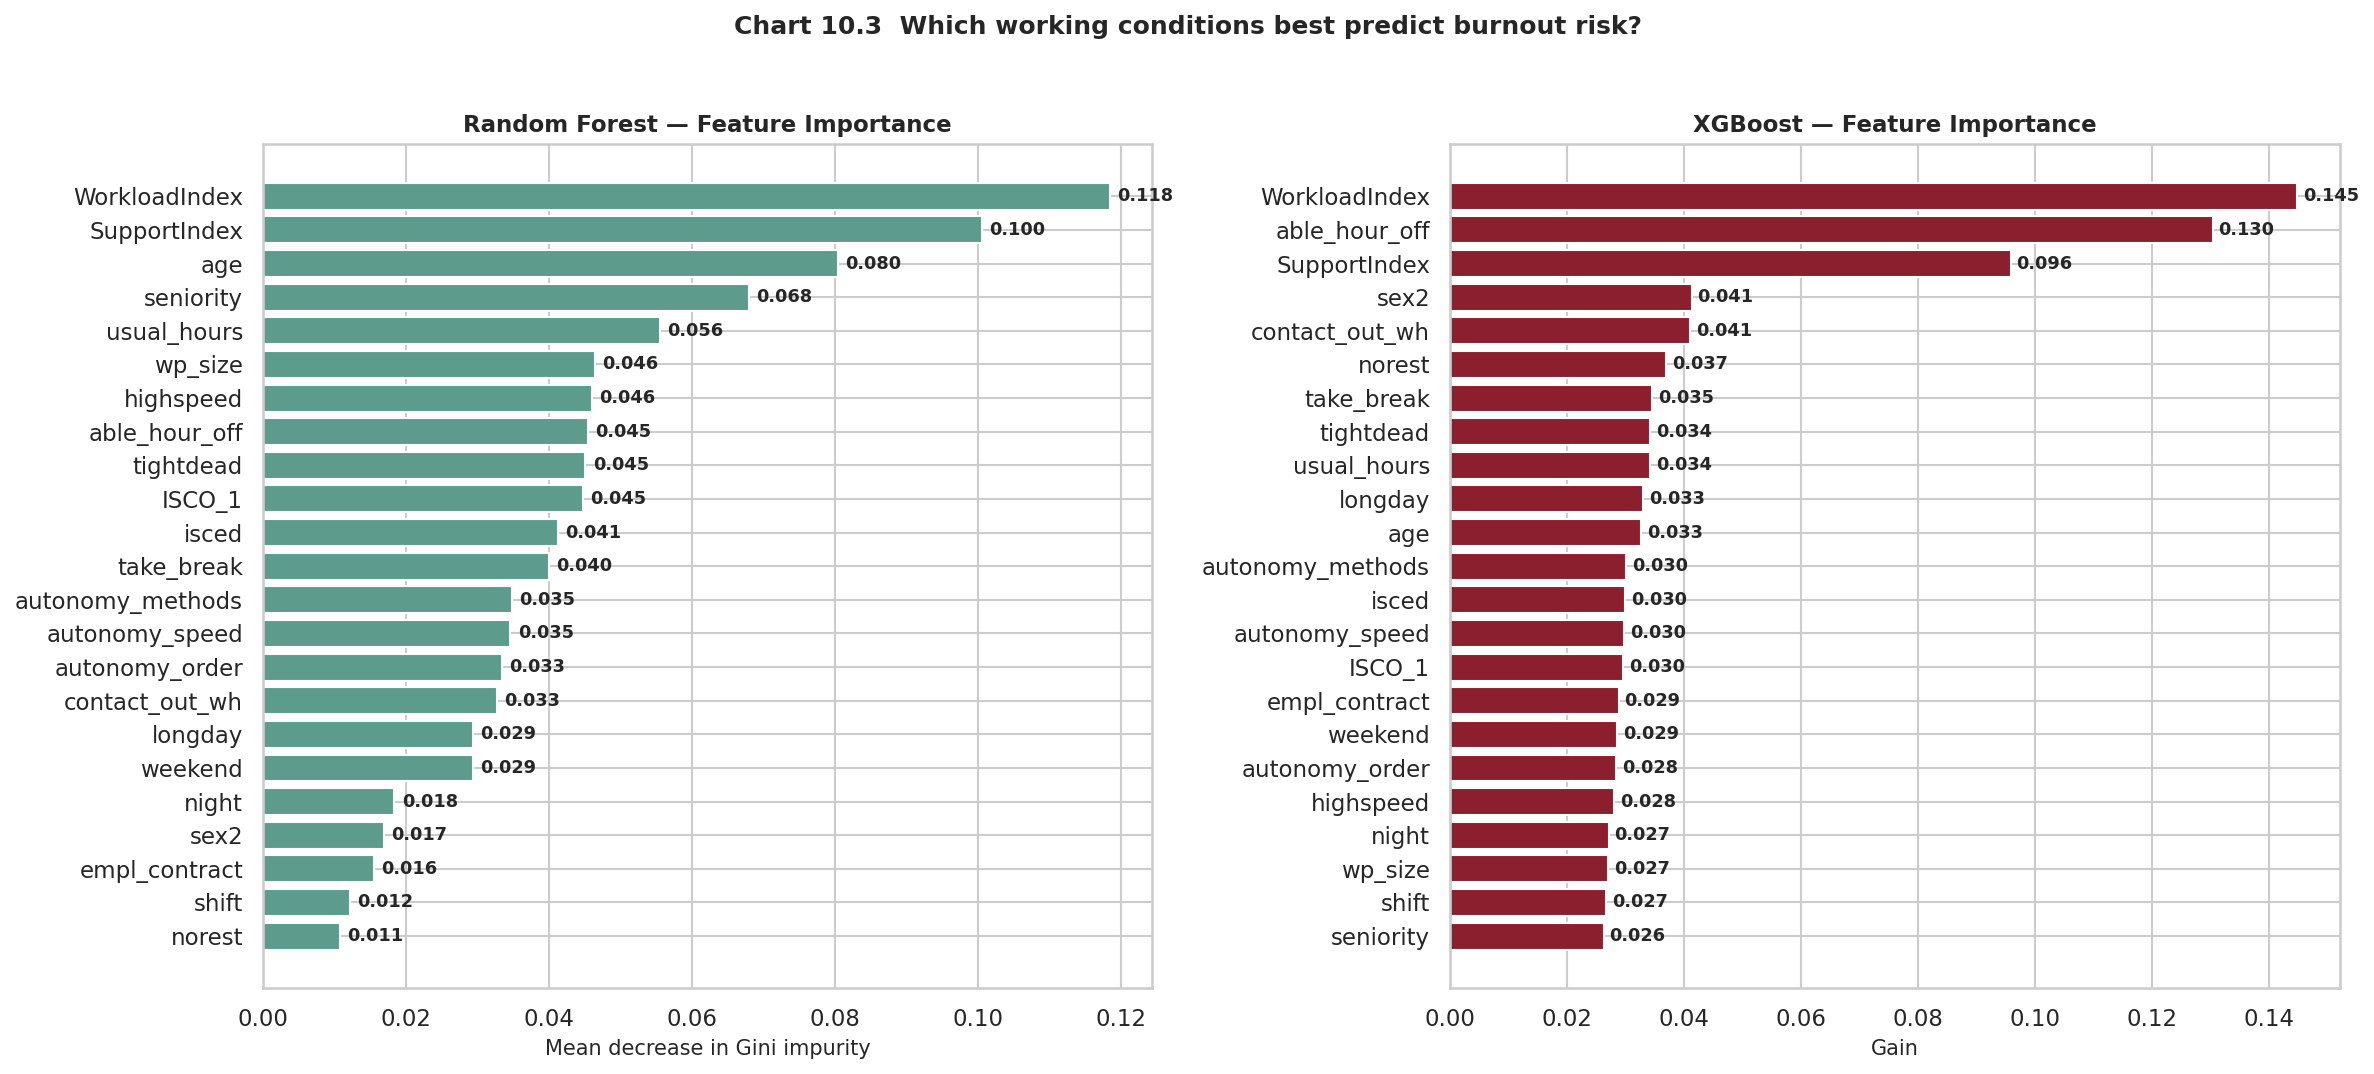

In [102]:
# Chart 10.3 — Feature importance: RF vs XGBoost
fi_rf  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values(ascending=True)
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].barh(fi_rf.index, fi_rf.values, color='#5D9C8D', edgecolor='white')
for i, v in enumerate(fi_rf.values):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8.5, fontweight='bold')
axes[0].set_xlabel('Mean decrease in Gini impurity', fontsize=10)
axes[0].set_title('Random Forest — Feature Importance', fontsize=11, fontweight='bold')

# XGBoost
axes[1].barh(fi_xgb.index, fi_xgb.values, color='#8C1F2D', edgecolor='white')
for i, v in enumerate(fi_xgb.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8.5, fontweight='bold')
axes[1].set_xlabel('Gain', fontsize=10)
axes[1].set_title('XGBoost — Feature Importance', fontsize=11, fontweight='bold')

fig.suptitle('Chart 10.3  Which working conditions best predict burnout risk?'
             ,
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_10_3_feature_importance.png', bbox_inches='tight')
plt.show()

In [103]:
# Per-class classification report for each model
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    y_pred = model.predict(X_test)
    print(f"\n{'='*60}")
    print(f"Classification Report — {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))


Classification Report — Logistic Regression
              precision    recall  f1-score   support

        High       0.62      0.63      0.62      1723
         Low       0.61      0.69      0.65      1813
      Medium       0.45      0.39      0.42      1840

    accuracy                           0.57      5376
   macro avg       0.56      0.57      0.56      5376
weighted avg       0.56      0.57      0.56      5376


Classification Report — Random Forest
              precision    recall  f1-score   support

        High       0.63      0.62      0.62      1723
         Low       0.62      0.68      0.65      1813
      Medium       0.46      0.43      0.45      1840

    accuracy                           0.57      5376
   macro avg       0.57      0.57      0.57      5376
weighted avg       0.57      0.57      0.57      5376


Classification Report — XGBoost
              precision    recall  f1-score   support

        High       0.64      0.60      0.62      1723
         Low

In [104]:
# Save the evaluation table as CSV
results_df.to_csv('/content/drive/MyDrive/Artefact V2/Part4_ModelEvaluation.csv')
print("Evaluation table saved: Part4_ModelEvaluation.csv")

# Final summary print
print("\nFINAL MODEL PERFORMANCE SUMMARY")
print(results_df.to_string())
print(f"\nSelected model for Part 5: {results_df['F1'].idxmax()}")

Evaluation table saved: Part4_ModelEvaluation.csv

FINAL MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.5683     0.5621  0.5701  0.5646   0.7530
Random Forest          0.5735     0.5712  0.5749  0.5725   0.7584
XGBoost                0.5763     0.5780  0.5772  0.5773   0.7609

Selected model for Part 5: XGBoost


---
## Part 4 Summary — Key Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | All three models perform within a narrow band (F1: 0.566–0.576) | Chart 10.1 |
| 2 | XGBoost selected as best model on F1 and ROC-AUC | Evaluation table |
| 3 | Model accuracy of 57% reflects deliberate exclusion of target-construction variables, not model failure | Methodology |
| 4 | Medium burnout class is hardest to classify (F1 ≈ 0.45) | Classification reports |
| 5 | High and Low classes are predicted with comparable accuracy (F1 ≈ 0.63) | Classification reports |
| 6 | Confusion errors cluster near class boundaries rather than across them | Chart 10.2 |
| 7 | WorkloadIndex is the strongest single predictor in both tree models | Chart 10.3 |
| 8 | SupportIndex consistently ranks top-3 across models | Chart 10.3 |
| 9 | XGBoost highlights `able_hour_off` as second most important  | Chart 10.3 |
| 10 | Age and seniority emerge as meaningful structural predictors | Chart 10.3 |
| 11 | Random Forest and XGBoost agree on top features, supporting feature signal validity | Chart 10.3 |
| 12 | All ROC-AUC scores above 0.75 and  models meaningfully separate the three classes | Evaluation table |
| 13 | Feature importance ranking empirically recovers the JD-R theoretical framework used in Part 2 | Chart 10.3 |
| 14 | Median imputation applied to ~8000 rows with partial missingness; one column dropped entirely | Cell 5 |
| 15 | No hyperparameter tuning applied and performance reported is honest baseline | Cell 8 |

---
Part 4 produced by Kadirhan KARACA

In [105]:
 #=============================================================================
# Part 5 - SHAP Analysis, Prescription Engine & Final Integration
# Person 5
#
# Builds on Part 4 (XGBoost trained on 23 working-condition features predicting
# BurnoutRisk in 3 classes). This part:
#   1. Computes SHAP values to explain predictions globally and per-worker
#   2. Maps actionable features to the HSE Management Standards 6-domain framework
#   3. Translates SHAP outputs into ranked, evidence-based HR recommendations
#   4. Saves three worked-example profiles for the panel
# =============================================================================


# -----------------------------------------------------------------------------
# CELL 1 - Setup and imports
# -----------------------------------------------------------------------------
# (Part 5 assumes Part 4 has been run in the same kernel: xgb, X_train, X_test,
# y_train, y_test, FEATURES, CLASS_NAMES, model_df are all in memory.)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
import warnings
warnings.filterwarnings('ignore')

PALETTE = {'Low': '#5D9C8D', 'Medium': '#F0AC4A', 'High': '#8C1F2D'}
ORDER   = ['Low', 'Medium', 'High']
BLUE    = '#1E2761'
RED     = '#8C1F2D'
TEAL    = '#5D9C8D'
GREY    = '#6B7280'

print("Part 5 - imports loaded.")
print(f"Working with Part 4's XGBoost model on {len(FEATURES)} features, "
      f"trained on {len(X_train):,} rows.")

Part 5 - imports loaded.
Working with Part 4's XGBoost model on 23 features, trained on 21,503 rows.


In [106]:

# -----------------------------------------------------------------------------
# CELL 2 - Compute SHAP values
# -----------------------------------------------------------------------------
# SHAP (SHapley Additive exPlanations) decomposes each prediction into per-
# feature contributions. For a 3-class XGBoost model, shap_values is a 3D array:
# (n_samples, n_features, n_classes). For the recommendation engine we focus on
# contributions toward the HIGH burnout class - i.e., what pushed this person
# toward high risk versus low risk.

explainer    = shap.TreeExplainer(xgb)
shap_values  = explainer.shap_values(X_test)

# Confirm the shape
print(f"SHAP values shape: {np.asarray(shap_values).shape}")
print(f"  -> (samples, features, classes) = ({len(X_test)}, {len(FEATURES)}, {N_CLASSES})")

# Index of the High class in the label encoder
HIGH_IDX = list(CLASS_NAMES).index('High')
print(f"High-class index: {HIGH_IDX}")

# Per-feature mean absolute SHAP value across all test samples, for the High class
# This is the global feature importance for predicting the High burnout class
shap_high = shap_values[:, :, HIGH_IDX] if shap_values.ndim == 3 else shap_values[HIGH_IDX]

mean_abs_shap = np.abs(shap_high).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature':       FEATURES,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("\nTop 10 features by SHAP importance (High class):")
print(shap_importance.head(10).to_string(index=False))


SHAP values shape: (5376, 23, 3)
  -> (samples, features, classes) = (5376, 23, 3)
High-class index: 0

Top 10 features by SHAP importance (High class):
       feature  mean_abs_shap
 WorkloadIndex       0.580425
  SupportIndex       0.378793
 able_hour_off       0.270942
          sex2       0.098266
           age       0.090402
   usual_hours       0.087883
     highspeed       0.076681
     tightdead       0.071958
contact_out_wh       0.059840
         isced       0.054083


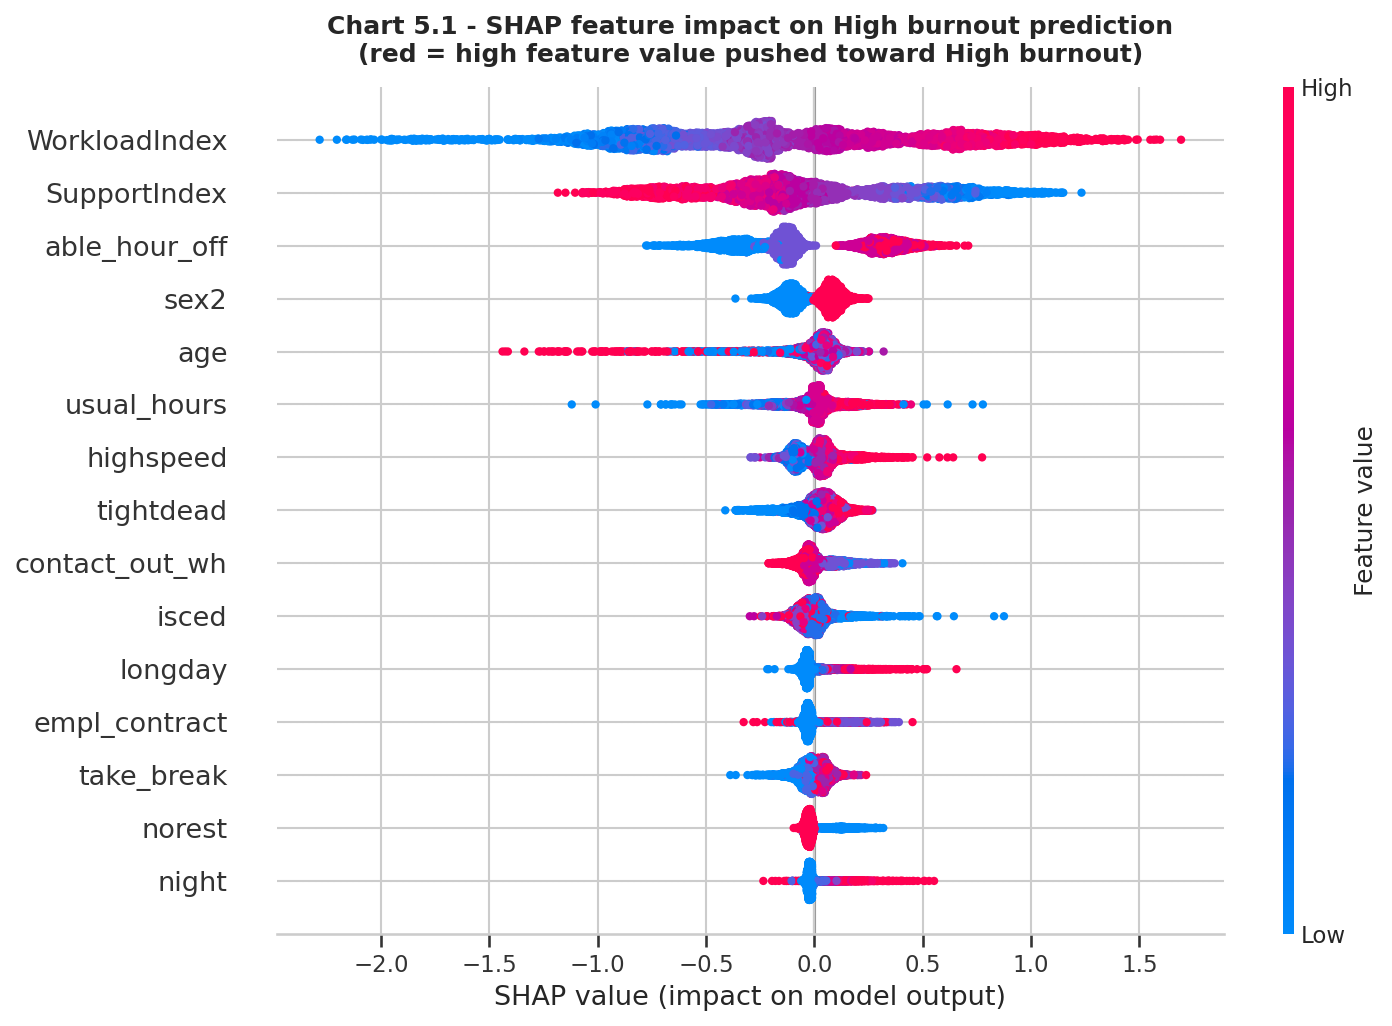

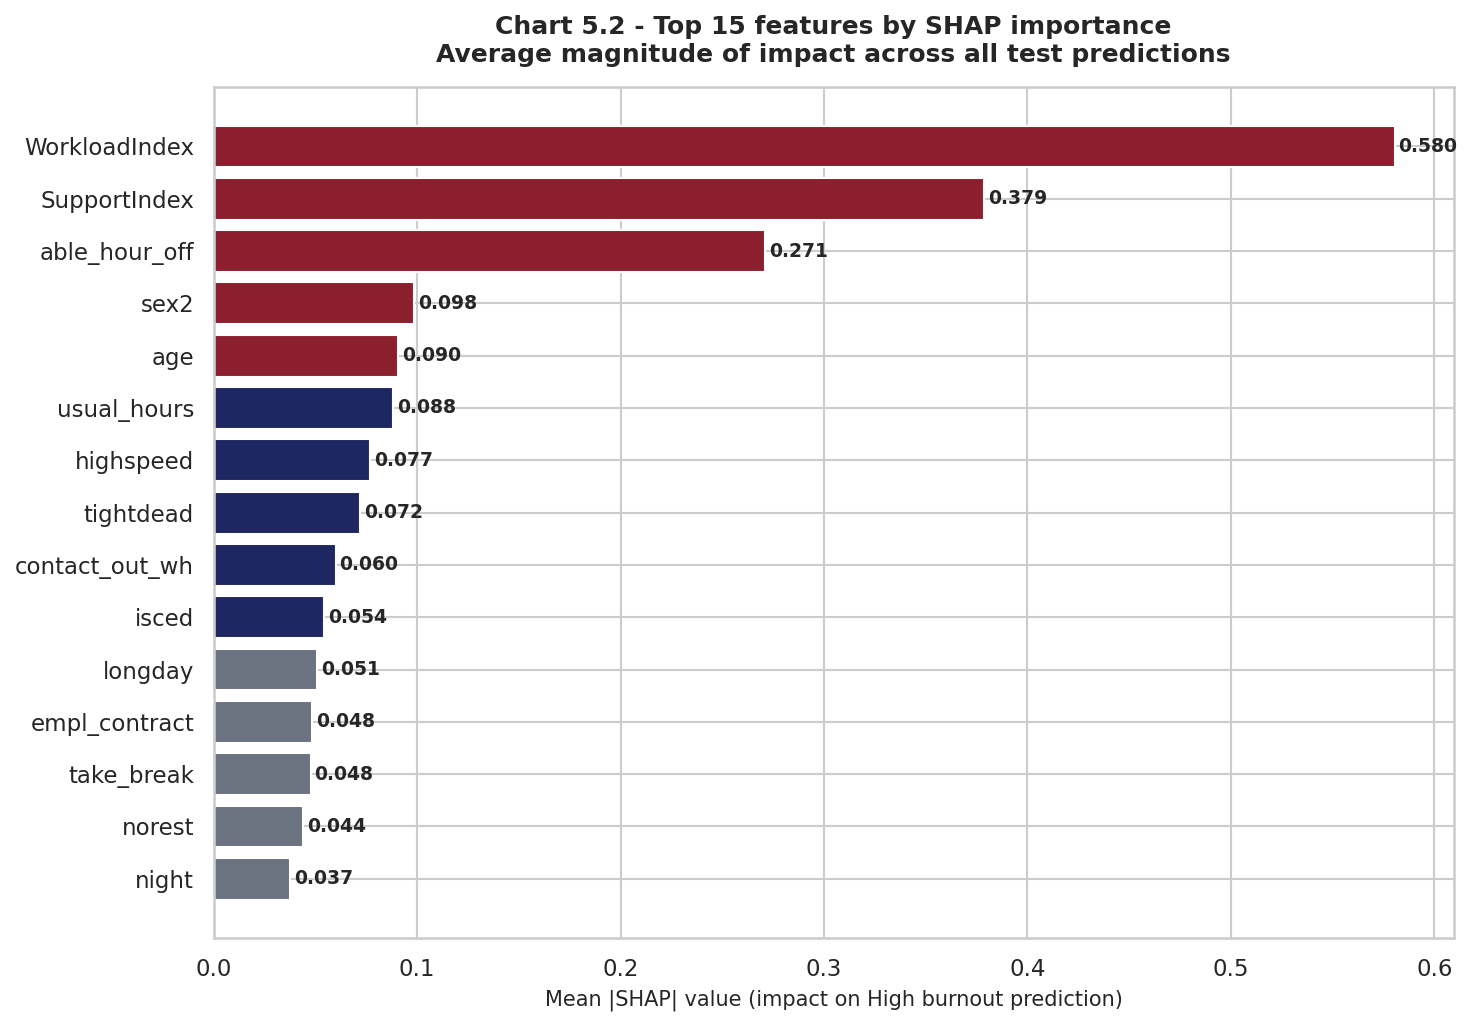

In [107]:
#-----------------------------------------------------------------------------
# CELL 3 - Chart 5.1: Global SHAP summary plot
# -----------------------------------------------------------------------------
# The summary plot shows each feature's distribution of SHAP values across the
# test set, coloured by the feature's value. Red dots = high feature value,
# blue dots = low. A red cluster to the right means "high value of this feature
# pushes prediction toward High burnout".

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_high,
    X_test,
    feature_names=FEATURES,
    max_display=15,
    show=False,
    plot_size=None
)
plt.title('Chart 5.1 - SHAP feature impact on High burnout prediction\n'
          '(red = high feature value pushed toward High burnout)',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart_5_1_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()


# -----------------------------------------------------------------------------
# CELL 4 - Chart 5.2: SHAP feature importance bar chart (cleaner for the deck)
# -----------------------------------------------------------------------------
top_n = 15
top_features = shap_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [RED if i < 5 else (BLUE if i < 10 else GREY) for i in range(top_n)]
bars = ax.barh(top_features['feature'][::-1], top_features['mean_abs_shap'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, top_features['mean_abs_shap'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Mean |SHAP| value (impact on High burnout prediction)', fontsize=10)
ax.set_title('Chart 5.2 - Top 15 features by SHAP importance\n'
             'Average magnitude of impact across all test predictions',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart_5_2_shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()



In [108]:
# CELL 5 - HSE Management Standards: feature-to-domain mapping
# -----------------------------------------------------------------------------
# Every actionable feature is mapped to one of the six HSE Management Standards
# domains. Demographic / structural features (age, sex, ISCO, isced, seniority,
# wp_size, empl_contract) are tagged as 'context' and excluded from prescription
# because they aren't directly actionable.
#
# The 'direction' field tells the engine whether HIGH raw values mean MORE of
# the construct or LESS. The 'high_means' field tells the user what direction
# of the original scale corresponds to the burnout risk.

FEATURE_MAP = {
    # ---- DEMANDS (workload and pace) ----
    'WorkloadIndex': {
        'domain': 'Demands',
        'concept': 'Overall workload pressure',
        'high_means': 'higher workload',
        'evidence': 'Bes et al. 2023 - meta-analysis: organisational workload reduction reduces exhaustion',
    },
    'usual_hours': {
        'domain': 'Demands',
        'concept': 'Long working hours',
        'high_means': 'longer hours',
        'evidence': 'Aronsson et al. 2017 - long hours predict burnout symptoms',
    },
    'highspeed': {
        'domain': 'Demands',
        'concept': 'Work pace intensity',
        'high_means': 'less time pressure (raw scale inverted)',
        'evidence': 'Lesener et al. 2019 - work pace as job demand drives exhaustion',
    },
    'tightdead': {
        'domain': 'Demands',
        'concept': 'Tight deadline pressure',
        'high_means': 'fewer deadlines (raw scale inverted)',
        'evidence': 'Lesener et al. 2019 - deadline pressure as job demand',
    },
    'norest': {
        'domain': 'Demands',
        'concept': 'Working without adequate rest',
        'high_means': 'less rest deprivation (raw scale inverted)',
        'evidence': 'Daniels et al. 2023 - recovery time critical for burnout prevention',
    },
    'longday': {
        'domain': 'Demands',
        'concept': 'Frequency of long working days',
        'high_means': 'more long days',
        'evidence': 'Aronsson et al. 2017',
    },
    'shift': {
        'domain': 'Demands',
        'concept': 'Shift work',
        'high_means': 'non-shift worker',
        'evidence': 'Daniels et al. 2023 - shift patterns linked to fatigue and burnout',
    },
    'night': {
        'domain': 'Demands',
        'concept': 'Night work frequency',
        'high_means': 'more nights worked',
        'evidence': 'Daniels et al. 2023',
    },
    'weekend': {
        'domain': 'Demands',
        'concept': 'Weekend work frequency',
        'high_means': 'more weekends worked',
        'evidence': 'Aronsson et al. 2017',
    },

    # ---- CONTROL (autonomy) ----
    'autonomy_speed': {
        'domain': 'Control',
        'concept': 'Control over work pace',
        'high_means': 'less autonomy over pace (raw scale inverted)',
        'evidence': 'Rudolph et al. 2017 - autonomy as job resource reduces burnout (k=122 studies)',
    },
    'autonomy_methods': {
        'domain': 'Control',
        'concept': 'Control over working methods',
        'high_means': 'less autonomy over methods',
        'evidence': 'Rudolph et al. 2017',
    },
    'autonomy_order': {
        'domain': 'Control',
        'concept': 'Control over task ordering',
        'high_means': 'less autonomy over order',
        'evidence': 'Rudolph et al. 2017',
    },
    'take_break': {
        'domain': 'Control',
        'concept': 'Ability to take a break when needed',
        'high_means': 'less break flexibility',
        'evidence': 'Bes et al. 2023 - break autonomy is core recovery mechanism',
    },
    'able_hour_off': {
        'domain': 'Control',
        'concept': 'Ability to take an hour off for personal matters',
        'high_means': 'less personal-time flexibility',
        'evidence': 'Bes et al. 2023',
    },

    # ---- SUPPORT ----
    'SupportIndex': {
        'domain': 'Support',
        'concept': 'Overall manager and colleague support',
        'high_means': 'higher support (resource)',
        'evidence': 'Dietz et al. 2024 - leader-targeted training improves manager support and worker outcomes',
    },

    # ---- CHANGE / OUT-OF-HOURS DEMANDS ----
    'contact_out_wh': {
        'domain': 'Change',
        'concept': 'Contact from work outside working hours',
        'high_means': 'less out-of-hours contact (raw scale inverted)',
        'evidence': 'Bes et al. 2023 - right-to-disconnect policies reduce burnout exposure',
    },

    # ---- CONTEXT (not actionable, excluded from prescription) ----
    'age':           {'domain': 'context', 'concept': 'Age', 'high_means': 'older', 'evidence': 'demographic'},
    'sex2':          {'domain': 'context', 'concept': 'Sex', 'high_means': 'female', 'evidence': 'demographic'},
    'isced':         {'domain': 'context', 'concept': 'Education level', 'high_means': 'higher education', 'evidence': 'demographic'},
    'seniority':     {'domain': 'context', 'concept': 'Years in current job', 'high_means': 'longer tenure', 'evidence': 'demographic'},
    'wp_size':       {'domain': 'context', 'concept': 'Workplace size', 'high_means': 'larger workplace', 'evidence': 'structural'},
    'empl_contract': {'domain': 'context', 'concept': 'Contract type', 'high_means': 'temporary contract', 'evidence': 'structural'},
    'ISCO_1':        {'domain': 'context', 'concept': 'Occupation group', 'high_means': 'higher ISCO category', 'evidence': 'structural'},
}

# Validate every model feature has a mapping (panel-defence: nothing slipped through)
unmapped = [f for f in FEATURES if f not in FEATURE_MAP]
assert len(unmapped) == 0, f"Unmapped features: {unmapped}"
print(f"All {len(FEATURES)} features mapped to HSE domains or tagged as context.")

# Show the domain breakdown
domain_counts = pd.Series([FEATURE_MAP[f]['domain'] for f in FEATURES]).value_counts()
print("\nFeature counts by HSE domain:")
print(domain_counts.to_string())


All 23 features mapped to HSE domains or tagged as context.

Feature counts by HSE domain:
Demands    9
context    7
Control    5
Support    1
Change     1


In [109]:

# -----------------------------------------------------------------------------
# CELL 6 - HSE domain -> intervention text mapping
# -----------------------------------------------------------------------------
# For each HSE domain, we provide the evidence-based intervention recommendation
# language. These are concise, action-oriented, and tied to specific
# meta-analyses or systematic reviews from our literature review.

DOMAIN_INTERVENTIONS = {
    'Demands': {
        'lever': 'Reduce or redesign job demands',
        'specific_actions': [
            'Review workload distribution and staffing levels',
            'Audit deadline-setting practices; build in buffer time',
            'Enforce adequate rest periods between shifts',
            'Limit long-day frequency through schedule redesign',
        ],
        'citation': 'Bes et al. (2023); Aronsson et al. (2017); Lesener et al. (2019)',
    },
    'Control': {
        'lever': 'Increase worker autonomy and job crafting',
        'specific_actions': [
            'Pilot job crafting interventions (Rudolph 2017 protocol)',
            'Grant teams more discretion over pace, method, and task ordering',
            'Enable flexible breaks and short personal-time absences',
        ],
        'citation': 'Rudolph et al. (2017, k=122); Lichtenthaler & Fischbach (2019)',
    },
    'Support': {
        'lever': 'Strengthen manager and peer support',
        'specific_actions': [
            'Mandatory mental-health-aware leadership training for managers',
            'Establish regular 1:1 manager-employee check-ins',
            'Build peer-support buddy systems and team practices',
        ],
        'citation': 'Dietz et al. (2024); Bagasi et al. (2025)',
    },
    'Relationships': {
        'lever': 'Address abusive behaviour and improve workplace climate',
        'specific_actions': [
            'Formal anti-bullying and anti-harassment procedures',
            'Confidential reporting channels and follow-through',
            'Conflict-resolution training for managers',
        ],
        'citation': 'Daniels et al. (2023)',
    },
    'Role': {
        'lever': 'Clarify role and provide adequate resources',
        'specific_actions': [
            'Ensure workers have enough time to complete tasks',
            'Define role boundaries and expectations explicitly',
            'Provide tools and training to match role demands',
        ],
        'citation': 'Lesener et al. (2019)',
    },
    'Change': {
        'lever': 'Manage organisational change and right-to-disconnect',
        'specific_actions': [
            'Establish right-to-disconnect policy for out-of-hours contact',
            'Provide advance notice of schedule and role changes',
            'Worker consultation on changes affecting their work',
        ],
        'citation': 'Bes et al. (2023)',
    },
}

print("Six HSE Management Standards domains with intervention recommendations:")
for dom, info in DOMAIN_INTERVENTIONS.items():
    print(f"\n  {dom}: {info['lever']}")
    print(f"    Citation: {info['citation']}")

Six HSE Management Standards domains with intervention recommendations:

  Demands: Reduce or redesign job demands
    Citation: Bes et al. (2023); Aronsson et al. (2017); Lesener et al. (2019)

  Control: Increase worker autonomy and job crafting
    Citation: Rudolph et al. (2017, k=122); Lichtenthaler & Fischbach (2019)

  Support: Strengthen manager and peer support
    Citation: Dietz et al. (2024); Bagasi et al. (2025)

  Relationships: Address abusive behaviour and improve workplace climate
    Citation: Daniels et al. (2023)

  Role: Clarify role and provide adequate resources
    Citation: Lesener et al. (2019)

  Change: Manage organisational change and right-to-disconnect
    Citation: Bes et al. (2023)


In [110]:

# CELL 7 - The recommendation engine
# -----------------------------------------------------------------------------
# Takes a worker's SHAP values and feature values, identifies the top
# actionable contributors to High burnout, and returns ranked recommendations
# grouped by HSE domain.

def recommend_interventions(shap_row, feature_values, feature_names,
                            top_k=3, only_pushing_to_high=True):
    """
    shap_row         : 1D array of SHAP values for ONE worker (length = n_features)
    feature_values   : 1D array of that worker's feature values
    feature_names    : list of feature names (same order)
    top_k            : how many top actionable features to surface
    only_pushing_to_high : if True, return only features that pushed prediction
                           TOWARD High burnout (positive SHAP)

    Returns: dict with 'top_drivers' (list) and 'recommendations' (list grouped
    by domain).
    """
    # Build a per-feature record
    contributions = []
    for i, fname in enumerate(feature_names):
        shap_val = float(shap_row[i])
        if only_pushing_to_high and shap_val <= 0:
            continue                                  # this feature protected them
        meta = FEATURE_MAP.get(fname, {})
        if meta.get('domain') == 'context':
            continue                                  # skip non-actionable
        contributions.append({
            'feature':      fname,
            'shap':         shap_val,
            'abs_shap':     abs(shap_val),
            'value':        float(feature_values[i]),
            'domain':       meta.get('domain'),
            'concept':      meta.get('concept'),
            'high_means':   meta.get('high_means'),
            'evidence':     meta.get('evidence'),
        })

    # Rank by absolute SHAP contribution
    contributions.sort(key=lambda d: d['abs_shap'], reverse=True)
    top_drivers = contributions[:top_k]

    # Group top drivers by HSE domain and build recommendation entries
    domains_seen = []
    recommendations = []
    for drv in top_drivers:
        dom = drv['domain']
        if dom in domains_seen:
            continue                                  # one recommendation per domain
        domains_seen.append(dom)
        dom_info = DOMAIN_INTERVENTIONS.get(dom, {})
        recommendations.append({
            'rank':              len(recommendations) + 1,
            'domain':            dom,
            'driver_feature':    drv['feature'],
            'driver_concept':    drv['concept'],
            'shap_contribution': round(drv['shap'], 4),
            'lever':             dom_info.get('lever'),
            'specific_actions':  dom_info.get('specific_actions', []),
            'citation':          dom_info.get('citation'),
        })

    return {
        'top_drivers':     top_drivers,
        'recommendations': recommendations,
    }


# Quick sanity test: run it on the first test-set worker
sample_idx   = 0
sample_shap  = shap_high[sample_idx]
sample_feats = X_test[sample_idx]
out = recommend_interventions(sample_shap, sample_feats, FEATURES, top_k=5)
print(f"Test recommendation for worker {sample_idx}:")
print(f"  Predicted class: {CLASS_NAMES[xgb.predict(X_test[[sample_idx]])[0]]}")
print(f"  Top drivers found: {len(out['top_drivers'])}")
print(f"  Recommendations returned: {len(out['recommendations'])}")
for rec in out['recommendations']:
    print(f"\n  [{rec['rank']}] {rec['domain']} domain - {rec['driver_concept']}")
    print(f"      SHAP contribution: {rec['shap_contribution']:+.4f}")
    print(f"      Lever: {rec['lever']}")
    print(f"      Citation: {rec['citation']}")


Test recommendation for worker 0:
  Predicted class: Medium
  Top drivers found: 3
  Recommendations returned: 1

  [1] Demands domain - Work pace intensity
      SHAP contribution: +0.0684
      Lever: Reduce or redesign job demands
      Citation: Bes et al. (2023); Aronsson et al. (2017); Lesener et al. (2019)


In [111]:

# -----------------------------------------------------------------------------
# CELL 8 - Worked examples: pick three representative profiles
# -----------------------------------------------------------------------------
# To demonstrate the engine to the panel, we pick three test-set workers:
#   1. Highest predicted-High-probability worker (clear High case)
#   2. Worker whose prediction is closest to the High/Medium boundary
#   3. Lowest predicted-High-probability worker (clear Low case)

y_proba   = xgb.predict_proba(X_test)
high_proba = y_proba[:, HIGH_IDX]

idx_clear_high = int(np.argmax(high_proba))
idx_clear_low  = int(np.argmin(high_proba))
# Borderline: closest to the median High probability
idx_borderline = int(np.argmin(np.abs(high_proba - np.median(high_proba))))

examples = {
    'Clear High-risk worker':    idx_clear_high,
    'Borderline worker':         idx_borderline,
    'Clear Low-risk worker':     idx_clear_low,
}

print("Worker examples chosen for prescription demonstration:")
for label, idx in examples.items():
    pred = CLASS_NAMES[xgb.predict(X_test[[idx]])[0]]
    prob = high_proba[idx]
    print(f"  {label:30s} idx={idx}  pred={pred}  P(High)={prob:.3f}")

Worker examples chosen for prescription demonstration:
  Clear High-risk worker         idx=4016  pred=High  P(High)=0.997
  Borderline worker              idx=611  pred=Low  P(High)=0.234
  Clear Low-risk worker          idx=1774  pred=Low  P(High)=0.000


In [112]:

# CELL 9 - Generate and pretty-print recommendations for each example
# -----------------------------------------------------------------------------
def pretty_print_recommendation(label, idx):
    pred_class = CLASS_NAMES[xgb.predict(X_test[[idx]])[0]]
    p_high     = high_proba[idx]
    out = recommend_interventions(
        shap_high[idx], X_test[idx], FEATURES, top_k=5
    )

    print("=" * 72)
    print(f"{label}")
    print("=" * 72)
    print(f"Predicted class : {pred_class}")
    print(f"P(High burnout) : {p_high:.3f}")
    print()

    if not out['recommendations']:
        print("No actionable features pushed this worker toward High burnout.")
        print("(All elevated-risk drivers are demographic/contextual, or the model")
        print(" predicts low risk.)")
        return

    print("Top burnout drivers (actionable only, ranked by SHAP magnitude):")
    for d in out['top_drivers']:
        print(f"  {d['concept']:42s} SHAP {d['shap']:+.4f}  (raw value {d['value']:.2f})")

    print()
    print("Recommended interventions:")
    for rec in out['recommendations']:
        print(f"\n  [{rec['rank']}] {rec['domain']} domain  --  {rec['lever']}")
        print(f"      Driven by: {rec['driver_concept']} (SHAP {rec['shap_contribution']:+.4f})")
        print(f"      Specific actions:")
        for action in rec['specific_actions']:
            print(f"         - {action}")
        print(f"      Evidence base: {rec['citation']}")
    print()


for label, idx in examples.items():
    pretty_print_recommendation(label, idx)


Clear High-risk worker
Predicted class : High
P(High burnout) : 0.997

Top burnout drivers (actionable only, ranked by SHAP magnitude):
  Overall manager and colleague support      SHAP +1.1414  (raw value 12.50)
  Overall workload pressure                  SHAP +0.9781  (raw value 76.70)
  Ability to take an hour off for personal matters SHAP +0.3537  (raw value 4.00)
  Night work frequency                       SHAP +0.2199  (raw value 10.00)
  Long working hours                         SHAP +0.1982  (raw value 48.00)

Recommended interventions:

  [1] Support domain  --  Strengthen manager and peer support
      Driven by: Overall manager and colleague support (SHAP +1.1414)
      Specific actions:
         - Mandatory mental-health-aware leadership training for managers
         - Establish regular 1:1 manager-employee check-ins
         - Build peer-support buddy systems and team practices
      Evidence base: Dietz et al. (2024); Bagasi et al. (2025)

  [2] Demands domain  --  Re

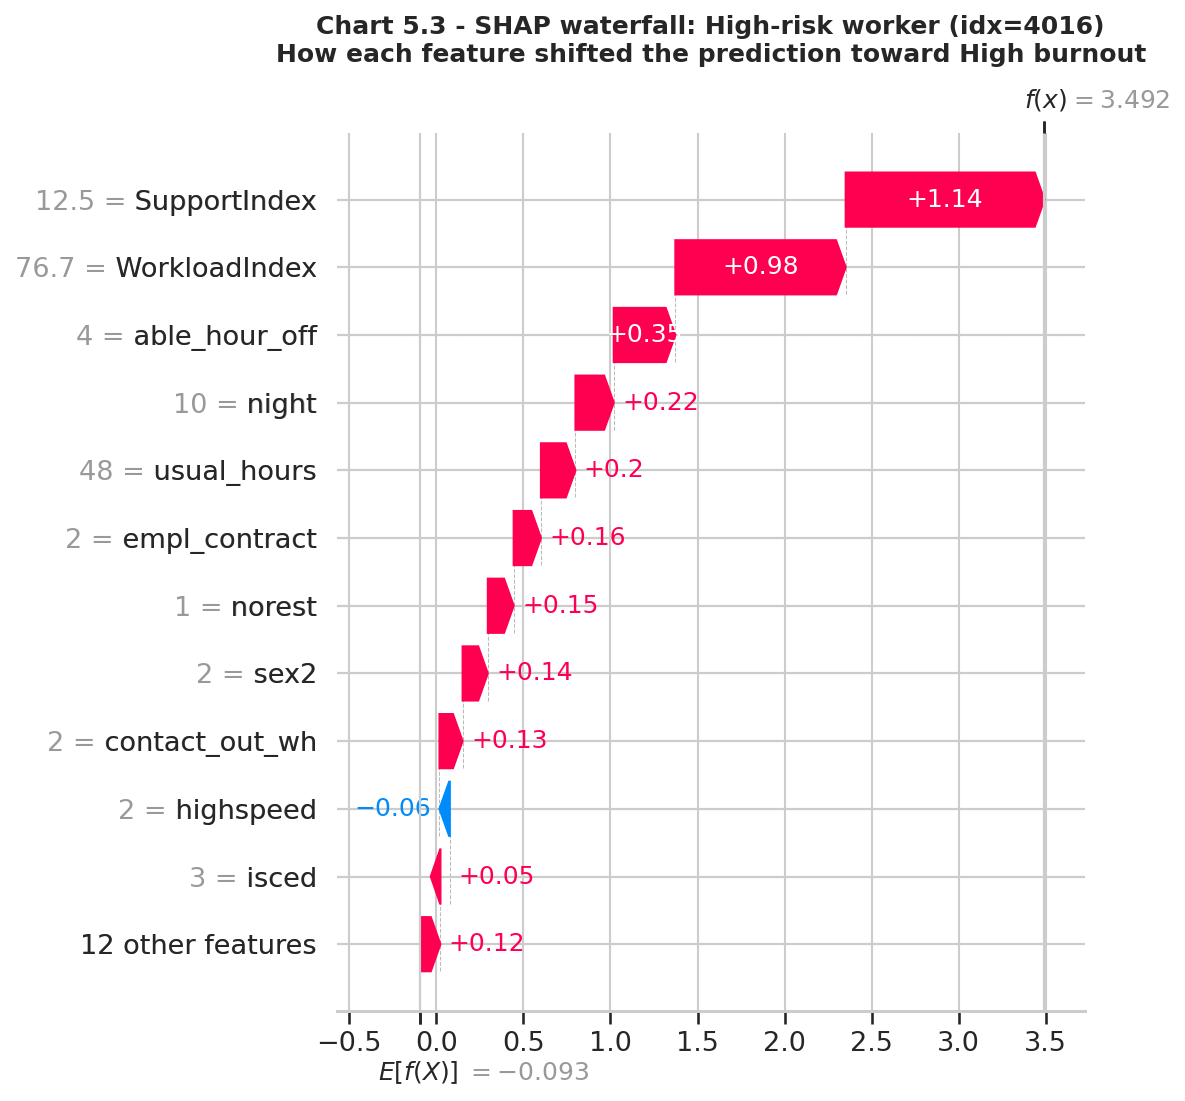

In [113]:
# Cell 10 - SHAP waterfall plot for the High-risk worker (fixed for new SHAP)
idx = idx_clear_high

# Extract base value as a single scalar float
ev = explainer.expected_value
if hasattr(ev, '__len__') and len(ev) > 1:
    base_val = float(ev[HIGH_IDX])
else:
    base_val = float(ev)

explanation = shap.Explanation(
    values=shap_high[idx].astype(float),
    base_values=base_val,
    data=X_test[idx].astype(float),
    feature_names=FEATURES,
)

fig = plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f'Chart 5.3 - SHAP waterfall: High-risk worker (idx={idx})\n'
          f'How each feature shifted the prediction toward High burnout',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart_5_3_shap_waterfall_high.png', bbox_inches='tight', dpi=150)
plt.show()

In [114]:
# -----------------------------------------------------------------------------
# CELL 11 - Save outputs: recommendations CSV + JSON for the dashboard team
# -----------------------------------------------------------------------------
# Build a recommendations file with the top-3 actionable recommendations for
# EVERY test-set worker. This is what an HR-facing dashboard would consume.

all_recommendations = []
for i in range(len(X_test)):
    pred_class = CLASS_NAMES[xgb.predict(X_test[[i]])[0]]
    p_high     = high_proba[i]
    out = recommend_interventions(shap_high[i], X_test[i], FEATURES, top_k=3)
    record = {
        'worker_idx':       i,
        'predicted_class':  pred_class,
        'P_High':           round(float(p_high), 4),
        'n_recommendations': len(out['recommendations']),
    }
    for rec in out['recommendations']:
        record[f"rec{rec['rank']}_domain"]      = rec['domain']
        record[f"rec{rec['rank']}_driver"]      = rec['driver_concept']
        record[f"rec{rec['rank']}_shap"]        = rec['shap_contribution']
        record[f"rec{rec['rank']}_lever"]       = rec['lever']
        record[f"rec{rec['rank']}_citation"]    = rec['citation']
    all_recommendations.append(record)

recs_df = pd.DataFrame(all_recommendations)
recs_df.to_csv('/content/drive/MyDrive/Artefact V2/Part5_Recommendations.csv',
               index=False)
print(f"Saved Part5_Recommendations.csv ({len(recs_df):,} rows)")

# Save the feature-domain mapping and intervention library as JSON for traceability
metadata = {
    'feature_to_domain_mapping': FEATURE_MAP,
    'domain_interventions':      DOMAIN_INTERVENTIONS,
    'n_features':                len(FEATURES),
    'features':                  FEATURES,
    'classes':                   list(CLASS_NAMES),
    'model':                     'XGBoost',
    'high_class_idx':            HIGH_IDX,
}
with open('/content/drive/MyDrive/Artefact V2/Part5_PrescriptionMetadata.json',
          'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved Part5_PrescriptionMetadata.json")

Saved Part5_Recommendations.csv (5,376 rows)
Saved Part5_PrescriptionMetadata.json


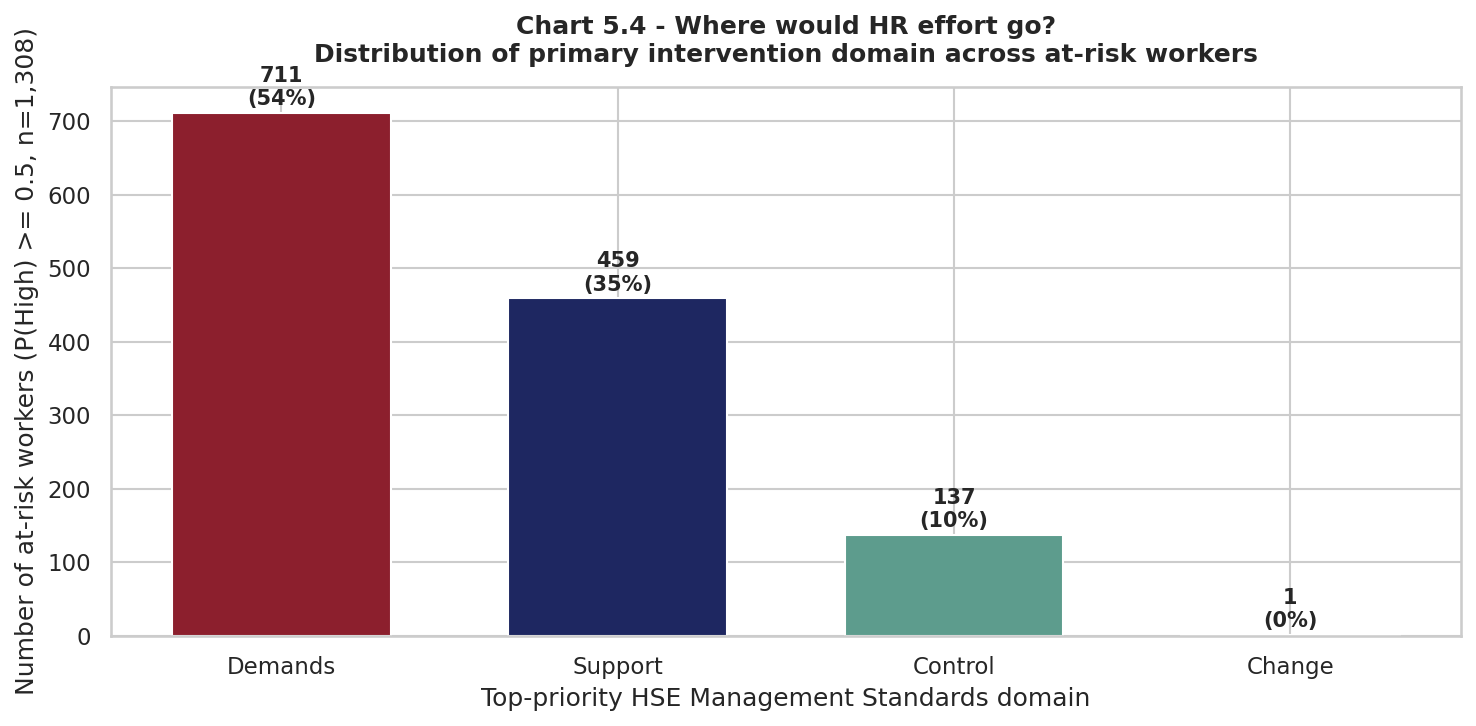


Part 5 complete.
Files produced:
  - Part5_Recommendations.csv
  - Part5_PrescriptionMetadata.json
  - chart_5_1_shap_summary.png
  - chart_5_2_shap_importance.png
  - chart_5_3_shap_waterfall_high.png
  - chart_5_4_domain_distribution.png


In [115]:

# CELL 12 - Chart 5.4: Distribution of recommendations by HSE domain
# -----------------------------------------------------------------------------
# Among workers predicted at-risk (P_High >= 0.5), which domains come up most
# often as the top driver? This is the prescriptive-level story for the panel:
# "If our model were deployed across this workforce, the HR function would be
# directed to act primarily on X, Y, Z."

at_risk = recs_df[recs_df['P_High'] >= 0.5].copy()
domain_freq = at_risk['rec1_domain'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = [RED if i == 0 else (BLUE if i == 1 else TEAL if i == 2 else GREY)
            for i in range(len(domain_freq))]
bars = ax.bar(domain_freq.index, domain_freq.values,
              color=colors_d, edgecolor='white', width=0.65)
for bar, val in zip(bars, domain_freq.values):
    pct = val / domain_freq.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}\n({pct:.0f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylabel(f'Number of at-risk workers (P(High) >= 0.5, n={len(at_risk):,})')
ax.set_xlabel('Top-priority HSE Management Standards domain')
ax.set_title('Chart 5.4 - Where would HR effort go?\n'
             'Distribution of primary intervention domain across at-risk workers',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart_5_4_domain_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nPart 5 complete.")
print("Files produced:")
print("  - Part5_Recommendations.csv")
print("  - Part5_PrescriptionMetadata.json")
print("  - chart_5_1_shap_summary.png")
print("  - chart_5_2_shap_importance.png")
print("  - chart_5_3_shap_waterfall_high.png")
print("  - chart_5_4_domain_distribution.png")